# <center>TFM - MODELO OPTIMIZACIÓN PRICING<center>

## I. ANÁLISIS EDA

### IMPORTACIÓN DE LIBRERIAS Y CARGA DEL DATASET

Importación de las principales librerías que se utilizarán a lo largo del proyecto tanto para el análisis EDA y segmentación de clientes

Además, se crea una función para poder realizar la carga del dataset desde cualquier carpeta del ordenador.

In [1]:
#Importación de librerias generales
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
import io
from google.colab import files

#Función para cargar archivo con el dataset (formato xlsx)
def cargar_archivo (index_fields = None):
  uploaded = files.upload()
  for fn in uploaded.keys():
    print('Se cargó el archivo "{name}" con un tamaño de {length} bytes'.format(
        name = fn, length = len(uploaded[fn])))
    df = pd.read_excel(io.BytesIO(uploaded[fn]), index_col = index_fields)
    return df

Carga del dataset y visualización de las primeras 10 filas para corroborar que se haya cargado correctamente.

In [2]:
#Subir el dataset del proyecto
proyecto = cargar_archivo()
print(proyecto.shape)
proyecto.head()

Saving TFM.xlsx to TFM.xlsx
Se cargó el archivo "TFM.xlsx" con un tamaño de 101896772 bytes
(934437, 21)


,Cliente,Región,Mes,Año,Subfamilia,Familia,Ventas tarifa,Volumen ventas,Peso,Ventas Brutas,...,Cond Temporales,Cond Logísticas,Ventas Facturadas,Desc. pronto pago,Ventas Facturadas 2,Total Rappel,VENTAS NETAS,TOTAL TPTE,TOTAL VBLES.VTA s/AJ,TOTAL FIJOS VTA
0,3000312,ES /39 Cantabria,3,2025,3.6.,3,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.60
1,3000312,ES /39 Cantabria,3,2025,3.1.,3,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.38
2,3000312,ES /39 Cantabria,3,2025,3.1.,3,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10
3,3000312,ES /39 Cantabria,3,2025,2.1.,2,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,3000312,ES /39 Cantabria,3,2025,1.1.,1,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


### REVISIÓN DE VARIABLES

Visualización inicial de las variables del dataset para corroborar el tipo de dato. Esto ayuda a prevenir furutos errores en cálculos en caso que alguna variable numérica se haya cargado como texto. En este caso, todas las variables de cargaron de manera correcta por lo cual no deberían existir problemas al realizar operaciones matemáticas sobre estos.

In [3]:
proyecto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 934437 entries, 0 to 934436
Data columns (total 21 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Cliente               934437 non-null  object 
 1   Región                934437 non-null  object 
 2   Mes                   934437 non-null  int64  
 3   Año                   934437 non-null  int64  
 4   Subfamilia            934437 non-null  object 
 5   Familia               934437 non-null  int64  
 6   Ventas tarifa         934437 non-null  float64
 7   Volumen ventas        934437 non-null  int64  
 8   Peso                  934437 non-null  float64
 9   Ventas Brutas         934437 non-null  float64
 10  Cond Permanentes      934437 non-null  float64
 11  Cond Temporales       934437 non-null  float64
 12  Cond Logísticas       934437 non-null  float64
 13  Ventas Facturadas     934437 non-null  float64
 14  Desc. pronto pago     934437 non-null  float64
 15  

Renombramos algunas columnas del dataset para que sea más fácil trabajar con ellas.

In [4]:
proyecto = proyecto.rename(columns = {
    "Ventas tarifa": "vta_tarifa",
    "Volumen ventas": "cantidad",
    "Ventas Brutas": "vta_bruta",
    "Cond Permanentes": "dsco_permanente",
    "Cond Temporales": "dsco_temporal",
    "Cond Logísticas": "dsco_logistico",
    "Desc. pronto pago": "dsco_pronto_pago",
    "Total Rappel": "cto_rappel",
    "Ventas Facturadas": "vta_facturada",
    "Ventas Facturadas 2": "vta_facturada2",
    "VENTAS NETAS": "vta_neta",
    "TOTAL TPTE": "cto_transporte",
    "TOTAL VBLES.VTA s/AJ": "cto_variable",
    "TOTAL FIJOS VTA": "cto_fijo"
})

proyecto.head()

,Cliente,Región,Mes,Año,Subfamilia,Familia,vta_tarifa,cantidad,Peso,vta_bruta,...,dsco_temporal,dsco_logistico,vta_facturada,dsco_pronto_pago,vta_facturada2,cto_rappel,vta_neta,cto_transporte,cto_variable,cto_fijo
0,3000312,ES /39 Cantabria,3,2025,3.6.,3,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.60
1,3000312,ES /39 Cantabria,3,2025,3.1.,3,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.38
2,3000312,ES /39 Cantabria,3,2025,3.1.,3,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.10
3,3000312,ES /39 Cantabria,3,2025,2.1.,2,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00
4,3000312,ES /39 Cantabria,3,2025,1.1.,1,0.0,0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00


Validación de datos nulos o faltantes dentro del dataset. Nos ayuda a identificar si existen datos faltantes que puedan generar errores en futuros cálculos dentro de los análisis. En caso de existir nulos, y dependiendo del porcentaje que representen sobre el total de datos, se puede optar por usar distintos métodos para tratarlos. En nuestro caso, el dataset no presenta datos nulos.

In [5]:
def analisis_nulos(df):
  nulos = df.isnull().sum() #Suma de nulos para las variables
  porcentaje = (nulos / len(df)) * 100 #Cálculo porcentual de nulos para las variables
  tabla = pd.DataFrame({"Nulos": nulos, "% Nulos": porcentaje.round(2)}) #Generar la tabla con las variables, nulos y % nulos

  return tabla.sort_values(by = "Nulos", ascending = False) #Imprime la tabla generada ordenada por cantidad de nulos de mayor a menor

analisis_nulos(proyecto)

,Nulos,% Nulos
Cliente,0,0.0
Región,0,0.0
Mes,0,0.0
Año,0,0.0
Subfamilia,0,0.0
Familia,0,0.0
vta_tarifa,0,0.0
cantidad,0,0.0
Peso,0,0.0
vta_bruta,0,0.0


Visualización inicial del análisis descriptivo de las variables del dataset. Se puede observar que para las columnas "Volumen ventas", "Peso", "Ventas Brutas" los valores máximos son significativamente mayores a los cuartiles, lo cual indica posible presencia de outliers o valores atípicos. Además, para las mismas columnas se pueden observar valores negativos.

Al revisar el dataset en detalle, y en conversación con la empresa, se determino que la mayoría de dichos valores negativos correspondían a ajustes internos por lo cual se excluirán del análisis. Dichos valores están asociados a clientes y zonas clasificados como "no usar, sin asignar u similar".

Además, también se observo que se tenían 4 países principales de venta, pero 2 de ellos (Francia y Marruecos) presentaban muy pocos registros (menos de 20 cada uno). Dado esto, se decidió excluirlos también del análisis y trabajar solo con España y Portugal.

In [6]:
#Consideramos solo las variables numéricas y excluimos las variables que no son relevantes para el describe()
columnas_excluir = ["Mes", "Año", "Familia"]
resumen = proyecto.drop(columns = columnas_excluir).describe()
resumen

,vta_tarifa,cantidad,Peso,vta_bruta,dsco_permanente,dsco_temporal,dsco_logistico,vta_facturada,dsco_pronto_pago,vta_facturada2,cto_rappel,vta_neta,cto_transporte,cto_variable,cto_fijo
count,9.344370e+05,934437.000000,9.344370e+05,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000,934437.000000
mean,5.477831e+02,78.584144,3.379109e+04,220.773941,-75.533619,-0.872954,-0.231185,144.136184,-0.761323,143.374914,-8.758401,134.616513,9.036156,88.724921,19.732814
std,5.544440e+03,325.621930,3.670452e+05,1190.472156,524.546368,14.428393,7.432517,947.578635,9.198815,944.119244,443.212995,1007.980240,52.228360,608.664775,133.207538
min,-3.019896e+04,-4500.000000,-5.865552e+06,-72428.980000,-71820.000000,-2638.230000,-3016.200000,-72428.980000,-2106.520000,-72428.980000,-75387.320000,-75387.320000,-421.590000,-6173.930000,-1717.970000
25%,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.050000,0.000000
50%,8.125000e+01,20.000000,2.450000e+01,42.000000,0.000000,0.000000,0.000000,30.420000,0.000000,30.320000,0.000000,29.610000,0.380000,13.300000,3.600000
75%,2.524000e+02,60.000000,7.200000e+03,139.500000,0.000000,0.000000,0.000000,86.250000,0.000000,85.970000,0.000000,84.000000,2.990000,38.490000,12.810000
max,3.574431e+06,70992.000000,4.642877e+07,108750.000000,5078.290000,496.800000,940.550000,108750.000000,45.130000,108750.000000,58684.040000,108750.000000,6069.710000,89202.240000,28379.810000


### LIMPIEZA DE DATOS Y CREACIÓN UNITARIOS

Se excluyen todas las filas que contengan en las columnas "cantidad", "Peso", "vta_bruta" o "vta_facturada2" valores iguales o menores a cero. Además, se excluyeron todas las filas asignadas a los clientes o zonas definidas en las listas correspondientes, resultando en una disminución aproximada de 320k de filas.

In [7]:
#Lista clientes y zonas a excluir
excluir_clientes = ["1008", "1014", "1S00", "1C00", "1R00", "1A10", "1A50", "Sin asigna"]
excluir_zonas = ["/    Sin asignar", "ES /    Sin asignar", "PT /    Sin asignar", "PT /11  No usar", "PT /15  No usar", "PT /16  No usar",
                 "PT /73  No usar", "FR /72  Sarthe", "FR /76  Seine-Maritime", "MR /MR  MAURITANIA"]

#Excluimos clientes y zonas del dataset
antes = len(proyecto)
proyecto_limpio = proyecto[~proyecto["Cliente"].isin(excluir_clientes)].copy()
print(f"Registros de clientes excluidos: {antes - len(proyecto_limpio)}")

antes = len(proyecto_limpio)
proyecto_limpio = proyecto_limpio[~proyecto_limpio["Región"].isin(excluir_zonas)]
print(f"Registros de regiones excluidos: {antes - len(proyecto_limpio)}")

#Excluimos valores negativos o 0 que no aportan información o corresponden a procesos internos
antes = len(proyecto_limpio)
proyecto_limpio = proyecto_limpio[proyecto_limpio["cantidad"] > 0]
print(f"Registros de cantidad excluidos: {antes - len(proyecto_limpio)}")

antes = len(proyecto_limpio)
proyecto_limpio = proyecto_limpio[proyecto_limpio["Peso"] > 0]
print(f"Registros de peso excluidos: {antes - len(proyecto_limpio)}")

antes = len(proyecto_limpio)
proyecto_limpio = proyecto_limpio[proyecto_limpio["vta_bruta"] > 0]
print(f"Registros de vta_bruta excluidos: {antes - len(proyecto_limpio)}")

antes = len(proyecto_limpio)
proyecto_limpio = proyecto_limpio[proyecto_limpio["vta_facturada2"] > 0]
print(f"Registros de vta_facturada2 excluidos: {antes - len(proyecto_limpio)}")

print(f"Cantidad de registros iniciales: {len(proyecto)}")
print(f"Cantidad de registros post limpieza: {len(proyecto_limpio)}")

Registros de clientes excluidos: 12095
Registros de regiones excluidos: 39264
Registros de cantidad excluidos: 267277
Registros de peso excluidos: 0
Registros de vta_bruta excluidos: 112
Registros de vta_facturada2 excluidos: 114
Cantidad de registros iniciales: 934437
Cantidad de registros post limpieza: 615575


Para poder hacer un correcto análisis en los siguientes apartados, y dado que el dataset cuenta con valores brutos para cada variable (euros), creamos una nueva columna para cada variables con su valor unitario para poder hacer comparacaciones. El unitario se calcula en función de la columna "peso".

In [8]:
proyecto_analisis = proyecto_limpio.copy()
total_actual = len(proyecto_limpio)

#UNITARIO = VARIABLE / (Peso / 1000)
#Para el año 2023 se divide solo por "Peso"
#Creamos variables unitarias para columna de nuestro dataset e incluimos algunas nuevas
proyecto_analisis["peso_uni"] = proyecto_analisis["Peso"] / proyecto_analisis["cantidad"]
proyecto_analisis["mg_neto"] = proyecto_analisis["vta_facturada2"] - proyecto_analisis["cto_variable"]
proyecto_analisis["cto_total"] = proyecto_analisis["cto_variable"] + proyecto_analisis["cto_fijo"]

#Variable para calcular unitario, su cálculo dependerá del valor en la columna "Año"
proyecto_analisis["factor_peso"] = np.where(proyecto_analisis["Año"] == 2023, proyecto_analisis["Peso"], proyecto_analisis["Peso"] / 1000)

#Variable margen unitario
proyecto_analisis["mg_neto_uni"] = (proyecto_analisis["vta_facturada2"] - proyecto_analisis["cto_variable"]) / proyecto_analisis["factor_peso"]

#Variabbles unitarias asociadas a costos
proyecto_analisis["cto_producto_uni"] = (proyecto_analisis["cto_variable"] - proyecto_analisis["cto_transporte"]) / proyecto_analisis["factor_peso"]
proyecto_analisis["cto_rappel_uni"] = proyecto_analisis["cto_rappel"] / proyecto_analisis["factor_peso"]
proyecto_analisis["cto_transporte_uni"] = proyecto_analisis["cto_transporte"] / proyecto_analisis["factor_peso"]
proyecto_analisis["cto_variable_uni"] = proyecto_analisis["cto_variable"] / proyecto_analisis["factor_peso"]
proyecto_analisis["cto_fijo_uni"] = proyecto_analisis["cto_fijo"] / proyecto_analisis["factor_peso"]

#Variables unitarias asociadas a descuentos
proyecto_analisis["dsco_permanente_uni"] = proyecto_analisis["dsco_permanente"] / proyecto_analisis["factor_peso"]
proyecto_analisis["dsco_temporal_uni"] = proyecto_analisis["dsco_temporal"] / proyecto_analisis["factor_peso"]
proyecto_analisis["dsco_logistico_uni"] = proyecto_analisis["dsco_logistico"] / proyecto_analisis["factor_peso"]
proyecto_analisis["dsco_pronto_pago_uni"] = proyecto_analisis["dsco_pronto_pago"] / proyecto_analisis["factor_peso"]

#Variables unitarias asociadas a venta
proyecto_analisis["vta_bruta_uni"] = proyecto_analisis["vta_bruta"] / proyecto_analisis["factor_peso"]
proyecto_analisis["vta_tarifa_uni"] = proyecto_analisis["vta_tarifa"] / proyecto_analisis["factor_peso"]
proyecto_analisis["vta_facturada_uni"] = proyecto_analisis["vta_facturada"] / proyecto_analisis["factor_peso"]
proyecto_analisis["vta_facturada2_uni"] = proyecto_analisis["vta_facturada2"] / proyecto_analisis["factor_peso"]
proyecto_analisis["vta_neta_uni"] = proyecto_analisis["vta_neta"] / proyecto_analisis["factor_peso"]

#Dado que el dataset tenía valores 0, debemos aplicar correcciones de seguridad para evitar errores de cálculo (por ejemplo, divisiones por 0)
proyecto_analisis.replace([np.inf, -np.inf], np.nan)
proyecto_analisis = proyecto_analisis.infer_objects(copy=False)

#Aplicamos un filtro sobre de precio bruto unitario
proyecto_analisis = proyecto_analisis[proyecto_analisis["vta_bruta_uni"] <= 50]
eliminados = total_actual - len(proyecto_analisis)
print(f"Registros de vta_facturada2 excluidos: {eliminados}")

print(f"Cantidad de registros iniciales: {len(proyecto_limpio)}")
print(f"Cantidad de registros post limpieza: {len(proyecto_analisis)}")

proyecto_analisis.head()

/tmp/ipykernel_10810/162844435.py:38: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  proyecto_analisis.replace([np.inf, -np.inf], np.nan)


Registros de vta_facturada2 excluidos: 15462
Cantidad de registros iniciales: 615575
Cantidad de registros post limpieza: 600113


,Cliente,Región,Mes,Año,Subfamilia,Familia,vta_tarifa,cantidad,Peso,vta_bruta,...,cto_fijo_uni,dsco_permanente_uni,dsco_temporal_uni,dsco_logistico_uni,dsco_pronto_pago_uni,vta_bruta_uni,vta_tarifa_uni,vta_facturada_uni,vta_facturada2_uni,vta_neta_uni
20436,3003977,ES /13 Ciudad Real,1,2025,3.10.,3,8.0,20,320.0,8.0,...,0.0,-15.500000,0.000000,0.0,0.000000,25.0,25.0,9.500000,9.500000,9.500000
20437,3003977,ES /13 Ciudad Real,2,2025,3.10.,3,16.0,40,640.0,16.0,...,0.0,-15.500000,0.000000,0.0,0.000000,25.0,25.0,9.500000,9.500000,9.500000
20438,3005285,ES /33 Asturias,1,2025,3.10.,3,48.0,120,1920.0,48.0,...,0.0,-17.625000,-0.145833,0.0,-0.161458,25.0,25.0,7.229167,7.067708,7.067708
20439,3005285,ES /33 Asturias,2,2025,3.10.,3,24.0,60,960.0,24.0,...,0.0,-17.645833,0.000000,0.0,-0.145833,25.0,25.0,7.354167,7.208333,7.208333
20440,3005285,ES /33 Asturias,3,2025,3.10.,3,24.0,60,960.0,24.0,...,0.0,-17.500000,0.000000,0.0,-0.145833,25.0,25.0,7.500000,7.354167,7.354167


Visualización actualizada del resumen descriptivo de las variables incluyendo las nuevas variables unitarias calculadas previamente. Se puede observar que las columnas vta_tarifa, cantidad, peso, vta_facturada2 ya no presentan valores negativos.

In [9]:
resumen_limpio = proyecto_analisis.drop(columns = columnas_excluir).describe()
resumen_limpio

,Cliente,vta_tarifa,cantidad,Peso,vta_bruta,dsco_permanente,dsco_temporal,dsco_logistico,vta_facturada,dsco_pronto_pago,...,cto_fijo_uni,dsco_permanente_uni,dsco_temporal_uni,dsco_logistico_uni,dsco_pronto_pago_uni,vta_bruta_uni,vta_tarifa_uni,vta_facturada_uni,vta_facturada2_uni,vta_neta_uni
count,6.001130e+05,6.001130e+05,600113.000000,6.001130e+05,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000,...,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000,600113.000000
mean,3.065623e+06,8.359190e+02,119.398340,5.197021e+04,334.114835,-110.954238,-1.297313,-0.349189,221.514095,-1.146494,...,1.633849,-4.810267,-0.040552,-0.011659,-0.024437,13.445395,23.454729,8.582917,8.558482,8.232403
std,4.227448e+04,6.888786e+03,397.182482,4.555652e+05,1424.845846,630.143682,17.688061,9.200507,1137.462304,11.353004,...,2.655379,7.573842,0.338598,0.309903,0.071654,10.447227,21.859778,6.448843,6.444241,6.125469
min,1.008000e+03,1.000000e-01,1.000000,7.000000e-03,0.050000,-70963.200000,-2638.230000,-3016.200000,0.010000,-2106.520000,...,-0.406504,-42.433333,-33.457516,-14.272727,-2.912022,0.001678,0.066434,0.001678,0.000690,0.000690
25%,3.028871e+06,8.136000e+01,20.000000,2.412000e+01,41.600000,-61.320000,0.000000,0.000000,30.420000,0.000000,...,0.343882,-8.852113,0.000000,0.000000,0.000000,5.858824,12.591398,4.194529,4.186047,4.043062
50%,3.085345e+06,1.698000e+02,40.000000,4.000000e+03,90.250000,0.000000,0.000000,0.000000,60.000000,0.000000,...,0.816836,0.000000,0.000000,0.000000,0.000000,10.153846,19.129944,7.021277,7.000000,6.748571
75%,3.093418e+06,4.034400e+02,100.000000,1.378000e+04,228.300000,0.000000,0.000000,0.000000,140.910000,0.000000,...,1.733470,0.000000,0.000000,0.000000,0.000000,18.333333,28.977273,10.803859,10.803859,10.409040
max,3.095845e+06,3.574431e+06,70992.000000,4.642877e+07,108750.000000,0.000000,198.550000,940.550000,108750.000000,0.000000,...,41.904762,0.000000,24.390244,147.677778,0.000000,50.000000,4354.864865,149.466667,149.466667,143.488889


### ANÁLISIS DE DISTRIBUCIÓN

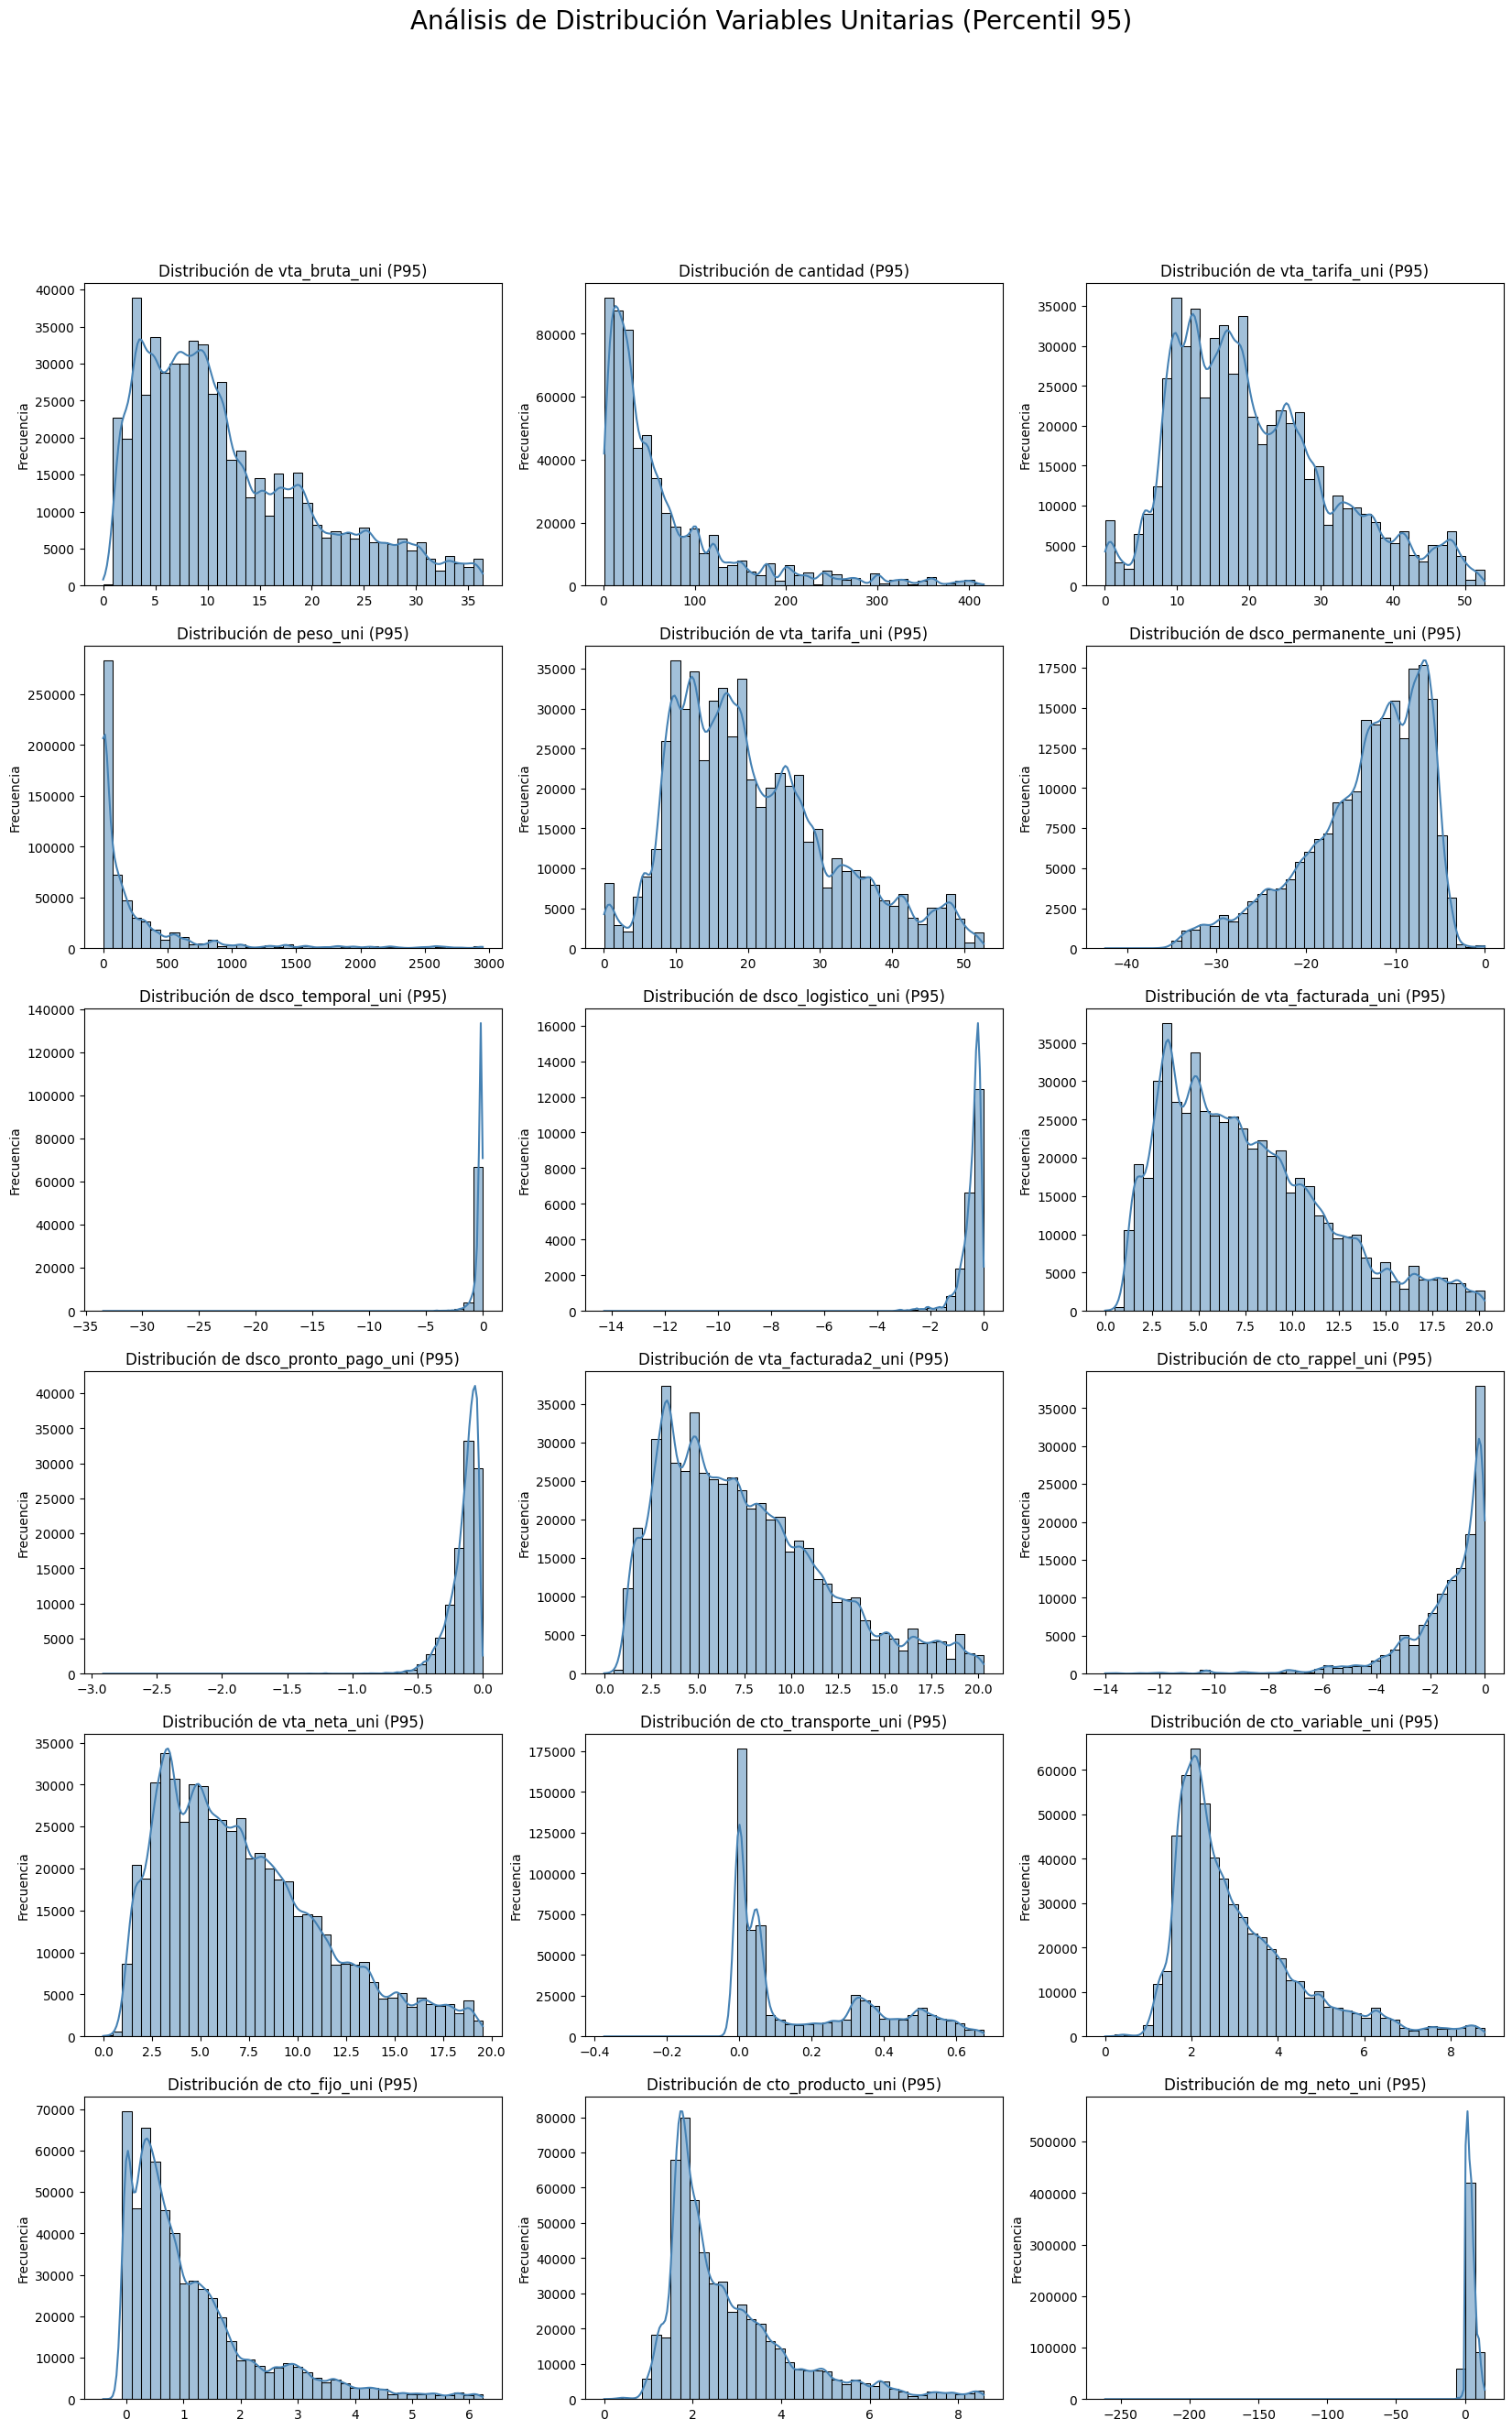

In [13]:
variables_histograma = [
    "vta_bruta_uni", "cantidad", "vta_tarifa_uni", "peso_uni", "vta_tarifa_uni", "dsco_permanente_uni",
    "dsco_temporal_uni", "dsco_logistico_uni", "vta_facturada_uni",
    "dsco_pronto_pago_uni", "vta_facturada2_uni", "cto_rappel_uni",
    "vta_neta_uni", "cto_transporte_uni", "cto_variable_uni", "cto_fijo_uni",
    "cto_producto_uni", "mg_neto_uni"
]

#Creamos proyecto_graficos como una copia del dataset original para futuros análisis
proyecto_graficos = proyecto_analisis.copy()

#Configuración para la vista de los histogramas
n_vars = len(variables_histograma)
cols_grid = 3
rows_grid = math.ceil(n_vars / cols_grid)

fig, axes = plt.subplots(nrows = rows_grid, ncols = cols_grid, figsize = (20, rows_grid * 5))
axes = axes.flatten()

#Creamos los histogramas
for i, col in enumerate(variables_histograma):
    if col in proyecto_analisis.columns:
        #Definimos el percenticil que usaremos, en este caso usaremos el percentil 95
        limite_superior = proyecto_analisis[col].quantile(0.95)
        datos = proyecto_analisis[proyecto_analisis[col] < limite_superior]

        sns.histplot(datos[col], kde = True, ax = axes[i], color = "steelblue", edgecolor = "black", bins = 40)
        axes[i].set_title(f"Distribución de {col} (P95)", fontsize=12)
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Frecuencia")

#Limpieza de ejes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Análisis de Distribución Variables Unitarias (Percentil 95)", fontsize=20)
plt.show()

Para el análisis de distribuciones, se utilizaron histogramas y percentil 95, esto se hizo principalmente para excluir posibles datos atípicos (outliers) que distorcionaran los gráficos y no permitían visualizarlos correctamente. De las gráficas podemos observar que todas presentan una distribución con sesgo positivo, lo cual indica que la mayoría de las ventas se encuentra en un rango unitario bajo.

Para el caso de variables como dsco_permanente_uni, dsco_temporal_uni, dsco_logistico_uni, dsco_pronto_pago_uni y cto_rappel_uni, si bien visualmente se observa lo opuesto, esto se debe a la naturaleza de los datos ya que están representados con valores negativos en el eje X.

Nota: dado que se esta en presencia de distribuciones con sesgo, en futuros modelos, y solo en caso de mejorar resultados, podría ser conveniente aplicar transformaciones (por ejemplo, logarítmicas) para que las distriibuciones tiendan a una normal.

### ANÁLISIS DE ESTACIONALIDAD

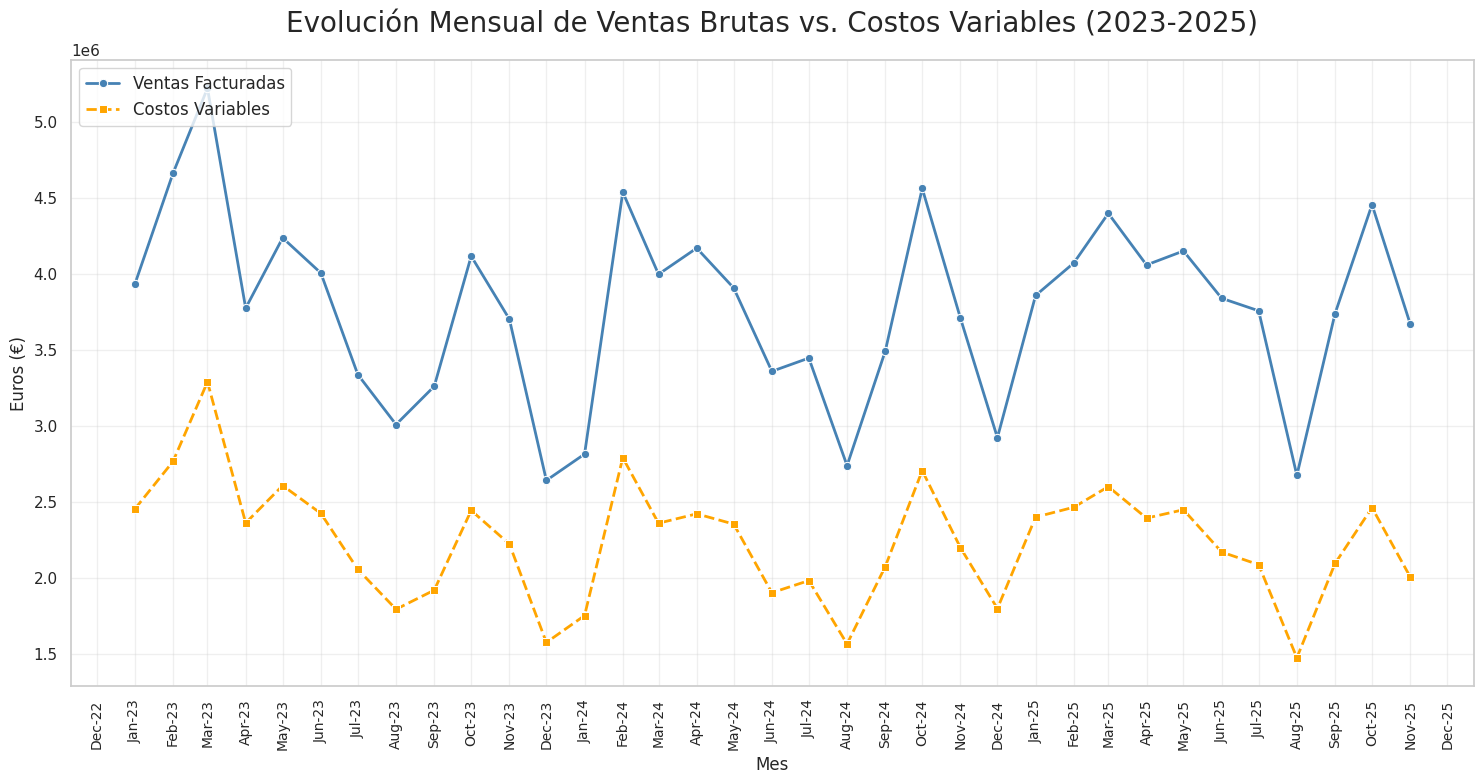

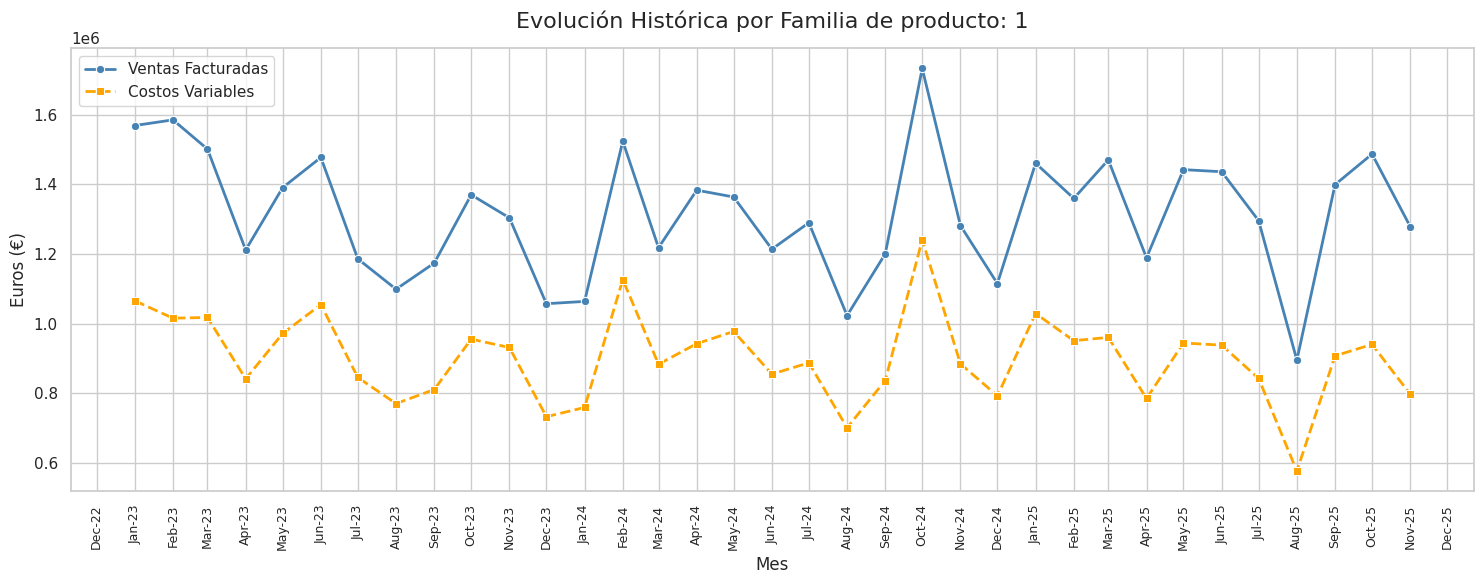

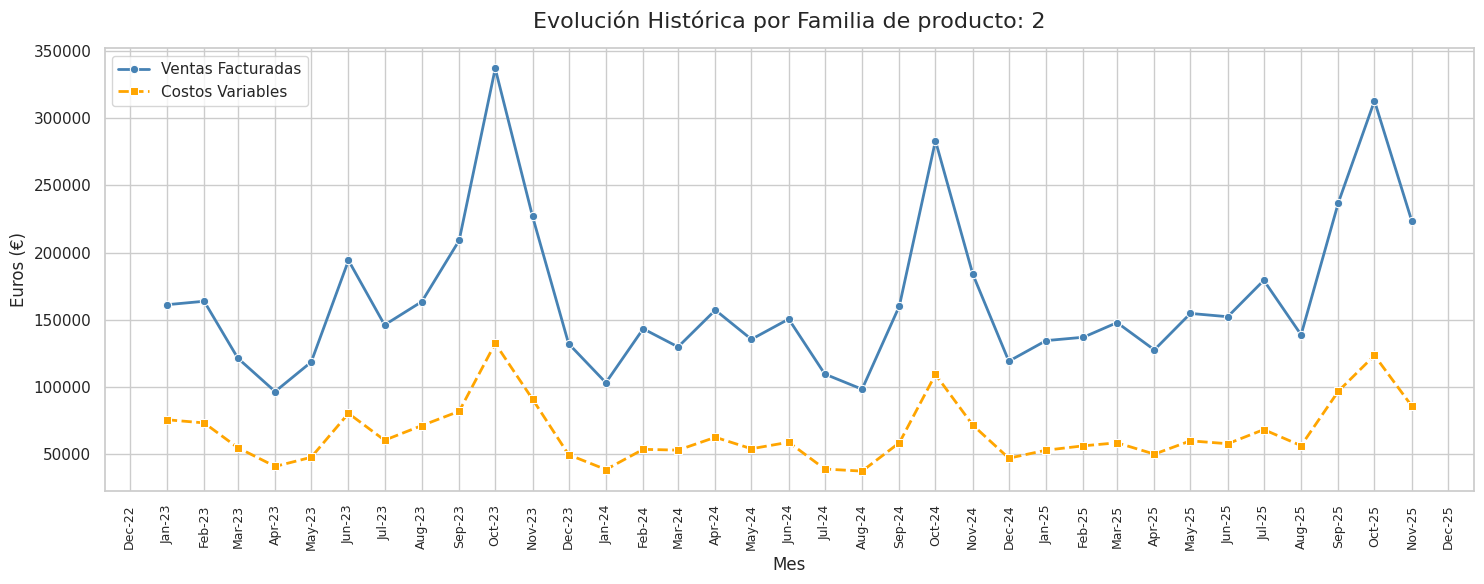

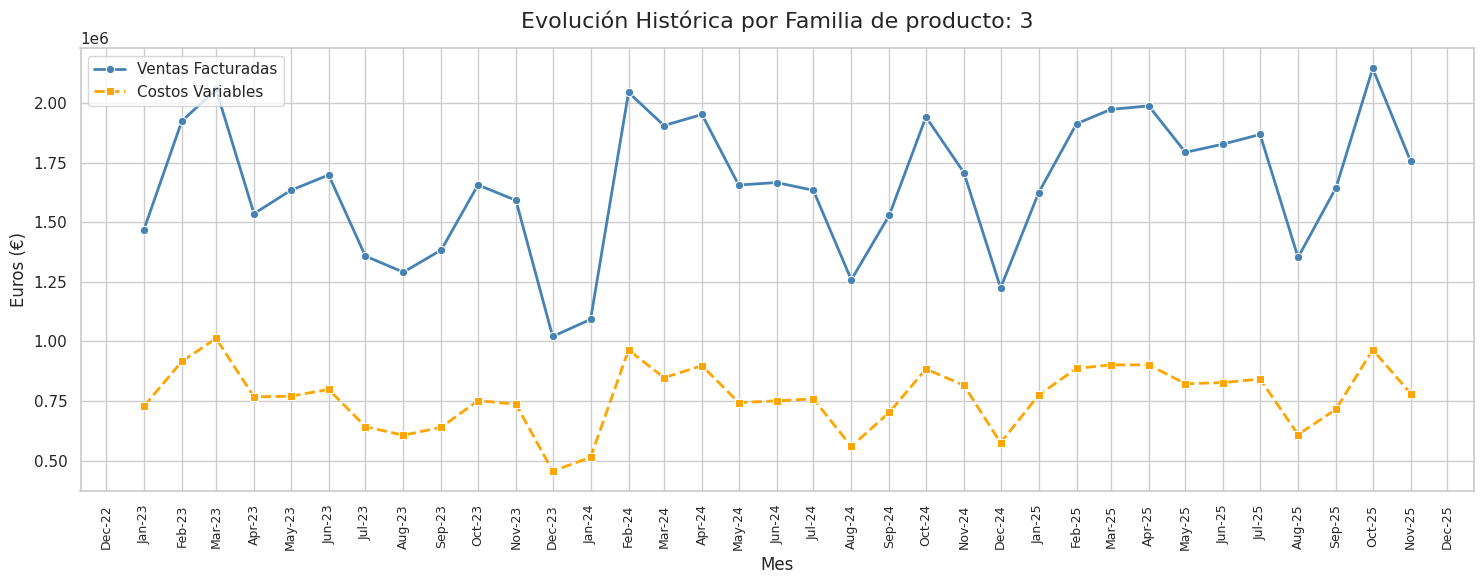

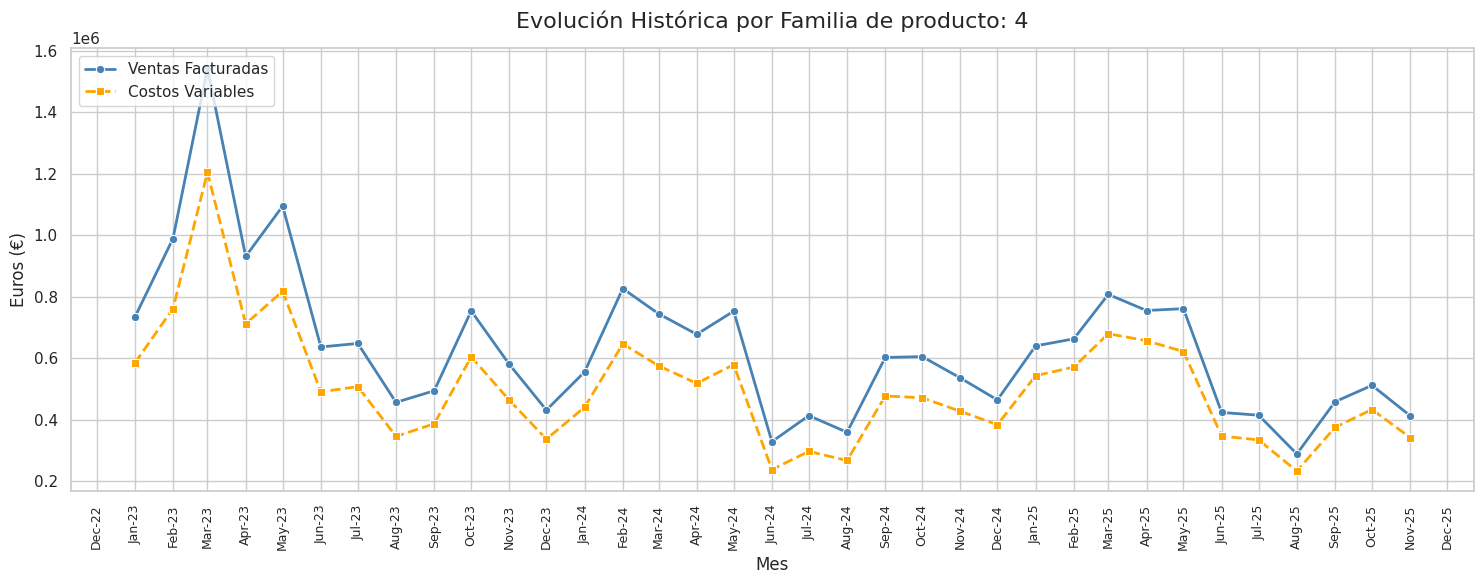

In [ ]:
#Creamos una columna de fecha, asumiendo el día 1 de cada mes
proyecto_graficos["fecha"] = pd.to_datetime(
    proyecto_graficos["Año"].astype(str) + "-" + proyecto_graficos["Mes"].astype(str) + "-01"
)

#Agrupamos por mes
evolucion_mensual = proyecto_graficos.groupby("fecha")[["vta_facturada2", "cto_variable"]].sum().reset_index()

plt.figure(figsize = (15, 8))
sns.set_theme(style = "whitegrid")

#General
#Gráfica de Ventas General
sns.lineplot(data = evolucion_mensual, x = "fecha", y = "vta_facturada2",
             marker = "o", color = "steelblue", linewidth = 2, label = "Ventas Facturadas")

#Gráfica de Costos General
sns.lineplot(data = evolucion_mensual, x = "fecha", y = "cto_variable",
             marker = "s", color = "orange", linewidth = 2, linestyle = "--", label = "Costos Variables")

#Formato del eje x
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))

#Formato del gráfico
plt.xticks(rotation = 90, fontsize = 10)
plt.title("Evolución Mensual de Ventas Brutas vs. Costos Variables (2023-2025)", fontsize = 20, pad = 20)
plt.xlabel("Mes", fontsize = 12)
plt.ylabel("Euros (€)", fontsize = 12)
plt.legend(fontsize = 12, loc = "upper left")
plt.grid(True, alpha = 0.3)

plt.tight_layout()
plt.show()

#Familia de producto
columna_familia = "Familia"
lista_familia = pd.Series(proyecto_graficos[columna_familia].unique()).sort_values()

for fam in lista_familia:
    proyecto_familia = proyecto_graficos[proyecto_graficos[columna_familia] == fam]
    evolucion_familia = proyecto_familia.groupby("fecha")[["vta_facturada2", "cto_variable"]].sum().reset_index()

    #Creación gráficos
    if not evolucion_familia.empty:
        plt.figure(figsize = (15, 6))
        sns.set_theme(style = "whitegrid")
        sns.lineplot(data = evolucion_familia, x = "fecha", y = "vta_facturada2",
                     marker = "o", color = "steelblue", linewidth = 2, label = "Ventas Facturadas")

        sns.lineplot(data = evolucion_familia, x = "fecha", y = "cto_variable",
                     marker = "s", color = "orange", linewidth = 2, linestyle = "--", label="Costos Variables")

        #Formato del eje X
        ax = plt.gca()
        ax.xaxis.set_major_locator(mdates.MonthLocator())
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%y"))

        #Formato del gráfico
        plt.title(f"Evolución Histórica por Familia de producto: {fam}", fontsize = 16, pad = 15)
        plt.xticks(rotation = 90, fontsize = 9)
        plt.xlabel("Mes")
        plt.ylabel("Euros (€)")
        plt.legend(loc = "upper left")

        plt.tight_layout()
        plt.show()

En la gráfica del evolutivo mensual de ventas facturadas - costos variables se observa que ambas variables mantienen un comportamiento similar sin presentar picos que no se puedan justificar (las curvas se mueven de manera proporcional), esto demuestra una buena politíca de costos alineada a la operación del negocio.

Además, se puede ver una alta volatibilidad explicada por los picos y valles recurrentes dentro de la gráfica. Teniendo esto en consideración, la variable de mes podría ser muy relevante para futuros modelos.

Adicionalmente, podemos observar que para las 4 familias de productos que se tienen, la familia 4 es la que presenta el margen más bajo de todas. El margen está representado por la zona entre ambas curvas.

### ANÁLISIS DE PARETO (ACB)

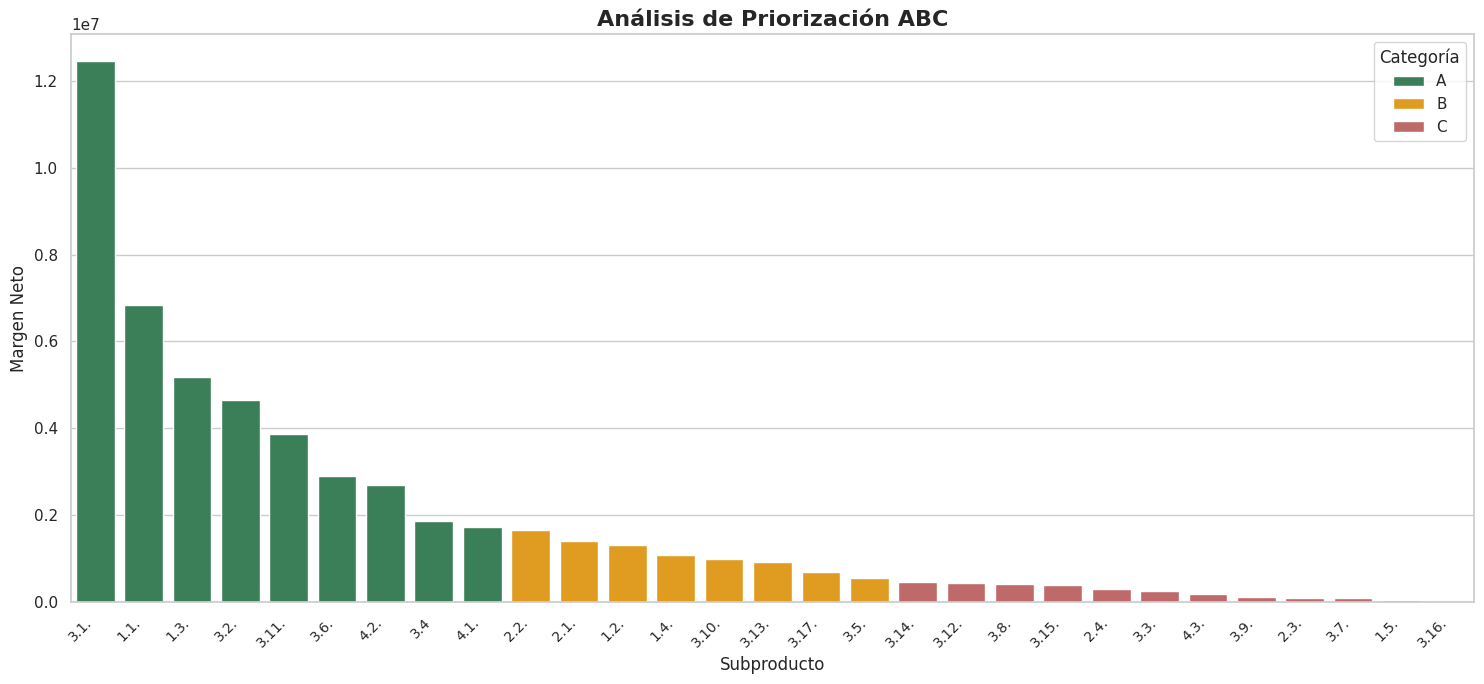

TABLA RESUMEN


,N° Productos,Ventas Netas Totales (€),% Ventas,Precio Neto Promedio (€),Elasticidad (Corr)
categoria_abc,,,,,
A,9,42203255.00,78.44,4.72,-0.09
B,8,8666849.81,16.11,5.74,-0.08
C,12,2931628.95,5.45,7.08,-0.01


In [ ]:
#Pareto ABC
#Agrupamos por Subfamilia para ver el peso de cada producto en la facturación
pareto_prod = proyecto_graficos.groupby("Subfamilia")["mg_neto"].sum().sort_values(ascending = False).reset_index()
pareto_prod["acumulado"] = pareto_prod["mg_neto"].cumsum()
pareto_prod["perc_acumulado"] = 100 * pareto_prod["acumulado"] / pareto_prod["mg_neto"].sum()

#Definimos los cortes según ventas brutas (80% A, 15% B, 5% C)
pareto_prod["categoria_abc"] = pd.cut(
    pareto_prod["perc_acumulado"],
    bins = [0, 80, 95, 100.01],
    labels = ['A', 'B', 'C'],
    include_lowest = True
)

#Integración de la segmentación
if "categoria_abc" in proyecto_graficos.columns:
    proyecto_graficos = proyecto_graficos.drop(columns = ["categoria_abc"])

proyecto_graficos = proyecto_graficos.merge(
    pareto_prod[["Subfamilia", "categoria_abc"]],
    on = "Subfamilia",
    how = "left"
)

#Creación de tabla resumen
def calcular_elasticidad(registros):
    # Relación entre Precio Unitario y Volumen vendido
    if len(registros) > 5: #Mínimo de datos para una correlación fiable
        return registros["mg_neto_uni"].corr(registros["cantidad"])
    return 0

resumen_tabla = proyecto_graficos.groupby("categoria_abc", observed = False).agg({
    "Subfamilia": "nunique",
    "mg_neto": "sum",
    "mg_neto_uni": "mean"
}).rename(columns = {
    "Subfamilia": "N° Productos",
    "mg_neto": "Ventas Netas Totales (€)",
    "mg_neto_uni": "Precio Neto Promedio (€)"
})

#Añadimos % de Ventas y Elasticidad (Correlación)
total_ventas = resumen_tabla["Ventas Netas Totales (€)"].sum()
resumen_tabla["% Ventas"] = (resumen_tabla["Ventas Netas Totales (€)"] / total_ventas) * 100
resumen_tabla["Elasticidad (Corr)"] = proyecto_graficos.groupby("categoria_abc", observed = False)[[
    "mg_neto_uni", "cantidad"]].apply(calcular_elasticidad)

#Gráfico pareto ABC
plt.figure(figsize = (15, 7))
sns.set_theme(style = "whitegrid")

grafico = sns.barplot(
    data = pareto_prod.head(40),
    x = "Subfamilia",
    y = "mg_neto",
    hue = "categoria_abc",
    palette = {"A": "seagreen", "B": "orange", "C": "indianred"},
    dodge = False
)

plt.xticks(rotation = 45, ha = "right", fontsize = 10)
plt.title("Análisis de Priorización ABC", fontsize = 16, fontweight = "bold")
plt.xlabel("Subproducto", fontsize = 12)
plt.ylabel("Margen Neto", fontsize = 12)
plt.legend(title = "Categoría")

plt.tight_layout()
plt.show()

#Mostrar tabla resumen
print("TABLA RESUMEN")
display(resumen_tabla[["N° Productos", "Ventas Netas Totales (€)", "% Ventas", "Precio Neto Promedio (€)", "Elasticidad (Corr)"]].round(2))

El pareto ABC muestra que el 80% de la venta se concentra principalmente en 9 productos, los cuales probablemente tiene una rotación alta y es donde se debería centrar el pricing ya que son los productos que tendrán más impacto en contribución para el negocio. En contra parte, los productos dentro de la categoría C solo representan el 5.5% de la venta, lo cual podría indicar que son prodcutos de baja rotación como, por ejemplo, repuestos.

Además, se observa una correlación negativa débil, lo cual es esperable para este tipo de problema. Es importante mencionar que esta baja correlación se debe a que se calculó utilizando la correlación de Pearson (lineal) y, nuestro caso, el precio o la demanda depende de múltiples factores. Esto nos da pie a pensar en utilizar un modelo de ML ya que tenemos un problema multidimensional donde debemos encontrar relaciones entre multiples variables para poder hacer predicciones y encontrar relaciones entre los datos.

Nota: para la visualización se utilizó la totalidad de los datos, no el P95.

### ANÁLISIS DE DISPERSIÓN (PRECIO VS CANTIDAD)

Buscando curvas para: ['3.1.', '1.1.', '1.3.', '3.2.', '3.11.', '3.6.', '4.2.', '3.4', '4.1.']
Producto: 3.1. | Filas encontradas: 250980
Producto: 1.1. | Filas encontradas: 20505
Producto: 1.3. | Filas encontradas: 6580
Producto: 3.2. | Filas encontradas: 33113
Producto: 3.11. | Filas encontradas: 78893
Producto: 3.6. | Filas encontradas: 51445
Producto: 4.2. | Filas encontradas: 5072
Producto: 3.4 | Filas encontradas: 22088
Producto: 4.1. | Filas encontradas: 4567


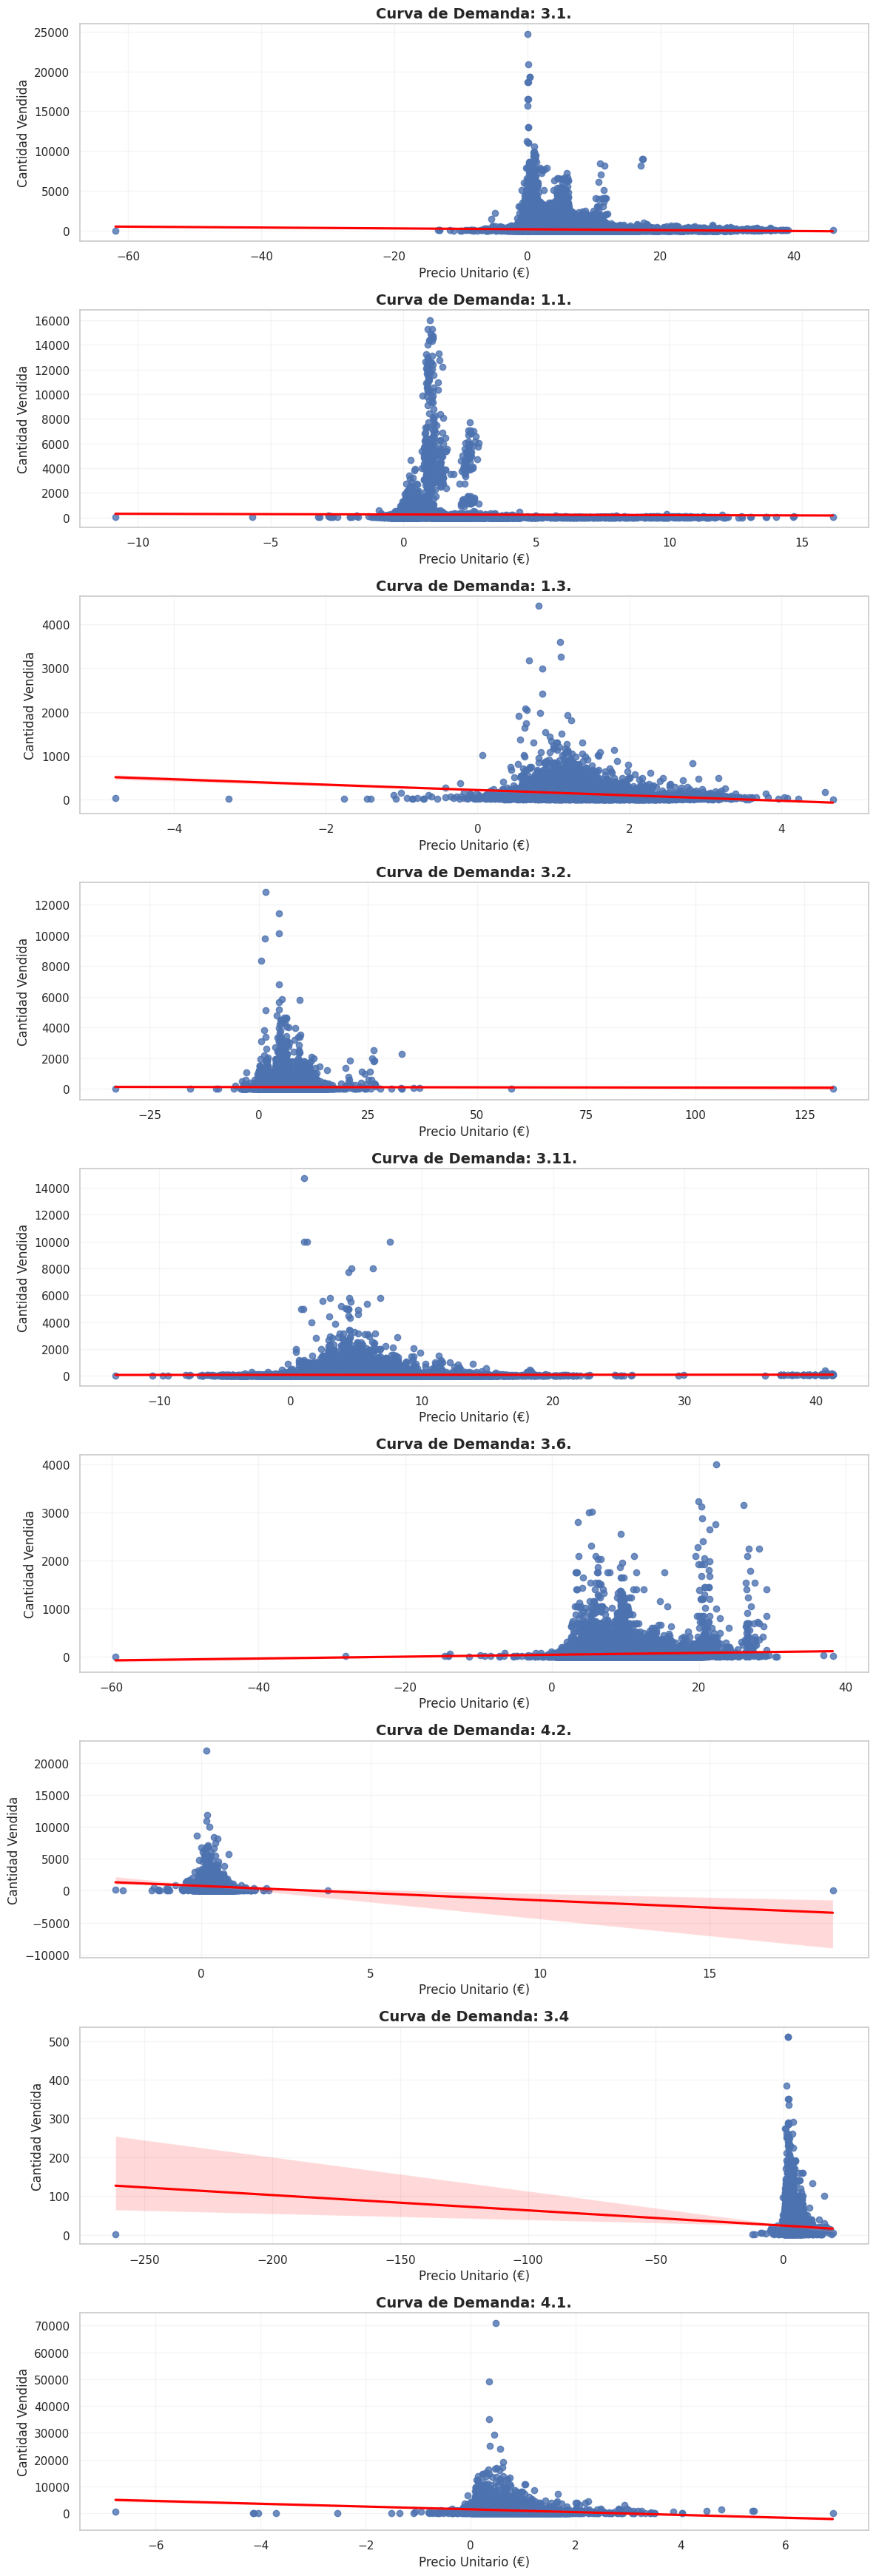

In [ ]:
#Obtenemos los productos de la categoría A
subproductos_A = pareto_prod.head(9)["Subfamilia"].tolist()

print(f"Buscando curvas para: {subproductos_A}")

#Estructura para visualizar un gráfico por fila
fig, axes = plt.subplots(nrows = 9, ncols = 1, figsize = (12, 35))

for i, subprod in enumerate(subproductos_A):
    data_plot = proyecto_graficos[proyecto_graficos["Subfamilia"] == subprod]


    print(f"Producto: {subprod} | Filas encontradas: {len(data_plot)}") #Cantidad de filas por producto

    if len(data_plot) > 2: #Tener al menos 3 puntos para trazar una línea
        sns.regplot(
            data = data_plot,
            x = "mg_neto_uni",
            y = "cantidad",
            ax = axes[i],
            line_kws = {"color": "red"}
        )
        axes[i].set_title(f"Curva de Demanda: {subprod}", fontsize = 14, fontweight = "bold")
    else:
        axes[i].text(0.5, 0.5, f"Datos insuficientes para {subprod}\n(Filas: {len(data_plot)})",
                     ha = "center", va = "center", fontsize = 12, color = "red")

    axes[i].set_xlabel("Precio Unitario (€)")
    axes[i].set_ylabel("Cantidad Vendida")
    axes[i].grid(True, alpha = 0.2)

plt.tight_layout()
plt.show()

El análisis de dispersión se centó en los productos correspondientes a la categoría A previamente definidos ya que son los que concetran el mayor volumen y contribución del negocio. En todos los productos se puede observa una relación inversa entre el precio y la cantidad vendida (línea roja), validando la sensibilidad de la industria a cambios en el precio.

También, se puede ver que la mayor concentración de puntos se encuenta en un rango de precios competitivos, lo cual se encuentra alineado con los histogramas presentados al incio y que mostraban sesgos positivos en la distribución de las variables.

Además, dado que los puntos en nuestro grafíco no se encuentran alineados a nuestra recta de elasticidad (línea roja), estaríamos en presencia de una elasticidad no lineal lo cual acentuaría la posibilidad de usar un modelo de ML para futuras predicciones.



### ANÁLISIS DIFERENCIACIÓN POR REGIÓN

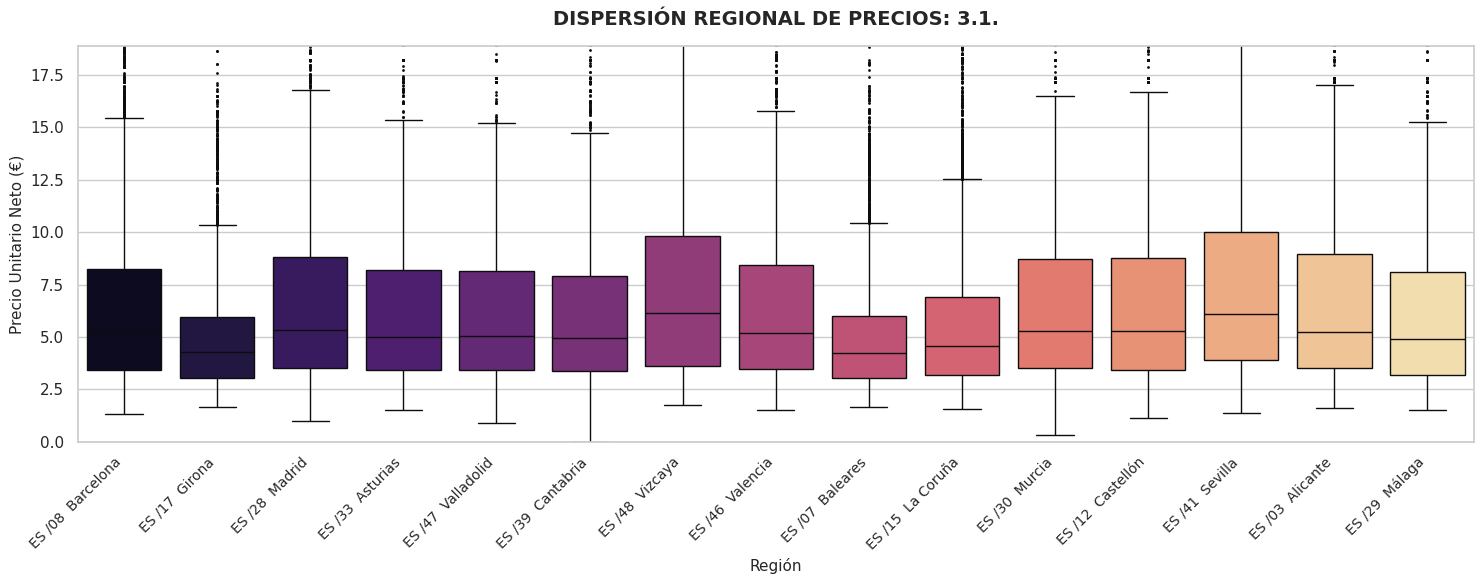

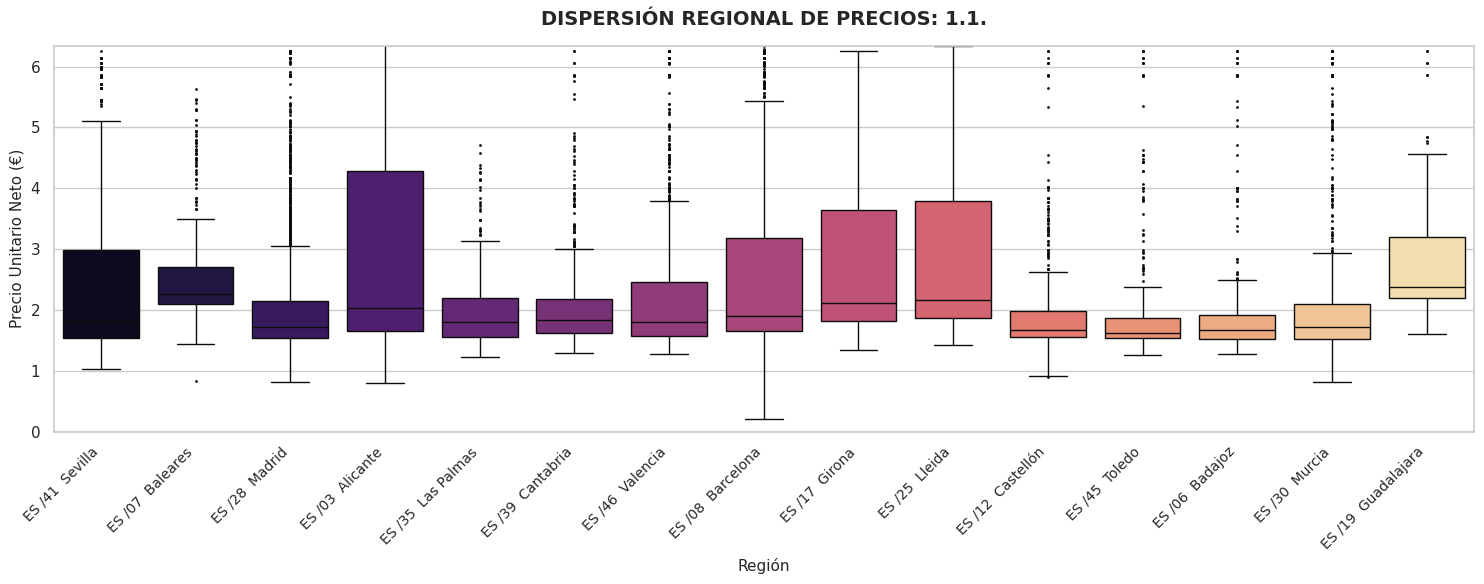

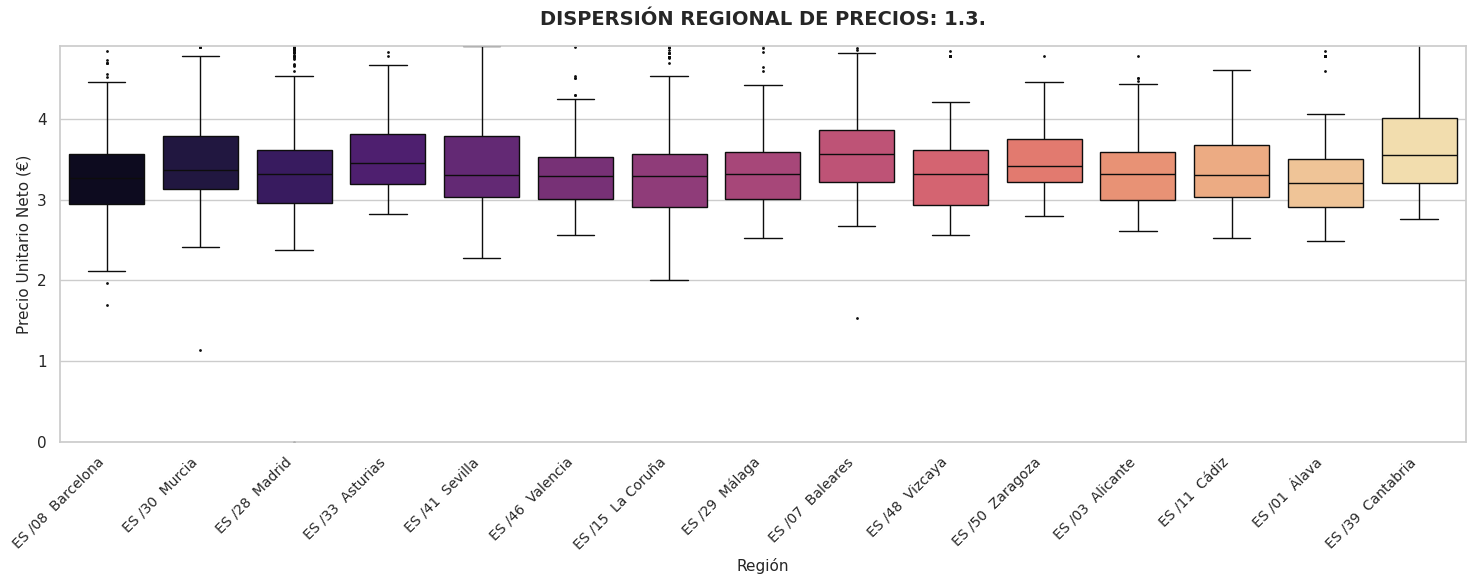

In [ ]:
#Gráficos de diferenciación por región para el top 3 de productos categoría A
#Identificamos los top 3 productos de la categoría A
top_3_subproductos = pareto_prod.head(3)["Subfamilia"].tolist()

#Crear gráfico para cada subproducto
for subprod in top_3_subproductos:

    #Filtramos los datos de proyecto_graficos para el producto actual
    proyecto_actual = proyecto_graficos[proyecto_graficos["Subfamilia"] == subprod].copy()

    #Identificamos las regiones con más movimiento para este producto específico
    top_regiones = proyecto_actual["Región"].value_counts().head(15).index
    data_plot2 = proyecto_actual[proyecto_actual["Región"].isin(top_regiones)]

    #Verificamos si hay datos suficientes
    if len(data_plot2) > 0:
        plt.figure(figsize = (15, 6))
        sns.set_style("whitegrid")

        #Gráfico de Boxplot
        sns.boxplot(
            data = data_plot2,
            x = "Región",
            y = "vta_facturada2_uni",
            hue = "Región",
            palette = "magma",
            legend = False,
            fliersize = 1  # Outliers pequeños
        )

        #Usamos el percentil 95 para no distorcionar la vista de las cajas
        limite = data_plot2["vta_facturada2_uni"].quantile(0.95)
        plt.ylim(0, limite * 1.1)
        plt.xticks(rotation = 45, ha = "right", fontsize = 10)
        plt.title(f"DISPERSIÓN REGIONAL DE PRECIOS: {subprod.upper()}", fontsize = 14, fontweight = "bold", pad = 15)
        plt.xlabel("Región", fontsize = 11)
        plt.ylabel("Precio Unitario Neto (€)", fontsize = 11)
        plt.tight_layout()
        plt.show()
    else:
        print(f"Sin datos suficientes para graficar {subprod}")

Para visualizar los gráficos de diferenciación por región se uso el top 3 de subproductos de la categoría A ya que son los que más contribución aportan al negocio y para cada uno de visualizaron 15 regiones para que el gráfico fuese legible.

En los gráfios se puede observar que según la región, y para cada subproducto, se tienen variabilidad a nivel del precio unitario, lo cual implica una estrategia de pricing diferenciado.

Además, se puede ver que las medianas de las cajas (línea interna) no son iguales, lo cual indica que el mercado acepta distintos precios según la ubicación.

También, para el caso de las cajas más largas, indica que los precios unitarios fluctuan más debido a posibles estrategias de descuentos para cada cliente. Por el contrario, las cajas más pequeñas o compactas, indicarían precios más estables.

### ANÁLISIS DE RANGO (PRECIOS)

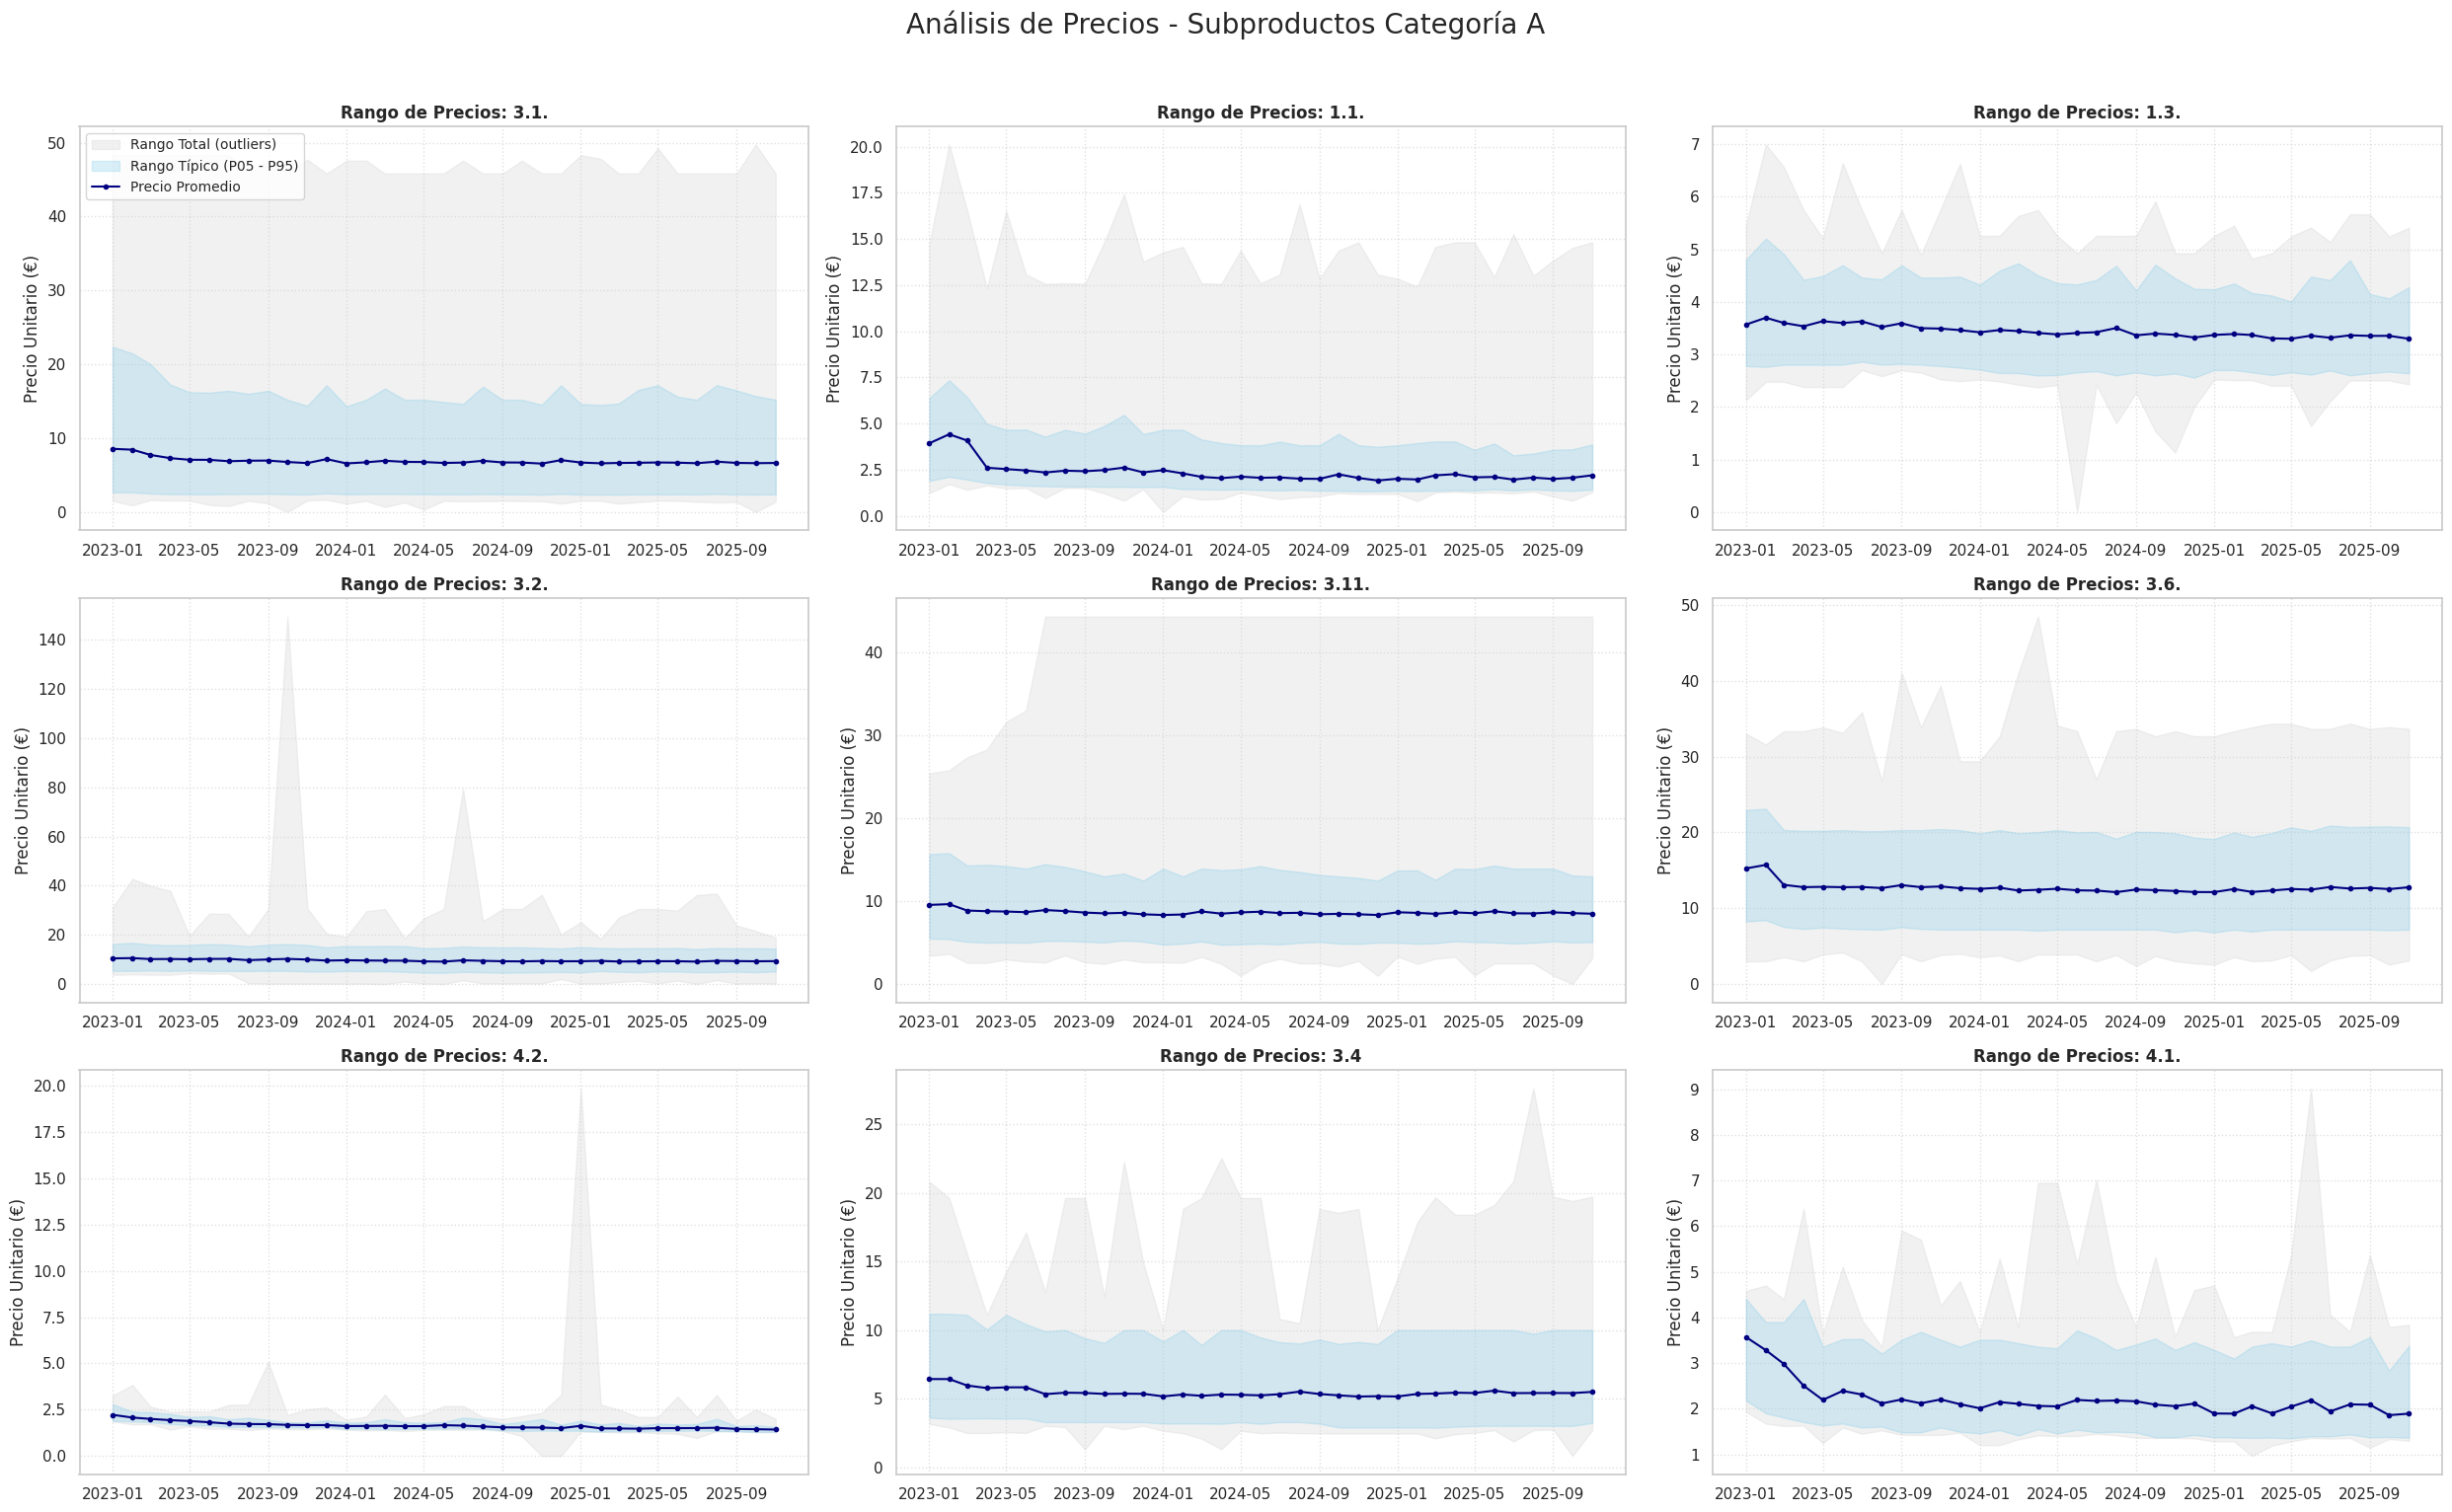

In [ ]:
#Configuración visualización de gráficos
cols_grid = 3
rows_grid = math.ceil(len(subproductos_A) / cols_grid)
fig, axes = plt.subplots(nrows = rows_grid, ncols = cols_grid, figsize  =(25, rows_grid * 5))
axes = axes.flatten()

#Creación de gráficos
for i, producto in enumerate(subproductos_A):
    #Filtrar datos del producto específico
    proyecto_prod = proyecto_graficos[proyecto_graficos["Subfamilia"] == producto].copy()

    #Agrupar por mes y calcular métricas
    resumen = proyecto_prod.groupby(proyecto_prod["fecha"].dt.to_period("M"))["vta_facturada2_uni"].agg(
        minimo = "min",
        maximo = "max",
        p05 = lambda x: x.quantile(0.05),
        p95 = lambda x: x.quantile(0.95),
        promedio = "mean"
    ).reset_index()

    #Convertir periodo a timestamp para el eje X
    resumen["fecha"] = resumen["fecha"].dt.to_timestamp()

    #Gráficos
    axes[i].fill_between(resumen["fecha"], resumen["minimo"], resumen["maximo"],
                         color = "lightgrey", alpha = 0.3, label = "Rango Total (outliers)")
    axes[i].fill_between(resumen["fecha"], resumen["p05"], resumen["p95"],
                         color = "skyblue", alpha = 0.3, label = "Rango Típico (P05 - P95)")
    axes[i].plot(resumen["fecha"], resumen["promedio"], color = "navy", marker = ".",
                 linewidth = 1.5, label = "Precio Promedio")
    axes[i].set_title(f"Rango de Precios: {producto}", fontsize = 12, fontweight = "bold")
    axes[i].set_ylabel("Precio Unitario (€)")
    axes[i].grid(True, linestyle = ":", alpha = 0.6)
    if i == 0: # Solo ponemos la leyenda en el primero para no saturar la vista completa
        axes[i].legend(loc = "upper left", fontsize = "small")

plt.suptitle("Análisis de Precios - Subproductos Categoría A", fontsize = 20, y = 1.02)
plt.tight_layout()
plt.show()

Para el análisis de precios se utilizaron dos capas para poder contrastar como fluctua el precio considerando la totalidad de los datos (zona gris) y como fluctua utilizando el precio en el rango del percetil 5% - percentil 95% (zona azul). Con esto se puede ver como se comporta el precio sin considerar las ventas grandes o con sobrepecio que detectamos al inicio de nuestro análisis.

Al observar las graficas, y haciendo foco en el comportamiento del precio en relación a la franja azul, podemos ver que se tiene un zona más mucho más estable respecto a la gris, lo cual es buena señal de cara a entrenar un modelo de ML. Los puntos que se encuentran en la zona gris también son muy relevantes ya que serán una pieza clave para que el modelo pueda aprender cuanto un cliente podría estar dispuesto a paagr más por un subproducto.

Además, se puede ver que la línea azul que representa el precio promedio unitario se situa más cerca de la parte inferior de la gráfica. Esto se encuentra alineado con las gráficas que hemos visto en apartados previos y podría indicar una estrategía de pricing más conservadora.


### ANÁLISIS DE CORRELACIÓN

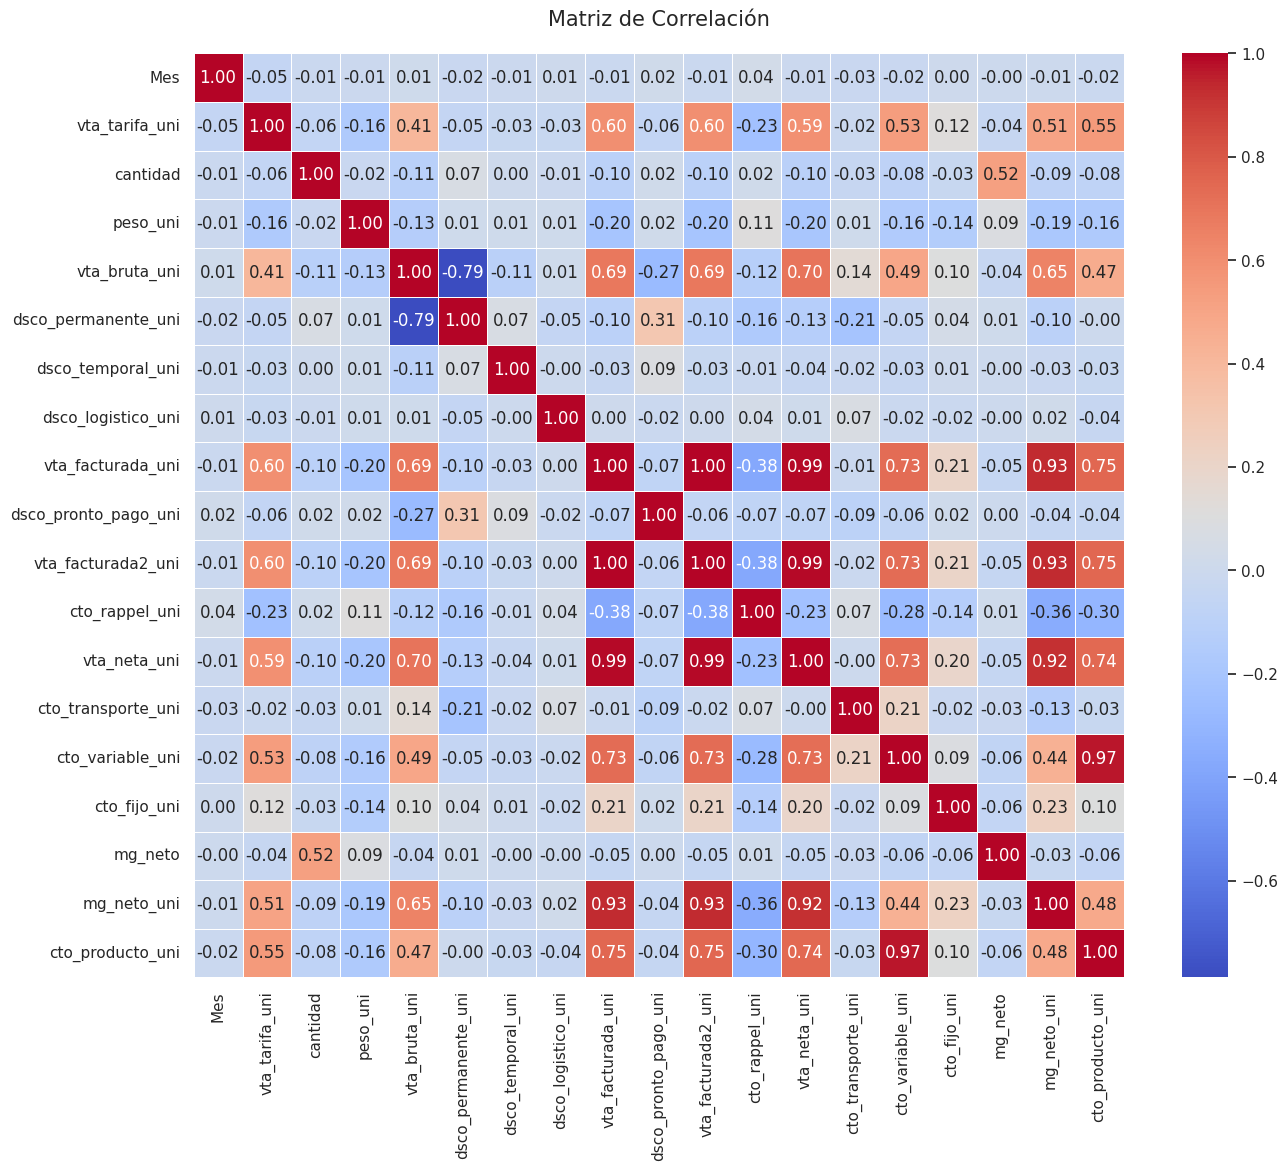

In [ ]:
#Matríz de Correlaciones

#Seleccionamos las variables que queremos analizar
variables_corr = [
    "Mes", "vta_tarifa_uni", "cantidad", "peso_uni", "vta_bruta_uni", "dsco_permanente_uni",
    "dsco_temporal_uni", "dsco_logistico_uni", "vta_facturada_uni",
    "dsco_pronto_pago_uni", "vta_facturada2_uni", "cto_rappel_uni",
    "vta_neta_uni", "cto_transporte_uni", "cto_variable_uni", "cto_fijo_uni",
    "mg_neto", "mg_neto_uni", "cto_producto_uni"
]

#Calculamos la matriz de correlación (Pearson)
matriz_corr = proyecto_graficos[variables_corr].corr()

#Configuración visual del gráfico
plt.figure(figsize = (15, 12))
sns.set_theme(style = "white")

#Gráfico
heatmap = sns.heatmap(
    matriz_corr,
    annot = True,
    cmap = "coolwarm",
    fmt = ".2f",
    linewidths = 0.5,
)

plt.title("Matriz de Correlación", fontsize=15, pad=20)
plt.show()

Por último, dentro del apartado del Análisis EDA, se incluyó una matriz de correlación para ver que tan relacionadas están las variables entre sí. Esto se hizo principalmente pensando en que, si se usarán modelos ML, para poder entrenar los modelos se deberán usar variables que no tengan una correlación alta entre sí (por ejemplo, mayor a 90%) para así no entregar al modelo información rebundante (multicolinealidad). De la matriz presentada, variables como vta_facturada2_uni, vta_facturada_uni,  o vta_neta_uni se podrían excluir de un posible modelo dada su alta correlación.

## II. ANÁLISIS DE CLIENTE

### ANÁLISIS DE PARETO (CLIENTES)

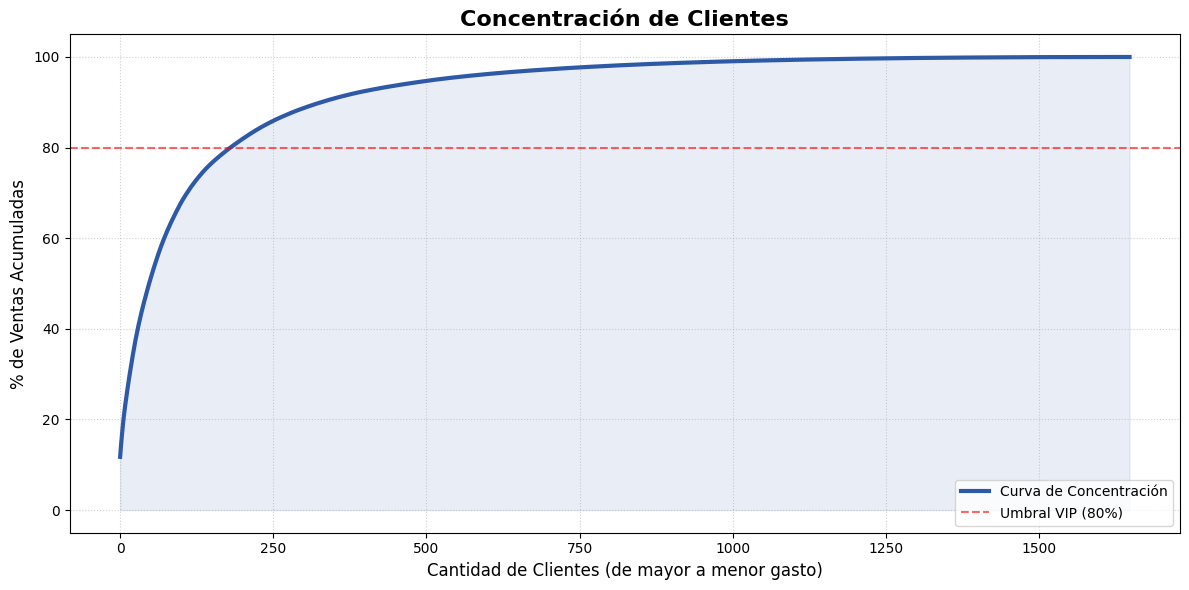

ESTUDIO DE SEGMENTACIÓN Y COMPORTAMIENTO DEL CLIENTE


,Segmento,N° Clientes,% Clientes,Ventas Totales (€),% Ventas,Gasto Medio por Cliente (€),Gasto Mediano por Cliente (€)
2,VIP (80%),180,10.92,1.056779e+08,80,587099.67,359592.27
0,Frecuentes (15%),336,20.38,1.995213e+07,15,59381.34,50325.98
1,Ocasionales (5%),1133,68.71,6.615441e+06,5,5838.87,3798.25


In [35]:
#Calculamos el gasto total por cada ID de cliente único
pareto_cli = proyecto_graficos.groupby("Cliente")["vta_facturada2"].sum().sort_values(ascending = False).reset_index()

#Cálculos de Pareto (Porcentaje Acumulado)
pareto_cli["perc_acumulado"] = 100 * pareto_cli["vta_facturada2"].cumsum() / pareto_cli["vta_facturada2"].sum()

#Clasificación Jerárquica de Clientes
def clasificar_segmento(p):
    if p <= 80: return 'VIP (80%)'
    if p <= 95: return 'Frecuentes (15%)'
    return 'Ocasionales (5%)'

pareto_cli["Segmento"] = pareto_cli["perc_acumulado"].apply(clasificar_segmento)

#Construcción de la Tabla Resumen
resumen_clientes = pareto_cli.groupby("Segmento", observed = False).agg({
    "Cliente": "count",
    "vta_facturada2": ["sum", "mean", "median"]
}).reset_index()

#Renombramos las columnas
resumen_clientes.columns = ["Segmento", "N° Clientes", "Ventas Totales (€)", "Gasto Medio por Cliente (€)", "Gasto Mediano por Cliente (€)"]

#Definimos el orden para la visualización
orden_logico = ["VIP (80%)", "Frecuentes (15%)", "Ocasionales (5%)"]
resumen_clientes["Segmento"] = pd.Categorical(resumen_clientes["Segmento"], categories = orden_logico, ordered = True)
resumen_clientes = resumen_clientes.sort_values("Segmento")

#Cálculos para la tabla
total_clientes = resumen_clientes["N° Clientes"].sum()
resumen_clientes["% Clientes"] = (resumen_clientes["N° Clientes"] / total_clientes) * 100
resumen_clientes["% Ventas"] = [80, 15, 5]

#Reordenar columnas
resumen_clientes = resumen_clientes[["Segmento", "N° Clientes", "% Clientes", "Ventas Totales (€)",
                                     "% Ventas", "Gasto Medio por Cliente (€)", "Gasto Mediano por Cliente (€)"]]

#Gráfico pareto
plt.figure(figsize = (12, 6))
plt.plot(range(len(pareto_cli)), pareto_cli["perc_acumulado"], color = "#2E59A7", linewidth = 3, label = "Curva de Concentración")
plt.fill_between(range(len(pareto_cli)), pareto_cli["perc_acumulado"], color = "#2E59A7", alpha = 0.1)

#Línea de referencia del segmento VIP (80%)
plt.axhline(y = 80, color = "red", linestyle = "--", alpha = 0.6, label = "Umbral VIP (80%)")

plt.title("Concentración de Clientes", fontsize = 16, fontweight = "bold")
plt.xlabel("Cantidad de Clientes (de mayor a menor gasto)", fontsize = 12)
plt.ylabel("% de Ventas Acumuladas", fontsize = 12)
plt.legend(loc = "lower right")
plt.grid(True, linestyle = ":", alpha = 0.6)
plt.tight_layout()
plt.show()

#Mostrar la tabla resumen
print("ESTUDIO DE SEGMENTACIÓN Y COMPORTAMIENTO DEL CLIENTE")
display(resumen_clientes.round(2))

Pedemos observar en la gráfica que de la totalidad de los clientes que se tienen, solo el 11% de ellos (180) conforman el 80% de las ventas, por lo cual ajustes de precio en estos clientes tendrán un mayor impacto a nivel de margen en comparación a clientes de otros segmentos.

Además, podemos ver una variación significativa entre los gastos medios y gastos medianos por cliente, donde el primero está fuertemente influenciado por las ventas grandes que identificamos inicialmente. Es importante mencionar que ambos valores corresponden a la foto de los 3 años, por lo cual si se quisiera tener el valor mensual habría que dividirlo por 35 meses.

### ANÁLISIS DE PERFIL DE COMPRA

/tmp/ipykernel_2580/948057094.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


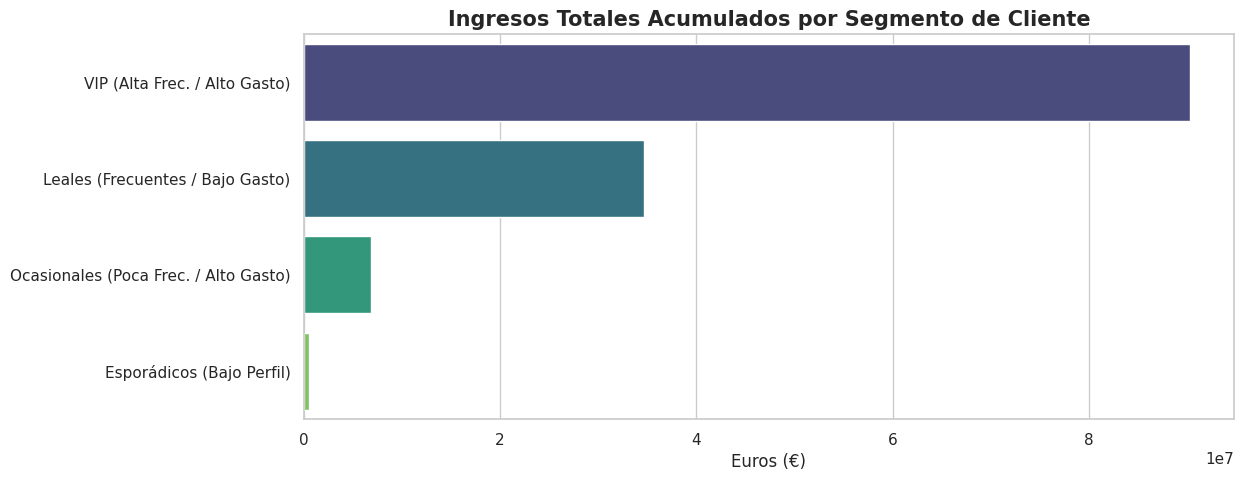

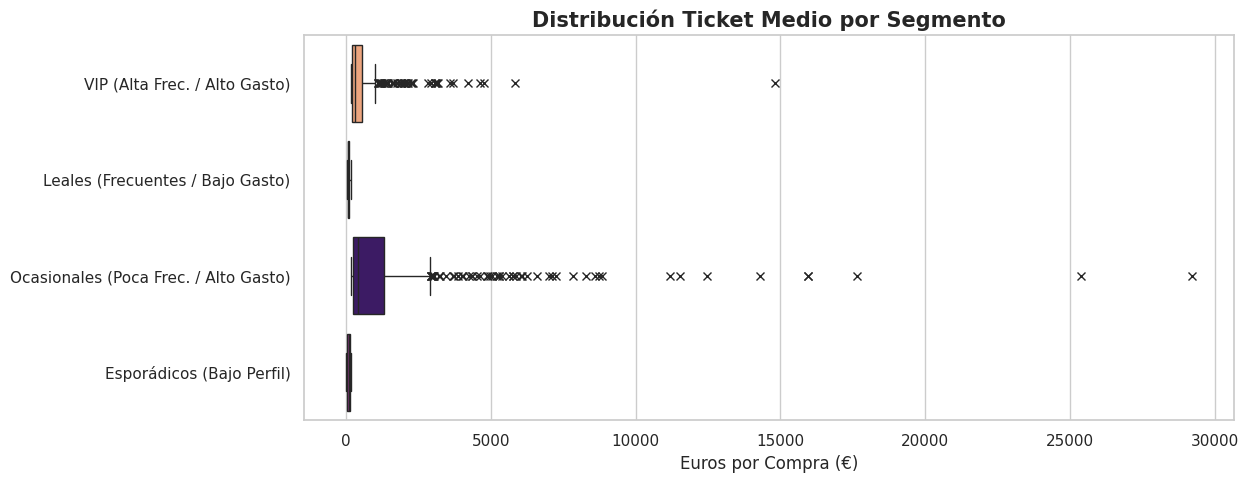

In [ ]:
#Calculamos las métricas base
proyecto_fidelidad = proyecto_graficos.groupby("Cliente").agg({
    "vta_facturada2": ["sum", "count", "mean"]
}).reset_index()
proyecto_fidelidad.columns = ["id_cliente", "gasto_total", "frecuencia", "ticket_medio"]

# 2. Clasificación de Segmentos
frecuencia = proyecto_fidelidad["frecuencia"].median()
ticket_medio = proyecto_fidelidad["ticket_medio"].median()

def clasificar_fidelidad(row):
    if row["frecuencia"] > frecuencia and row["ticket_medio"] > ticket_medio:
        return "VIP (Alta Frec. / Alto Gasto)"
    if row["frecuencia"] > frecuencia:
        return "Leales (Frecuentes / Bajo Gasto)"
    if row["ticket_medio"] > ticket_medio:
        return "Ocasionales (Poca Frec. / Alto Gasto)"
    return "Esporádicos (Bajo Perfil)"

proyecto_fidelidad["Segmento_Fidelidad"] = proyecto_fidelidad.apply(clasificar_fidelidad, axis = 1)

#Ordenamiento de los segmentos
orden_segmentos = proyecto_fidelidad.groupby("Segmento_Fidelidad")["gasto_total"].sum().sort_values(ascending = False).index

#Gráfico ingresos por segmento
plt.figure(figsize = (12, 5))
sns.set_theme(style = "whitegrid")

sns.barplot(
    data = proyecto_fidelidad,
    x = "gasto_total",
    y = "Segmento_Fidelidad",
    order = orden_segmentos,
    estimator = sum,
    errorbar = None,
    palette = "viridis"
)

plt.title("Ingresos Totales Acumulados por Segmento de Cliente", fontsize = 15, fontweight = "bold")
plt.xlabel("Euros (€)", fontsize = 12)
plt.ylabel("")
plt.show()

#Gráfico ticket medio por segmento
plt.figure(figsize = (12, 5))

sns.boxplot(
    data = proyecto_fidelidad,
    x = "ticket_medio",
    y = "Segmento_Fidelidad",
    hue = "Segmento_Fidelidad",
    order = orden_segmentos,
    palette = "magma",
    legend = False,
    flierprops = {"marker": "x"}
)

plt.title("Distribución Ticket Medio por Segmento", fontsize = 15, fontweight = "bold")
plt.xlabel("Euros por Compra (€)", fontsize = 12)
plt.ylabel("")
plt.show()

Las gráficas en conjunto nos indican que el segmento de clientes VIP es el que más contribución aporta al negocio teniendo un ticket medio (caja estrecha) mas alto que los Leales o Esporádicos. Por otro lado, el segmento Ocacionales representa un porcentaje menor de la contribución pero contiene la mayor cantidad de outliers a nivel de ticket medio y por lo cual podría ser un segmento más inelástico respecto a los demás. Por otro lado, a diferencia del segmento VIP u Ocasionales, el segmento Leales no presenta outliers y sus tickets medios son más bajos y constantes.

### ANÁLISIS DE COMPOSICIÓN DE LA COMPRA

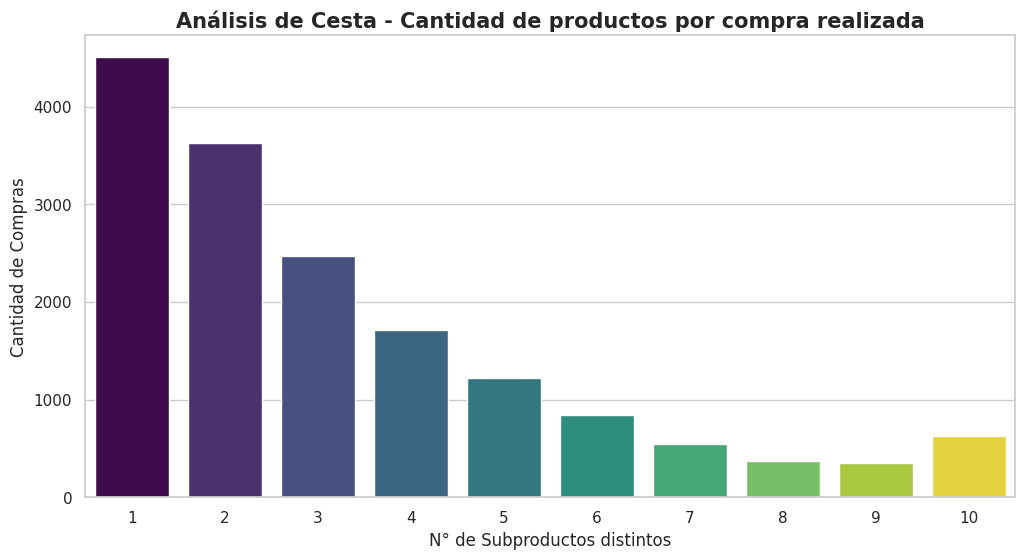

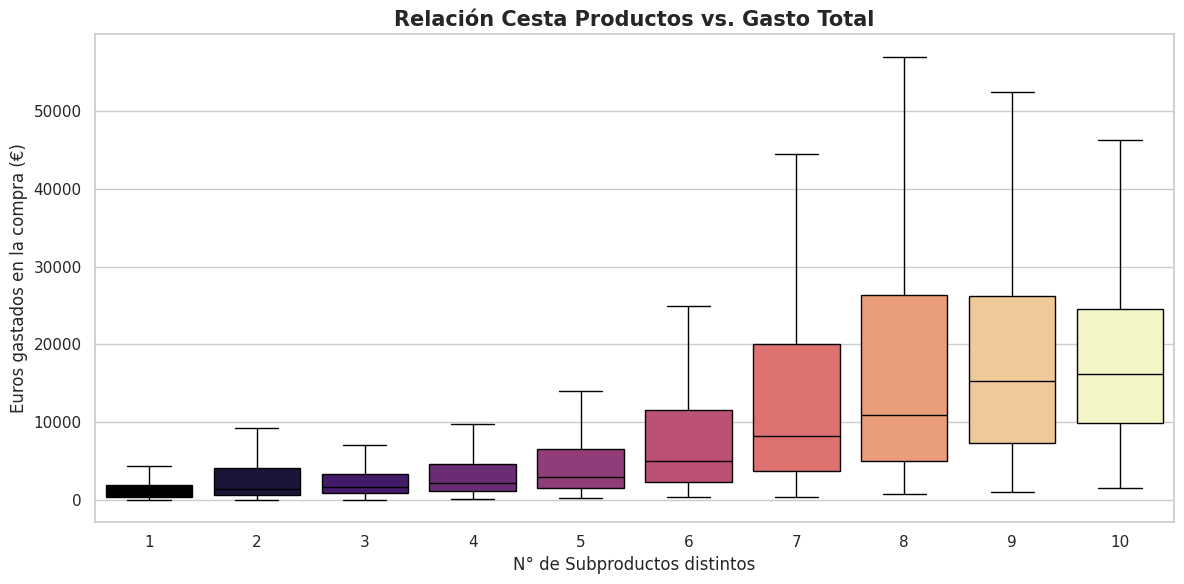

In [ ]:
#Cesta de Compra agrupando por cliente y fecha
proyecto_cesta = proyecto_graficos.groupby(["Cliente", "fecha"]).agg({
    "Subfamilia": "nunique", #Cuántos productos distintos se compraron ese día
    "vta_facturada2": "sum", #Total gastado en esa cesta
    "cantidad": "sum" #Unidades totales
}).reset_index()

#Renombramos las columnas
proyecto_cesta.columns = ["id_cliente", "fecha", "num_productos", "total_cesta", "total_unidades"]

#Gráfico de la cesta de compra
plt.figure(figsize = (12, 6))
sns.set_theme(style = "whitegrid")

#Filtramos por si acaso hay cestas muy grandes que ensucien el gráfico
sns.countplot(data = proyecto_cesta[proyecto_cesta["num_productos"] <= 10],
              x = "num_productos",
              hue = "num_productos",
              palette = "viridis",
              legend  =False)

plt.title("Análisis de Cesta - Cantidad de productos por compra realizada", fontsize = 15, fontweight = "bold")
plt.xlabel("N° de Subproductos distintos", fontsize = 12)
plt.ylabel("Cantidad de Compras", fontsize = 12)
plt.show()

#Gráfico gastos - subproductos
plt.figure(figsize = (12, 6))
sns.boxplot(data = proyecto_cesta[proyecto_cesta["num_productos"] <= 10],
            x = "num_productos",
            y = "total_cesta",
            hue = "num_productos",
            palette = "magma",
            showfliers = False,
            legend = False)

plt.title("Relación Cesta Productos vs. Gasto Total", fontsize = 15, fontweight = "bold")
plt.xlabel("N° de Subproductos distintos", fontsize = 12)
plt.ylabel("Euros gastados en la compra (€)", fontsize = 12)
plt.tight_layout()
plt.show()


La gráfica conjunta nos muestra que la mayor concentración de compras esta compuesta entre 1 a 4 subproductos y que existe una correlación positiva entra la composición de la compra y el gasto total (a mayor cantidad de subproductos se tiene un mayor gasto total).

Además, se puede observar que cuando las compras contienen pocos subproductos las cajas son más pequeñas, por lo cual se tiene un precio más estable y podrían ser más sensibles a variaciones.

### ANÁLISIS SUBPRODUCTOS GANCHOS

MEDIA GLOBAL DE ARRASTRE: 5.37
TOP 10 PRODUCTOS (REPRESENTATIVOS)


,Subfamilia,Indice_Arrastre_Real,Num_Operaciones,Representativo
28,3.15.,7.752998,2085,True
25,3.13.,7.613045,2499,True
19,3.5.,7.376605,2103,True
0,3.10.,6.752778,2880,True
20,3.4,6.588329,3153,True
26,3.17.,6.438313,2845,True
1,3.11.,4.846721,5017,True
18,1.3.,4.629328,1964,True
5,3.6.,4.518449,6911,True
17,3.2.,4.423830,2501,True


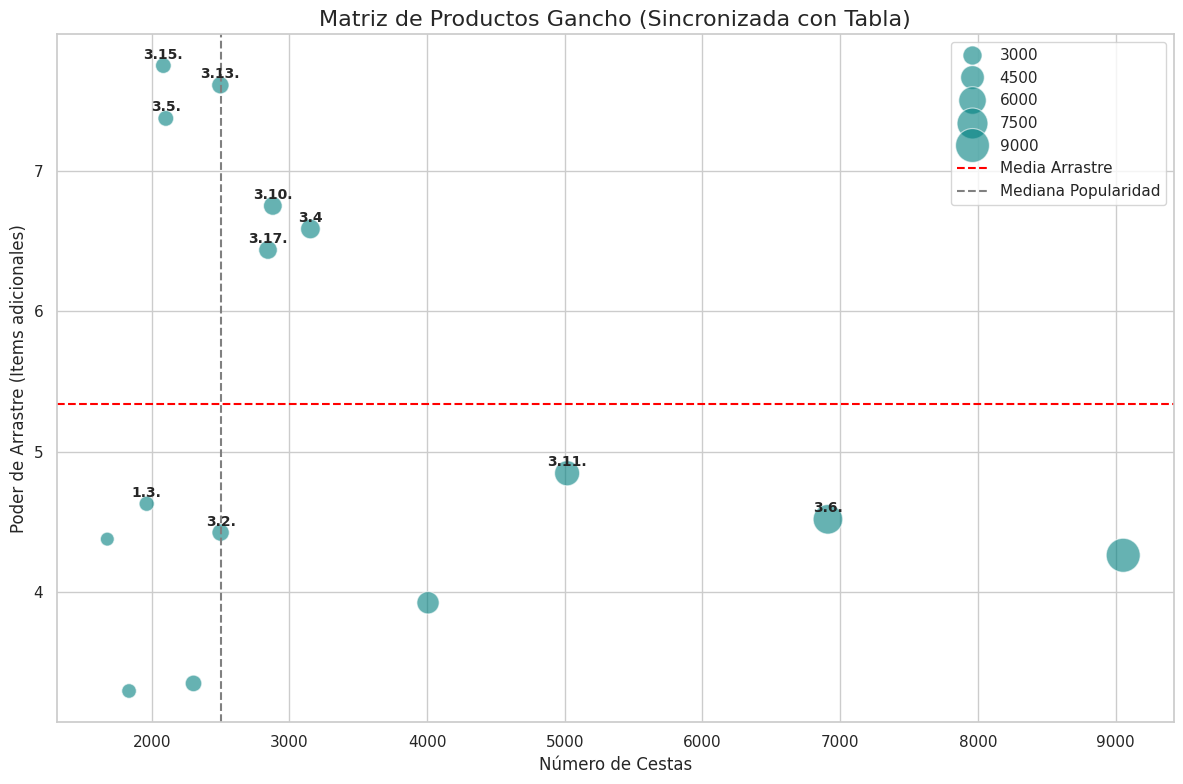

In [ ]:
#Creamos el ID de cesta de compra y limpiamos para tener 1 fila por subfamilia
proyecto_calculo = proyecto_graficos.assign(
    cesta_id = proyecto_graficos["Cliente"].astype(str) + "_" + proyecto_graficos["fecha"].astype(str)
).drop_duplicates(subset=["cesta_id", "Subfamilia"])

#Calculamos el tamaño de cada cesta (cuántas subfamilias distintas hay)
tamaño_cestas = proyecto_calculo.groupby("cesta_id")["Subfamilia"].nunique()

#Calculamos el índice de arrastre para cada producto
resultados = []
for subfam in proyecto_calculo["Subfamilia"].unique():
    #Cestas donde está éste producto
    ids_cesta_producto = proyecto_calculo[proyecto_calculo["Subfamilia"] == subfam]["cesta_id"]

    #Promedio de acompañantes (Tamaño total - 1)
    promedio_arrastre = tamaño_cestas[ids_cesta_producto].mean() - 1
    num_operaciones = len(ids_cesta_producto)

    resultados.append({
        "Subfamilia": subfam,
        "Indice_Arrastre_Real": promedio_arrastre,
        "Num_Operaciones": num_operaciones
    })

#Tabla resumen ordenada de mayor a menor
proyecto_final = pd.DataFrame(resultados).sort_values(by = "Indice_Arrastre_Real", ascending = False)

#Definimos representatividad (más de la mediana de operaciones)
mediana_operaciones = proyecto_final["Num_Operaciones"].median()
proyecto_final["Representativo"] = proyecto_final['Num_Operaciones'] >= mediana_operaciones

#Mostrar la tabla resumen
print(f"MEDIA GLOBAL DE ARRASTRE: {proyecto_final["Indice_Arrastre_Real"].mean():.2f}")
print("TOP 10 PRODUCTOS (REPRESENTATIVOS)")
display(proyecto_final[proyecto_final["Representativo"] == True].head(10))

#Creamos gráfico
plt.figure(figsize = (12, 8))
sns.set_theme(style = "whitegrid")

#Gráfico de potenciales productos ganchos
data_plot3 = proyecto_final[proyecto_final["Representativo"] == True]

sns.scatterplot(
    data = data_plot3, x = "Num_Operaciones", y = "Indice_Arrastre_Real",
    size = "Num_Operaciones", sizes = (100, 600), alpha = 0.6, color = "teal"
)

#Líneas de referencia para los cuadrantes
plt.axhline(data_plot3["Indice_Arrastre_Real"].mean(), color = "red", linestyle = "--", label = "Media Arrastre")
plt.axvline(data_plot3["Num_Operaciones"].median(), color = "gray", linestyle = "--", label = "Mediana Popularidad")

#Etiquetas para los Top productos ganchos
top_etiquetas = data_plot3.nlargest(10, "Indice_Arrastre_Real") #Acá se define la cantidad de etiquetas que aparecen
for i, row in top_etiquetas.iterrows():
    plt.text(row.Num_Operaciones, row.Indice_Arrastre_Real + 0.05, row.Subfamilia,
             fontsize = 10, fontweight = "bold", ha = "center")

plt.title("Matriz de Productos Gancho (Sincronizada con Tabla)", fontsize = 16)
plt.xlabel("Número de Cestas")
plt.ylabel("Poder de Arrastre (Items adicionales)")
plt.legend(loc = "upper right")
plt.tight_layout()
plt.show()

La gráfica permite visualizar el poder de arrastre que tienen las distintas subfamias de producto. Dado que lo más interesante es analizar aquellos productos que tienen mayor poder de arrastre, nos debemos enfocar los cuadrantes superiores. El cuadrante superior derecho muestra los productos ganchos (presente en muchas cestas y con alto poder de arrastre, son los productos "idelaes"), el superior izquierda se enfoca más en productos gancho de nicho ya que que están presentes en una manor cantidad de canastas en comparación a los otros pero con un alto poder de arrastre.
Si quieremos analizar los cuadrantes inferiores, es importante tener en cuanta que el cuadrante inferior de la derecha representa productos básicos (presentes es muchas cestas pero con bajo poder arrastre), mientras que el cuadrante inferior de la izquiera representa productos de bajo rendimiento (se vende poco y tiene bajo poder de arrastre)

In [ ]:
#Top 5 productos con mayor Indice de Arrastre y que cumplan con ser representativos
top_5_ganchos = proyecto_final[proyecto_final["Representativo"] == True].nlargest(5, "Indice_Arrastre_Real")["Subfamilia"].tolist()

print(f"Analizando los 5 ganchos principales: {top_5_ganchos}\n")

#Analizamos la afinidad con los productos de las cestas
for gancho in top_5_ganchos:
    # IDs de cestas donde aparece este gancho
    cestas_con_gancho = proyecto_calculo[proyecto_calculo["Subfamilia"] == gancho]["cesta_id"]
    total_ventas_gancho = len(cestas_con_gancho)

    #Buscamos a los acompañantes
    compañeros = proyecto_calculo[
        (proyecto_calculo["cesta_id"].isin(cestas_con_gancho)) &
        (proyecto_calculo["Subfamilia"] != gancho)
    ]

    #Contamos y calculamos probabilidad
    afinidad = compañeros["Subfamilia"].value_counts().reset_index()
    afinidad.columns = ["Subfamilia_Acompañante", "Frecuencia"]
    afinidad["Probabilidad_%"] = (afinidad["Frecuencia"] / total_ventas_gancho) * 100

    #Mostrar las tablas resumen
    print(f"PRODUCTO GANCHO: {gancho} (visto en {total_ventas_gancho} cestas)")
    print(f"Top 3 productos que arrastra con más frecuencia:")
    display(afinidad.head(3))

Analizando los 5 ganchos principales: ['3.15.', '3.13.', '3.5.', '3.10.', '3.4']

PRODUCTO GANCHO: 3.15. (visto en 2085 cestas)
Top 3 productos que arrastra con más frecuencia:


,Subfamilia_Acompañante,Frecuencia,Probabilidad_%
0,3.10.,1958,93.908873
1,3.1.,1941,93.093525
2,3.11.,1520,72.901679


PRODUCTO GANCHO: 3.13. (visto en 2499 cestas)
Top 3 productos que arrastra con más frecuencia:


,Subfamilia_Acompañante,Frecuencia,Probabilidad_%
0,3.1.,2427,97.118848
1,3.6.,1843,73.749500
2,3.11.,1655,66.226491


PRODUCTO GANCHO: 3.5. (visto en 2103 cestas)
Top 3 productos que arrastra con más frecuencia:


,Subfamilia_Acompañante,Frecuencia,Probabilidad_%
0,3.1.,1711,81.359962
1,3.6.,1544,73.418925
2,3.11.,1424,67.712791


PRODUCTO GANCHO: 3.10. (visto en 2880 cestas)
Top 3 productos que arrastra con más frecuencia:


,Subfamilia_Acompañante,Frecuencia,Probabilidad_%
0,3.1.,2611,90.659722
1,3.15.,1958,67.986111
2,3.6.,1832,63.611111


PRODUCTO GANCHO: 3.4 (visto en 3153 cestas)
Top 3 productos que arrastra con más frecuencia:


,Subfamilia_Acompañante,Frecuencia,Probabilidad_%
0,3.1.,2683,85.093562
1,3.6.,2050,65.017444
2,3.11.,1942,61.592134


Teniendo ya identificados los productos gancho (gráfica de cuadrantes), es importante analizar si efectivamente son gancho y con que producto lo son. Las tablas muestran los 5 productos gancho más relevantes y, para cada uno de ellos, la probabilidad con la que algunos productos se suelen vender en conjunto. Se puede decir que producto X es gancho del producto Y si la probabilidad con la que se vende Y junto a X es superior al 85% (este porcentaje puede variar según como lo defina el negocio, pero sobre un 80% ya es un porcentaje significativo).

### ANÁLISIS TOP CLIENTES (VENTA)

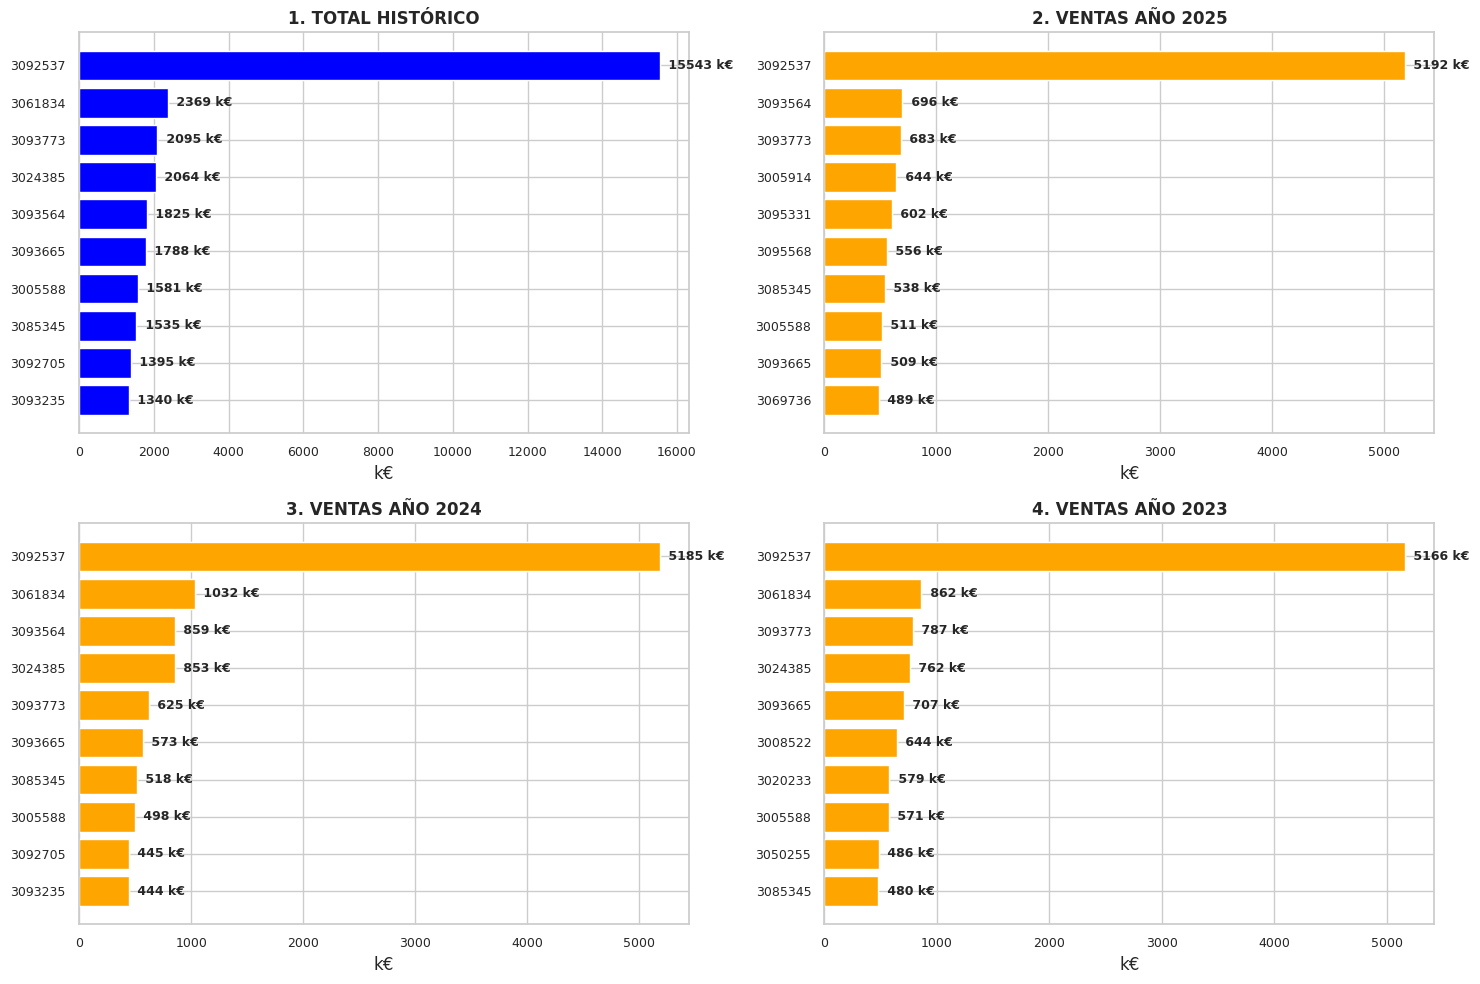

In [ ]:
col_ventas = "vta_facturada2"
años = sorted(proyecto_graficos["Año"].dropna().unique(), reverse=True)

#Creación de los gráficos y ajustes de visualización
fig, axes = plt.subplots(2, 2, figsize = (15, 10))
axes = axes.flatten()

for i in range(4):
    ax = axes[i]
    if i == 0:
        #Datos Históricos
        data_plot4 = proyecto_graficos.groupby("Cliente")[col_ventas].sum().nlargest(10).reset_index()
        titulo = "1. TOTAL HISTÓRICO"
        color = "blue"
    elif (i-1) < len(años):
        #Datos por Año
        año = años[i-1]
        data_plot4 = proyecto_graficos[proyecto_graficos["Año"] == año].groupby("Cliente")[col_ventas].sum().nlargest(10).reset_index()
        titulo = f"{i+1}. VENTAS AÑO {año}"
        color = "orange"
    else:
        ax.axis("off")
        continue

    #Gráficos
    bars = ax.barh(data_plot4["Cliente"].astype(str), data_plot4[col_ventas] / 1000, color = color)
    ax.barh(data_plot4["Cliente"].astype(str), data_plot4[col_ventas] / 1000, color = color)
    ax.bar_label(bars, fmt = ' %.0f k€', padding = 3, fontsize = 9, fontweight = "bold")
    ax.set_title(titulo, fontsize = 12, fontweight = "bold")
    ax.invert_yaxis()

    #Fijamos los límites del eje X
    ax.set_xlabel("k€")
    ax.tick_params(axis = "both", which = "major", labelsize = 9)

plt.tight_layout()
plt.show()

## IV. INGENIERIA DE VARIABLES

Luego de analizar las distintas variables en el análisis EDA, se evidenció la necesidad realizar una separación del dataset para cada país para así poder aplicar las etapas de ingeniería de variables, clustering y modelos de Machine Learning a cada uno de ellos.

In [10]:
#Separación del dataset según país
proyecto_analisis['pais_id'] = np.where(proyecto_analisis['Región'].str.startswith('ES'), 1, np.where(proyecto_analisis['Región'].str.startswith('PT'), 2, 0))

nombre_pais = {1: "España", 2: "Portugal", 0: "No identificado"}
print(proyecto_analisis['pais_id'].value_counts().rename(index = nombre_pais).to_frame('Registros'))

          Registros
pais_id            
España       589042
Portugal      11071


Creamos una función para poder aplicar ingeniería de variables a cada uno de los dataset definidos anteriormente. Las variables nuevas tienen como propósito poder aportar información adicional apartir de las variables iniciales del dataset. Esto puede ayudar a obtener mejores resultados en futuras etapas como clustering o modelos de Machine Learning.

In [11]:
#Función para creación de variables
def ingenieria_variables(datos):
  proyecto_clustering = datos.copy()

  #Variables de tiempo (mes)
  proyecto_clustering["mes_seno"] = np.sin(2 * np.pi * proyecto_clustering["Mes"] / 12)
  proyecto_clustering["mes_coseno"] = np.cos(2 * np.pi * proyecto_clustering["Mes"] / 12)

  #Variables de margen
  proyecto_clustering["porcentaje_margen_bruto"] = (proyecto_clustering["vta_bruta_uni"] - proyecto_clustering["cto_variable_uni"]) / proyecto_clustering["vta_bruta_uni"]
  proyecto_clustering["porcentaje_dsco"] = (proyecto_clustering["vta_bruta_uni"] - proyecto_clustering["vta_facturada2_uni"]) / proyecto_clustering["vta_bruta_uni"]
  proyecto_clustering["markup"] = proyecto_clustering["vta_bruta_uni"] / proyecto_clustering["cto_variable_uni"]

  #Variables de precio
  mean_prod = proyecto_clustering.groupby("Subfamilia")["vta_bruta_uni"].transform("mean")
  std_prod = proyecto_clustering.groupby("Subfamilia")["vta_bruta_uni"].transform("std")
  proyecto_clustering["z_score_precio"] = (proyecto_clustering["vta_bruta_uni"] - mean_prod) / std_prod
  proyecto_clustering["coeficiente_variacion_precio"] = (std_prod / mean_prod)

  mean_markup = proyecto_clustering.groupby("Subfamilia")["markup"].transform("mean")
  proyecto_clustering["desviacion_markup"] = proyecto_clustering["markup"] - mean_markup

  #Variables de cantidad
  mean_qty = proyecto_clustering.groupby("Subfamilia")["cantidad"].transform("mean")
  proyecto_clustering["ratio_volumen"] = proyecto_clustering["cantidad"] / mean_qty
  proyecto_clustering["ratio_volumen_log"] = np.log1p(proyecto_clustering["ratio_volumen"]) #Recomendada para dataset grandes

  #Variable de descuento
  mean_dsco = proyecto_clustering.groupby("Subfamilia")["porcentaje_dsco"].transform("mean")
  proyecto_clustering["agresividad_promo"] = proyecto_clustering["porcentaje_dsco"] - mean_dsco

  proyecto_clustering = proyecto_clustering.replace([np.inf, -np.inf], np.nan)
  proyecto_clustering = proyecto_clustering.fillna(0)

  return proyecto_clustering

Aplicamos la ingeniería de variables a cada dataset haciendo uso de la función creada anteriormente.

In [12]:
proyecto_españa = proyecto_analisis[proyecto_analisis["pais_id"] == 1].copy()
proyecto_portugal = proyecto_analisis[proyecto_analisis["pais_id"] == 2].copy()

#Aplicamos la ingeniería de forma INDEPENDIENTE
proyecto_españa_ingenieria = ingenieria_variables(proyecto_españa)
proyecto_portugal_ingenieria = ingenieria_variables(proyecto_portugal)

print(f"Ingeniería completada. Registros ES: {len(proyecto_españa_ingenieria)} | PT: {len(proyecto_portugal_ingenieria)}")

Ingeniería completada. Registros ES: 589042 | PT: 11071


## III. CLUSTERING

In [13]:
#Importación de librerias generales para Clustering
from scipy.cluster.hierarchy import fcluster
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

Aplicamos percentil 85 para separar los dataset en segmentos minorista (85%) y mayorista (15%). Luego, para el caso del dataset de España que tienen una mayor cantidad de registros, tomamos una muestra significativamente representativa (25k de registros) para aplicar distintos algoritmos de clustering y ver si logran segmentar los datos. Esto se hace ya que los algoritmos trabajan con distancias y, al tener tantos resgistro, el algormitmo debe procesar un matriz con un coste computacional muy elevado lo cual fuerza el cierre de la sesión.
Para el caso de Portugal no es necesario tomar una muestra ya que la cantidad de registros no representa un problema para la aplicación de algoritmos de clustering.

In [14]:
filtro_minorista = 85
cantidad_limite_españa = proyecto_españa_ingenieria["cantidad"].quantile(filtro_minorista / 100)
print(f"Cantidad corte para el percentil {filtro_minorista} es: {cantidad_limite_españa} unidades")

proyecto_españa_ingenieria["mayorista"] = (proyecto_españa_ingenieria["cantidad"] >= cantidad_limite_españa).astype(int)
print(proyecto_españa_ingenieria["mayorista"].value_counts())

Cantidad corte para el percentil 85 es: 160.0 unidades
mayorista
0    499012
1     90030
Name: count, dtype: int64


In [15]:
n_españa = 25000
transacciones_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["mayorista"] == 0].sample(n = n_españa, random_state = 42)
columnas_clustering_españa = ["z_score_precio", "porcentaje_margen_bruto", "ratio_volumen_log"]

In [16]:
filtro_minorista = 85
cantidad_limite_portugal = proyecto_portugal_ingenieria["cantidad"].quantile(filtro_minorista / 100)
print(f"Cantidad corte para el percentil {filtro_minorista} es: {cantidad_limite_portugal} unidades")

proyecto_portugal_ingenieria["mayorista"] = (proyecto_portugal_ingenieria["cantidad"] >= cantidad_limite_portugal).astype(int)
print(proyecto_portugal_ingenieria["mayorista"].value_counts())

Cantidad corte para el percentil 85 es: 125.0 unidades
mayorista
0    9384
1    1687
Name: count, dtype: int64


In [17]:
transacciones_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["mayorista"] == 0].copy()
columnas_clustering_portugal = ["z_score_precio", "porcentaje_margen_bruto", "ratio_volumen"]

### CLUSTERING ESPAÑA

#### JERÁRQUICO (DENDROGRAMA)

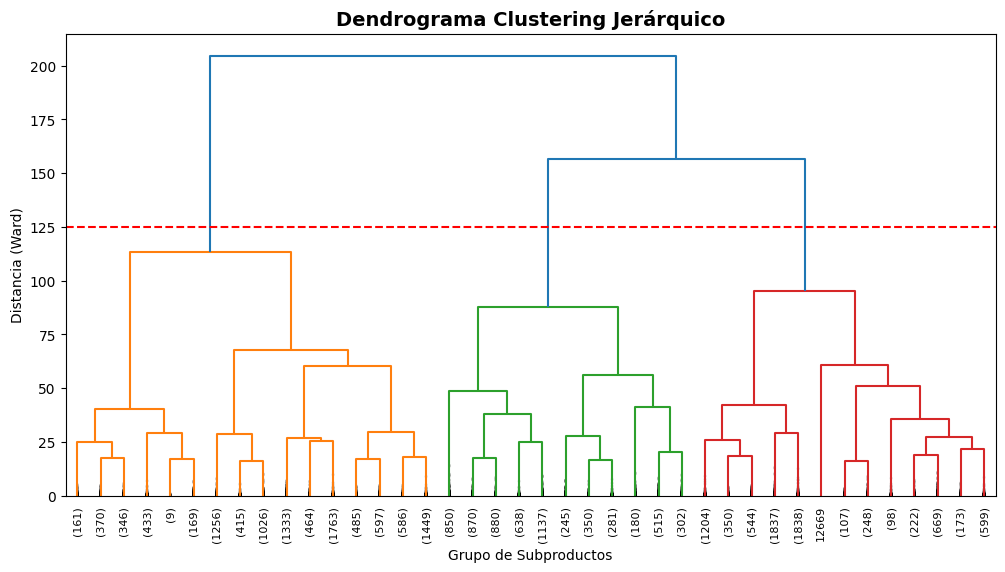

In [ ]:
train_jerarquico_españa = transacciones_españa[columnas_clustering_españa].values
train_jerarquico_españa = np.nan_to_num(train_jerarquico_españa, nan=0.0, posinf=0.0, neginf=0.0)

#Estandarización de los datos
scaler = StandardScaler()
train_jerarquico_españa_estandarizada = scaler.fit_transform(train_jerarquico_españa)

z_españa = linkage(train_jerarquico_españa_estandarizada, method = "ward", metric = "euclidean")

#Visualización clustering jerárquico
plt.figure(figsize = (12, 6))
plt.title("Dendrograma Clustering Jerárquico", fontsize = 14, fontweight = "bold")
plt.xlabel("Grupo de Subproductos")
plt.ylabel("Distancia (Ward)")

#Usamos truncate_mode para agrupar los datos y que le eje sea más legible
dendrogram(z_españa,
           truncate_mode = "lastp",
           p = 40,
           leaf_rotation = 90,
           show_contracted = True)

#Ajustamos la línea roja para fijar el corte
plt.axhline(y = 125, color = "r", linestyle = "--", label  = "Corte sugerido")
plt.show()

Podemos observar que el algoritmo Jerárquico logra identificar 3 clústeres para el dataset de España haciendo un corte a una distancia de 125. Es importante mencionar que la distancia representa que tan flexible es el algoritmo al momemtno de juntar datos.


Tabla de Comparación de Métricas:
 K  Silhouette  Davies-Bouldin  Calinski-Harabasz
 3    0.289455        1.155028        9905.255133
 4    0.278616        1.074267        9311.448357
 5    0.253242        1.019183        8914.102519
 6    0.253470        1.104714        8848.606894
 7    0.222728        1.147019        8433.948987
 8    0.223134        1.007507        8100.578621
 9    0.206614        1.004919        7961.807936


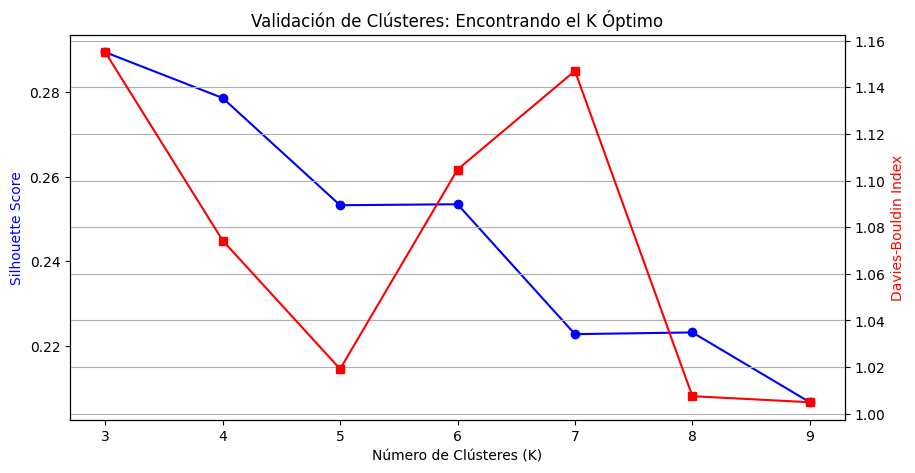

In [ ]:
#Evaluaremos desde k = 3 hasta 10
k_test_jerarquico_españa = range(3, 10)
resultados_metricas_jerarquico_españa = []

for k in k_test_jerarquico_españa:
    #Extraemos las etiquetas para cada K a partir de la matriz "z_españa"
    labels = fcluster(z_españa, k, criterion = "maxclust")

    #Calculamos las métricas
    sil_jerarquico_españa = silhouette_score(train_jerarquico_españa_estandarizada, labels)
    db_jerarquico_españa = davies_bouldin_score(train_jerarquico_españa_estandarizada, labels)
    ch_jerarquico_españa = calinski_harabasz_score(train_jerarquico_españa_estandarizada, labels)

    resultados_metricas_jerarquico_españa.append({
        "K": k,
        "Silhouette": sil_jerarquico_españa,
        "Davies-Bouldin": db_jerarquico_españa,
        "Calinski-Harabasz": ch_jerarquico_españa
    })

#Convertimos a DataFrame para visualizarlo mejor
metricas_jerarquico_españa = pd.DataFrame(resultados_metricas_jerarquico_españa)

#Mostramos los resultados
print("\nTabla de Comparación de Métricas:")
print(metricas_jerarquico_españa.to_string(index = False))

#Visualización de las métricas
fig, ax1 = plt.subplots(figsize = (10, 5))

#Graficamos Silhouette (cuanto más alto, mejor)
ax1.plot(metricas_jerarquico_españa["K"], metricas_jerarquico_españa["Silhouette"], 'b-o', label = "Silhouette (Sube = Mejor)")
ax1.set_xlabel("Número de Clústeres (K)")
ax1.set_ylabel("Silhouette Score", color = "b")

#Graficamos Davies-Bouldin en el mismo eje (cuanto más bajo, mejor)
ax2 = ax1.twinx()
ax2.plot(metricas_jerarquico_españa["K"], metricas_jerarquico_españa["Davies-Bouldin"], "r-s", label = "Davies-Bouldin (Baja = Mejor)")
ax2.set_ylabel("Davies-Bouldin Index", color = "r")

plt.title("Validación de Clústeres: Encontrando el K Óptimo")
plt.grid(True)
plt.show()

Las métricas del algoritmo Jerárquico confirman que el número óptimo de clústeres (k) es 3 ya que presenta el mayor de Silueta (que tan bien definidos están los grupos) e índice de Calinski (densidad de los grupos, más es mejor)

#### K-MEANS

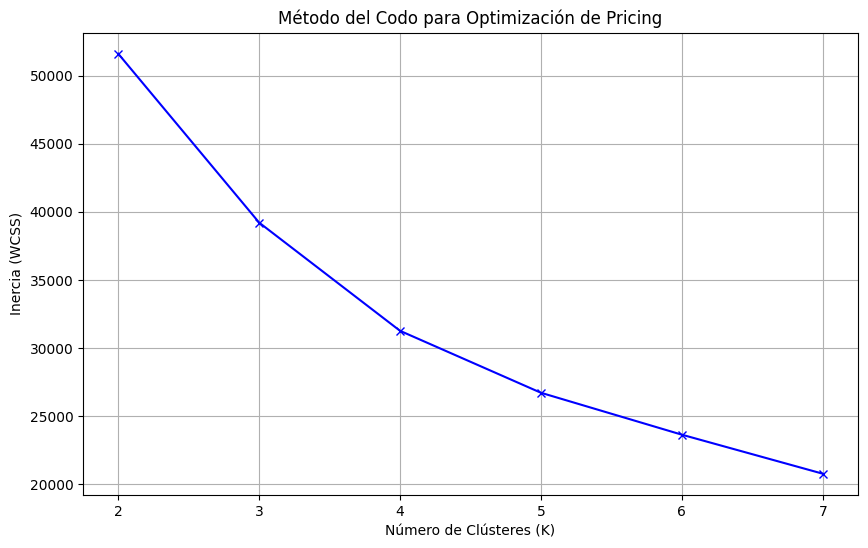

In [18]:
#Aplicaremos el metodo del codo para identificar el k óptimo
train_kmeans_españa = transacciones_españa[columnas_clustering_españa].values
train_kmeans_españa = np.nan_to_num(train_kmeans_españa, nan = 0.0, posinf = 0.0, neginf = 0.0)

#Estandarización de los datos
scaler_kmeans_españa = StandardScaler()
train_kmeans_españa_estandarizada = scaler_kmeans_españa.fit_transform(train_kmeans_españa)

inercia = []
k_test_kmeans_españa = range(2, 8)

for k in k_test_kmeans_españa:
    #Usamos n_init=10 para asegurar estabilidad en los resultados
    kmeans_españa_test = KMeans(n_clusters = k, n_init = 10, init = "k-means++", random_state = 42)
    kmeans_españa_test.fit(train_kmeans_españa_estandarizada)
    inercia.append(kmeans_españa_test.inertia_)

#Visualización del codo
plt.figure(figsize=(10, 6))
plt.plot(k_test_kmeans_españa, inercia, "bx-")
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del Codo para Optimización de Pricing")
plt.grid(True)
plt.show()

Para el caso de K-means aplicamos primero el método del codo para determinar el valor de k. Dicho punto será donde se observe la mayor curvatura. En este caso, podría ser para k = 3 o K = 4.

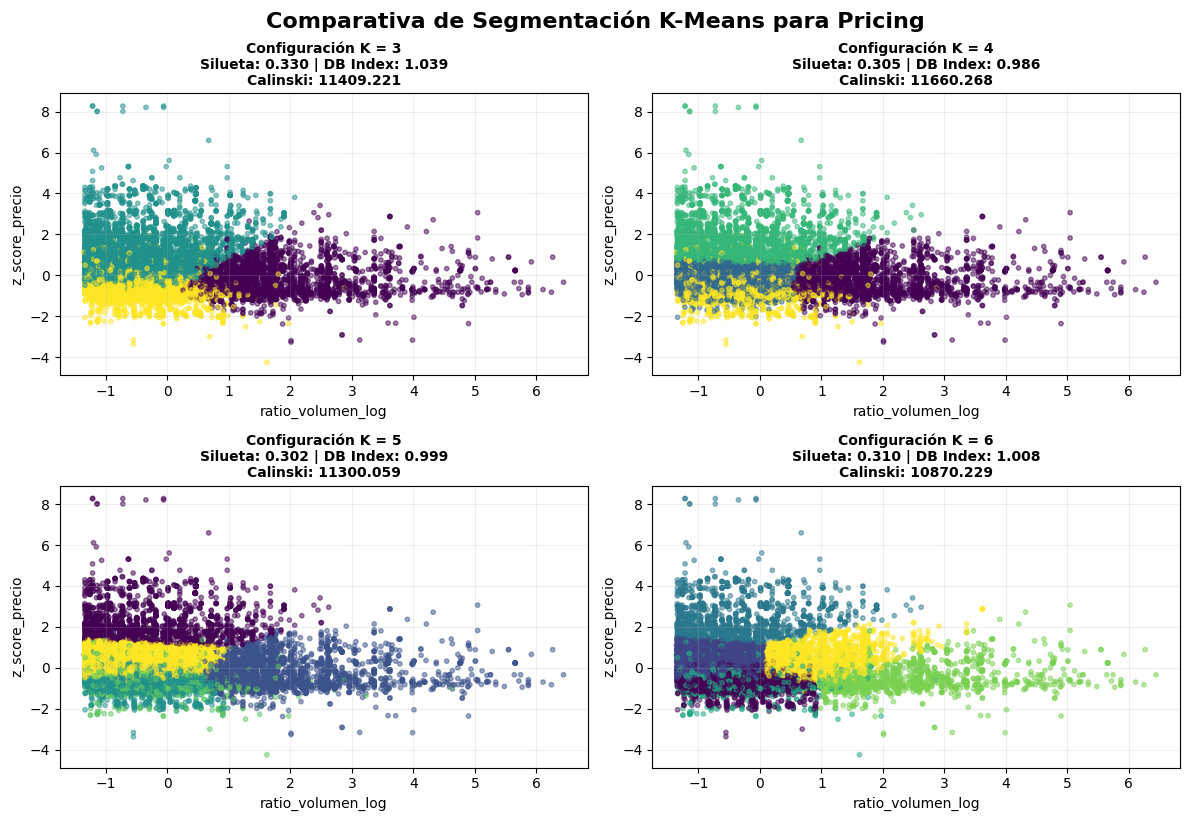

In [19]:
#Evaluaremos k para [3, 4, 5, 6] para tener más comparaciones
k_acotado_kmeans_españa = [3, 4, 5, 6]
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

#Variables para los ejes del gráfico
eje_x = "ratio_volumen_log"
eje_y = "z_score_precio"

idx_x = columnas_clustering_españa.index(eje_x)
idx_y = columnas_clustering_españa.index(eje_y)

for i, k in enumerate(k_acotado_kmeans_españa):
    #Ejecutamos KMeans
    km = KMeans(n_clusters = k, n_init = 10, init = "k-means++", random_state = 42)
    labels_kmeans = km.fit_predict(train_kmeans_españa_estandarizada)

    #Calculamos las métricas
    sil_kmeans_españa = silhouette_score(train_kmeans_españa_estandarizada, labels_kmeans)
    db_kmeans_españa = davies_bouldin_score(train_kmeans_españa_estandarizada, labels_kmeans)
    ch_kmeans_españa = calinski_harabasz_score(train_kmeans_españa_estandarizada, labels_kmeans)

    #Creamos los gráficos
    scatter = axes[i].scatter(
        train_kmeans_españa_estandarizada[:, idx_x],
        train_kmeans_españa_estandarizada[:, idx_y],
        c = labels_kmeans, cmap = "viridis", s = 10, alpha = 0.5
    )

    #Formato de títulos
    axes[i].set_title(
        f"Configuración K = {k}\n"
        f"Silueta: {sil_kmeans_españa:.3f} | DB Index: {db_kmeans_españa:.3f}\n"
        f"Calinski: {ch_kmeans_españa:.3f}",
        fontsize = 10, fontweight = "bold"
    )
    axes[i].set_xlabel(columnas_clustering_españa[idx_x])
    axes[i].set_ylabel(columnas_clustering_españa[idx_y])
    axes[i].grid(True, alpha = 0.2)

plt.tight_layout()
plt.suptitle("Comparativa de Segmentación K-Means para Pricing", fontsize = 16, y = 1.02, fontweight = "bold")
plt.show()

K-means también obtiene sus mejores métricas para k = 3 y logra distinguir de buena forma los grupos.

#### DBSCAN

Número estimado de clústeres: 3
Número estimado de puntos de ruido (Outliers): 788
Métricas DBSCAN:
Silueta: 0.406
DB Index: 1.453
Calinski: 481.679


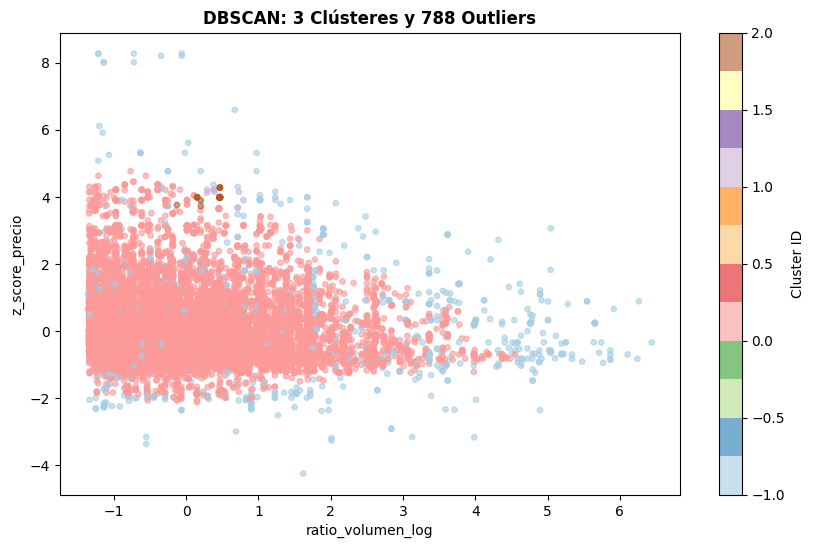

In [29]:
train_dbscan_españa = transacciones_españa[columnas_clustering_españa].values
train_dbscan_españa = np.nan_to_num(train_dbscan_españa, nan = 0.0, posinf = 0.0, neginf = 0.0)

#Estandarización de los datos
scaler_dbscan_españa = StandardScaler()
train_dbscan_españa_estandarizada = scaler_dbscan_españa.fit_transform(train_dbscan_españa)

dbscan_españa = DBSCAN(eps = 0.42, min_samples = 26)
labels_dbscan_españa = dbscan_españa.fit_predict(train_dbscan_españa_estandarizada)

#Análisis de resultados iniciales
n_clusters_ = len(set(labels_dbscan_españa)) - (1 if -1 in labels_dbscan_españa else 0)
n_noise_ = list(labels_dbscan_españa).count(-1)

print(f"Número estimado de clústeres: {n_clusters_}")
print(f"Número estimado de puntos de ruido (Outliers): {n_noise_}")

#Calculamos las métricas (Solo si hay más de 1 clúster y no todo es ruido)
if n_clusters_ > 1:
    sil_dbscan_españa = silhouette_score(train_dbscan_españa_estandarizada, labels_dbscan_españa)
    db_dbscan_españa = davies_bouldin_score(train_dbscan_españa_estandarizada, labels_dbscan_españa)
    ch_dbscan_españa = calinski_harabasz_score(train_dbscan_españa_estandarizada, labels_dbscan_españa)

    print(f"Métricas DBSCAN:")
    print(f"Silueta: {sil_dbscan_españa:.3f}")
    print(f"DB Index: {db_dbscan_españa:.3f}")
    print(f"Calinski: {ch_dbscan_españa:.3f}")
else:
    print("DBSCAN no encontró suficientes clústeres.")

plt.figure(figsize = (10, 6))
# Graficamos los puntos. El color representará el clúster (el -1 suele ser morado oscuro o negro)
plt.scatter(train_dbscan_españa_estandarizada[:, idx_x],
            train_dbscan_españa_estandarizada[:, idx_y],
            c = labels_dbscan_españa, cmap = "Paired", s = 15, alpha = 0.6)

plt.title(f"DBSCAN: {n_clusters_} Clústeres y {n_noise_} Outliers", fontweight = "bold")
plt.xlabel(eje_x)
plt.ylabel(eje_y)
plt.colorbar(label = "Cluster ID")
plt.show()

DBSCAN logra identificar 3 grupos pero tiene más problemas para poder separarlos dado que funciona de menera distinta. A diferencia de otros algormitmos que son particionales, DBSCAN se basa en densidades.

#### EXPECTATION MAXIMIZATION (EM)

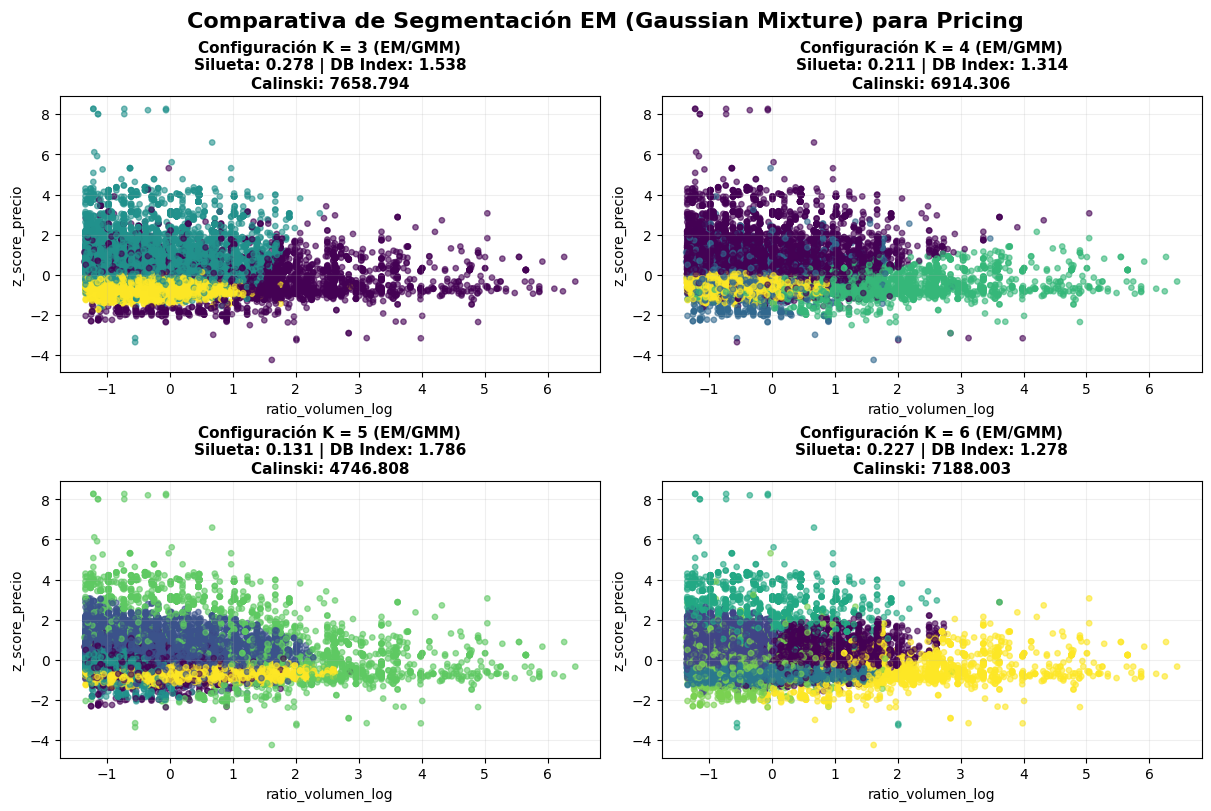

In [30]:
train_gmm_españa = transacciones_españa[columnas_clustering_españa].values
train_gmm_españa = np.nan_to_num(train_gmm_españa, nan = 0.0, posinf = 0.0, neginf = 0.0)

#Estandarización de los datos
scaler_gmm_españa = StandardScaler()
train_gmm_españa_estandarizada = scaler_gmm_españa.fit_transform(train_gmm_españa)

k_acotado_gmm_españa = [3, 4, 5, 6]
fig, axes = plt.subplots(2, 2, figsize = (12, 8), constrained_layout = True)
axes = axes.flatten()

#Variables para los ejes del gráfico
eje_x = "ratio_volumen_log"
eje_y = "z_score_precio"

idx_x = columnas_clustering_españa.index(eje_x)
idx_y = columnas_clustering_españa.index(eje_y)

for i, k in enumerate(k_acotado_gmm_españa):
  gmm_españa = GaussianMixture(n_components = k, n_init = 10, max_iter = 300, random_state = 42)
  labels_gmm = gmm_españa.fit_predict(train_gmm_españa_estandarizada)

  sil_gmm_españa = silhouette_score(train_gmm_españa_estandarizada, labels_gmm)
  db_gmm_españa = davies_bouldin_score(train_gmm_españa_estandarizada, labels_gmm)
  ch_gmm_españa = calinski_harabasz_score(train_gmm_españa_estandarizada, labels_gmm)

  axes[i].scatter(
        train_gmm_españa_estandarizada[:, idx_x],
        train_gmm_españa_estandarizada[:, idx_y],
        c = labels_gmm, cmap = "viridis", s = 15, alpha = 0.6
    )

  #Formato de títulos
  axes[i].set_title(
        f"Configuración K = {k} (EM/GMM)\n"
        f"Silueta: {sil_gmm_españa:.3f} | DB Index: {db_gmm_españa:.3f}\n"
        f"Calinski: {ch_gmm_españa:.3f}", fontsize = 11, fontweight = "bold"
    )

  axes[i].set_xlabel(columnas_clustering_españa[idx_x])
  axes[i].set_ylabel(columnas_clustering_españa[idx_y])
  axes[i].grid(True, alpha = 0.2)

plt.suptitle("Comparativa de Segmentación EM (Gaussian Mixture) para Pricing", fontsize = 16, fontweight = "bold")
plt.show()

El algoritmo Expectation-Maximization (EM) también obtiene sus mejores métricas para k = 3. Sin embargo, a diferencia de K-means, los gupos identificados se solapan entre ellos (si bien el gurpo morado es el que predomina, los otros dos grupos están por sobre dicho grupo).

### CLUSTERING PORTUGAL

#### JERÁRQUICO (DENDOGRAMA)

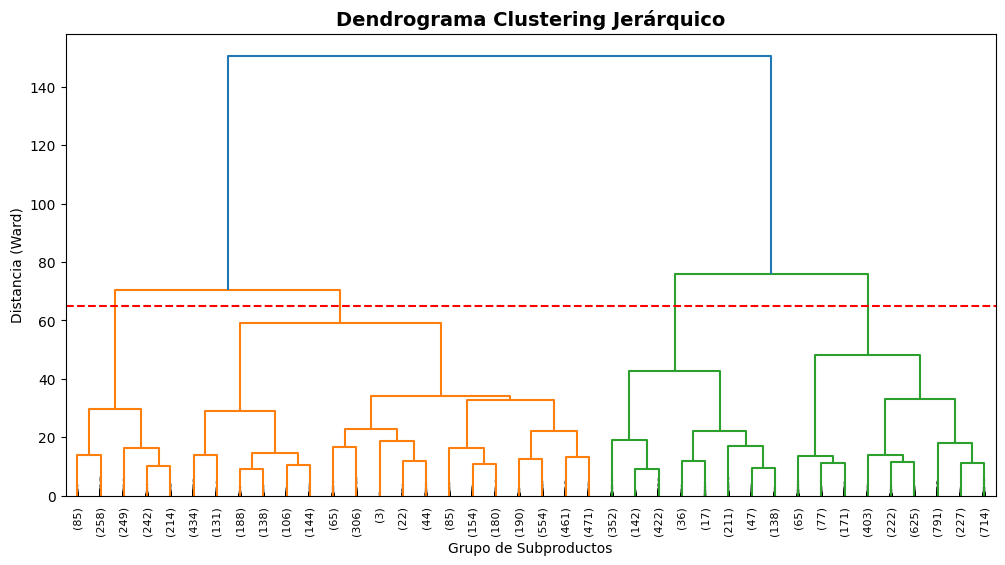

In [ ]:
train_jerarquico_portugal = transacciones_portugal[columnas_clustering_portugal].values
train_jerarquico_portugal = np.nan_to_num(train_jerarquico_portugal, nan = 0.0, posinf = 0.0, neginf = 0.0)

#Estandarización de los datos
scaler_portugal = StandardScaler()
train_jerarquico_portugal_estandarizada = scaler_portugal.fit_transform(train_jerarquico_portugal)

z_portugal = linkage(train_jerarquico_portugal_estandarizada, method = "ward", metric = "euclidean")

#Visualización clustering jerárquico
plt.figure(figsize = (12, 6))
plt.title("Dendrograma Clustering Jerárquico", fontsize = 14, fontweight = "bold")
plt.xlabel("Grupo de Subproductos")
plt.ylabel("Distancia (Ward)")

#Usamos truncate_mode para agrupar los datos y que le eje sea más legible
dendrogram(z_portugal,
           truncate_mode = "lastp",
           p = 40,
           leaf_rotation = 90,
           show_contracted = True)

# Ajustamos la línea roja para fijar el corte
plt.axhline(y = 65, color = "r", linestyle = "--", label = "Corte sugerido")
plt.show()

Para el caso del dataset de Portugal, el algoritmo Jerárquico identifica 2 segemntos. Sin embargo, el corte se recomienda hacerlo un poco más abajo con la finalidad de obtener 4 grupos. Esto se debe a que al tener solo 2 grpos, otros semgentos más de nicho pueden quedar diluidos en segmentos más grandes.


Tabla de Comparación de Métricas:
 K  Silhouette  Davies-Bouldin  Calinski-Harabasz
 3    0.346566        0.993986        4798.005392
 4    0.324843        1.065963        4573.974776
 5    0.316916        1.062364        4474.395898
 6    0.329094        0.984788        4321.421014
 7    0.316014        0.976906        4215.581257
 8    0.307916        1.095015        4026.154905
 9    0.272524        1.100383        3918.344972


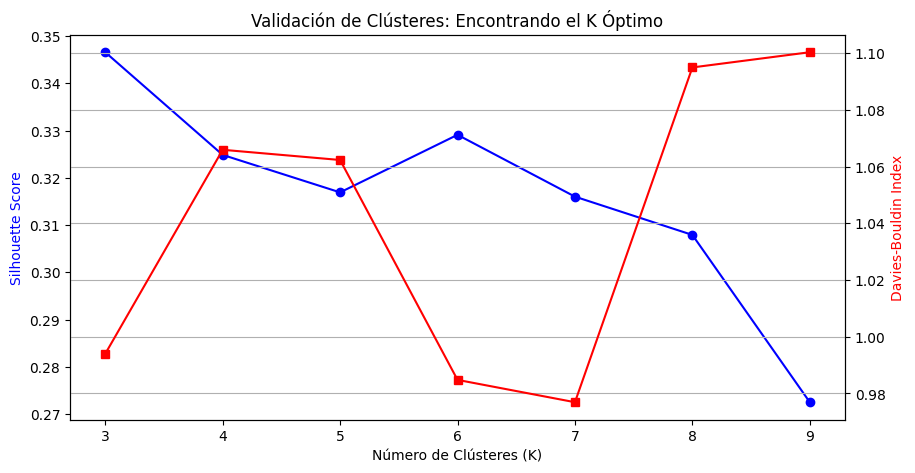

In [ ]:
#Evaluaremos desde 3 hasta 10
k_test_jerarquico_portugal = range(3, 10)
resultados_metricas_jerarquico_portugal = []

for k in k_test_jerarquico_portugal:
    #Extraemos las etiquetas para cada K a partir de la matriz "z_portugal"
    labels_portugal = fcluster(z_portugal, k, criterion='maxclust')

    #Calculamos las métricas
    sil_jerarquico_portugal = silhouette_score(train_jerarquico_portugal_estandarizada, labels_portugal)
    db_jerarquico_portugal = davies_bouldin_score(train_jerarquico_portugal_estandarizada, labels_portugal)
    ch_jerarquico_portugal = calinski_harabasz_score(train_jerarquico_portugal_estandarizada, labels_portugal)

    resultados_metricas_jerarquico_portugal.append({
        "K": k,
        "Silhouette": sil_jerarquico_portugal,
        "Davies-Bouldin": db_jerarquico_portugal,
        "Calinski-Harabasz": ch_jerarquico_portugal
    })

#Convertimos a DataFrame para visualizarlo mejor
metricas_jerarquico_portugal = pd.DataFrame(resultados_metricas_jerarquico_portugal)

#Mostramos los resultados
print("\nTabla de Comparación de Métricas:")
print(metricas_jerarquico_portugal.to_string(index = False))

#Visualización de las métricas
fig, ax1 = plt.subplots(figsize = (10, 5))

#Graficamos Silhouette (cuanto más alto, mejor)
ax1.plot(metricas_jerarquico_portugal["K"], metricas_jerarquico_portugal["Silhouette"], "b-o", label = "Silhouette (Sube = Mejor)")
ax1.set_xlabel("Número de Clústeres (K)")
ax1.set_ylabel("Silhouette Score", color = "b")

#Graficamos Davies-Bouldin en el mismo eje (cuanto más bajo, mejor)
ax2 = ax1.twinx()
ax2.plot(metricas_jerarquico_portugal["K"], metricas_jerarquico_portugal["Davies-Bouldin"], "r-s", label = "Davies-Bouldin (Baja = Mejor)")
ax2.set_ylabel("Davies-Bouldin Index", color = "r")

plt.title("Validación de Clústeres: Encontrando el K Óptimo")
plt.grid(True)
plt.show()

Al analizar las métricas del algormito, se observa que los mejores valores se obtienen al utilizar k = 3 pero no se descarta k = 4 ya que presenta métricas similares.

#### K-MEANS

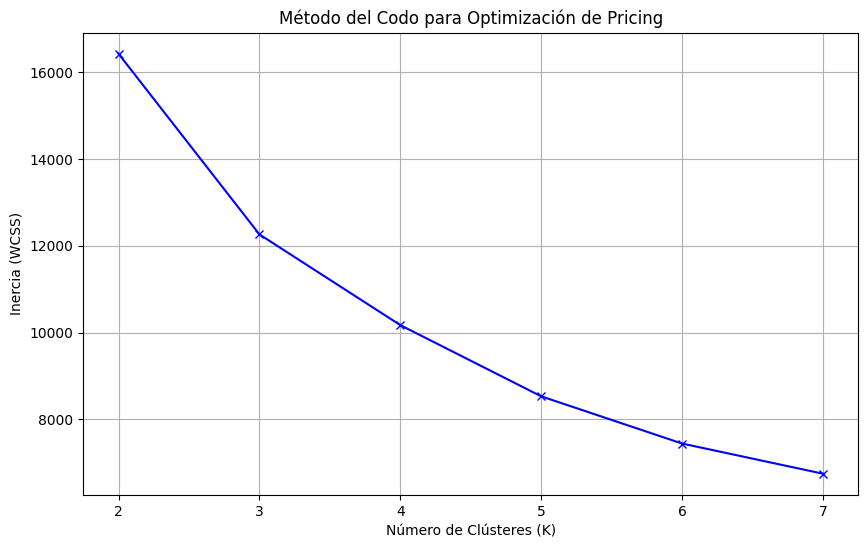

In [20]:
train_kmeans_portugal = transacciones_portugal[columnas_clustering_portugal].values
train_kmeans_portugal = np.nan_to_num(train_kmeans_portugal, nan = 0.0, posinf = 0.0, neginf = 0.0)

#Estandarización de los datos
scaler_kmeans_portugal = StandardScaler()
train_kmeans_portugal_estandarizada = scaler_kmeans_portugal.fit_transform(train_kmeans_portugal)

inercia = []
k_test_kmeans_portugal = range(2, 8)

for k in k_test_kmeans_portugal:
    #Usamos n_init=10 para asegurar estabilidad en los resultados
    kmeans_portugal_test = KMeans(n_clusters = k, n_init = 10, init = "k-means++", random_state = 42)
    kmeans_portugal_test.fit(train_kmeans_portugal_estandarizada)
    inercia.append(kmeans_portugal_test.inertia_)

#Visualización del codp
plt.figure(figsize = (10, 6))
plt.plot(k_test_kmeans_portugal, inercia, "bx-")
plt.xlabel("Número de Clústeres (K)")
plt.ylabel("Inercia (WCSS)")
plt.title("Método del Codo para Optimización de Pricing")
plt.grid(True)
plt.show()

Aplicando el método del codo podemos observar que es recomendable k = 3 o k = 4.

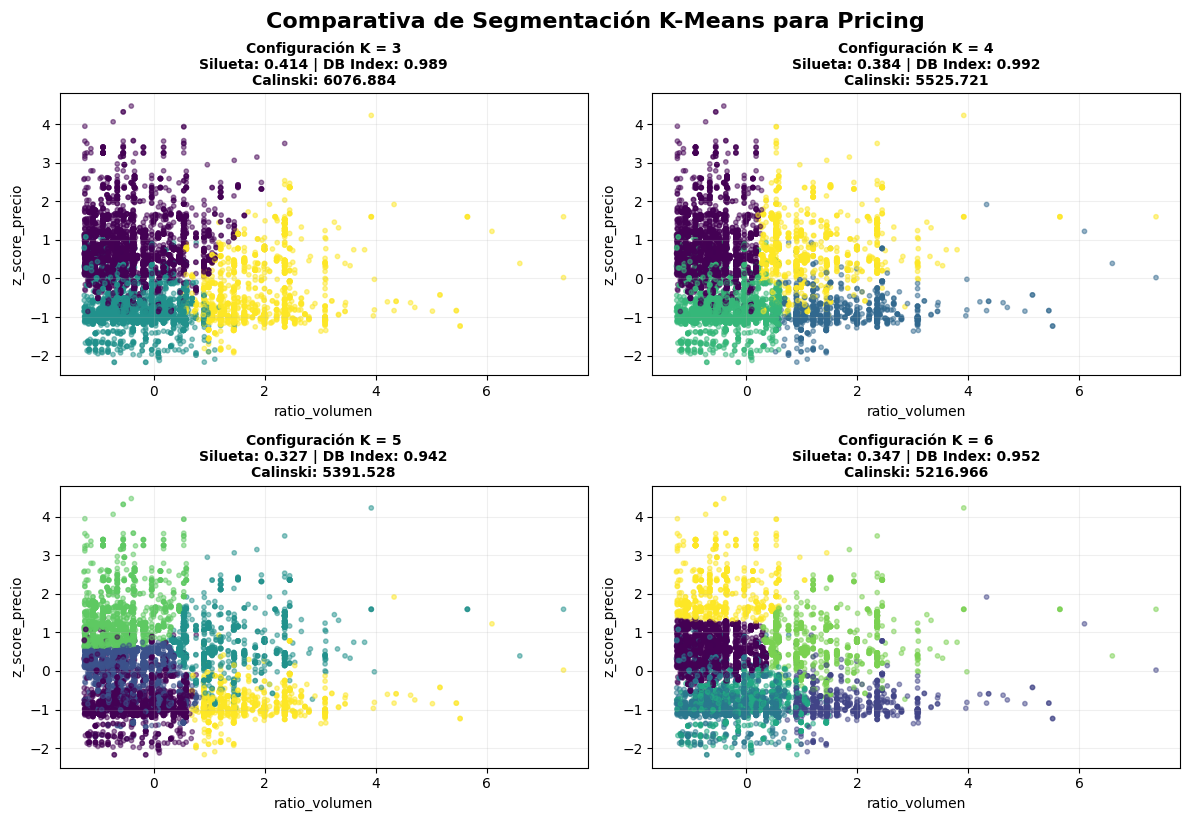

In [21]:
k_acotado_kmeans_portugal = [3, 4, 5, 6]
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

#Variables para los ejes del gráfico
eje_x = "ratio_volumen"
eje_y = "z_score_precio"

idx_x = columnas_clustering_portugal.index(eje_x)
idx_y = columnas_clustering_portugal.index(eje_y)

for i, k in enumerate(k_acotado_kmeans_portugal):
    #Ejecutar KMeans
    km = KMeans(n_clusters = k, n_init = 10, init = "k-means++", random_state = 42)
    labels_kmeans_portugal = km.fit_predict(train_kmeans_portugal_estandarizada)

    #Calculamos las métricas
    sil_kmeans_portugal = silhouette_score(train_kmeans_portugal_estandarizada, labels_kmeans_portugal)
    db_kmeans_portugal = davies_bouldin_score(train_kmeans_portugal_estandarizada, labels_kmeans_portugal)
    ch_kmeans_portugal = calinski_harabasz_score(train_kmeans_portugal_estandarizada, labels_kmeans_portugal)
    iner_portugal = km.inertia_

    #Creamos los gráficos
    scatter = axes[i].scatter(
        train_kmeans_portugal_estandarizada[:, idx_x],
        train_kmeans_portugal_estandarizada[:, idx_y],
        c = labels_kmeans_portugal, cmap = "viridis", s = 10, alpha = 0.5
    )

    #Formato de títulos
    axes[i].set_title(
        f"Configuración K = {k}\n"
        f"Silueta: {sil_kmeans_portugal:.3f} | DB Index: {db_kmeans_portugal:.3f}\n"
        f"Calinski: {ch_kmeans_portugal:.3f}",
        fontsize = 10, fontweight = "bold"
    )
    axes[i].set_xlabel(columnas_clustering_portugal[idx_x])
    axes[i].set_ylabel(columnas_clustering_portugal[idx_y])
    axes[i].grid(True, alpha = 0.2)

plt.tight_layout()
plt.suptitle("Comparativa de Segmentación K-Means para Pricing", fontsize = 16, y = 1.02, fontweight = "bold")
plt.show()

K-means logra identificar de buena forma distintos grupos para k = 3 y K = 4. Si bien las métricas del primero son un poco mejores, es recomendable considerar k = 4 para que ese grupo no quede diluido en otro más grande.

#### DBSCAN

Número estimado de clústeres: 3
Número estimado de puntos de ruido (Outliers): 1244
Métricas DBSCAN:
Silueta: 0.207
DB Index: 2.316
Calinski: 295.744


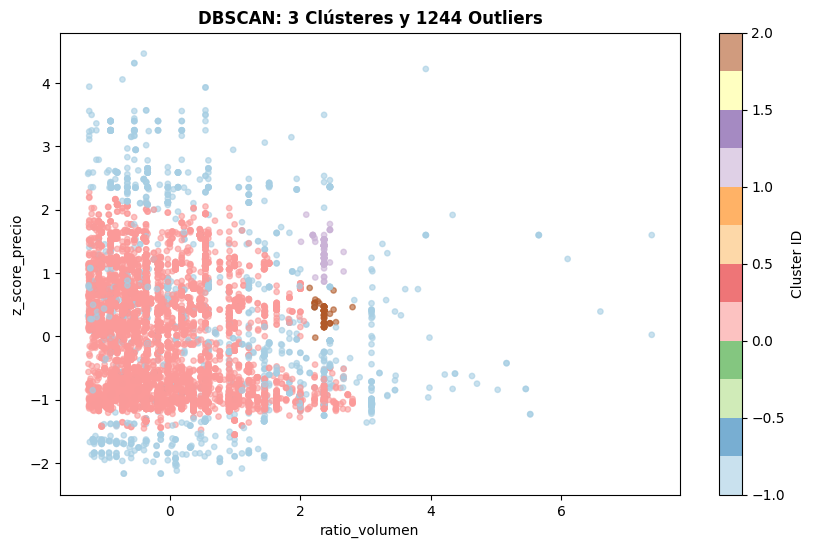

In [34]:
train_dbscan_portugal = transacciones_portugal[columnas_clustering_portugal].values
train_dbscan_portugal = np.nan_to_num(train_dbscan_portugal, nan = 0.0, posinf = 0.0, neginf = 0.0)

#Estandarización de los datos
scaler_dbscan_portugal = StandardScaler()
train_dbscan_portugal_estandarizada = scaler_dbscan_portugal.fit_transform(train_dbscan_portugal)

dbscan_portugal = DBSCAN(eps = 0.35, min_samples = 40)
labels_dbscan_portugal = dbscan_portugal.fit_predict(train_dbscan_portugal_estandarizada)

#Análisis de resultados iniciales
n_clusters_ = len(set(labels_dbscan_portugal)) - (1 if -1 in labels_dbscan_portugal else 0)
n_noise_ = list(labels_dbscan_portugal).count(-1)

print(f"Número estimado de clústeres: {n_clusters_}")
print(f"Número estimado de puntos de ruido (Outliers): {n_noise_}")

#Calculamos las métricas
if n_clusters_ > 1:
    sil_dbscan_portugal = silhouette_score(train_dbscan_portugal_estandarizada, labels_dbscan_portugal)
    db_dbscan_portugal = davies_bouldin_score(train_dbscan_portugal_estandarizada, labels_dbscan_portugal)
    ch_dbscan_portugal = calinski_harabasz_score(train_dbscan_portugal_estandarizada, labels_dbscan_portugal)

    print(f"Métricas DBSCAN:")
    print(f"Silueta: {sil_dbscan_portugal:.3f}")
    print(f"DB Index: {db_dbscan_portugal:.3f}")
    print(f"Calinski: {ch_dbscan_portugal:.3f}")
else:
    print("DBSCAN no encontró suficientes clústeres.")

plt.figure(figsize = (10, 6))
#Graficamos los puntos. El color representará el clúster (el -1 suele ser morado oscuro o negro)
plt.scatter(train_dbscan_portugal_estandarizada[:, idx_x],
            train_dbscan_portugal_estandarizada[:, idx_y],
            c = labels_dbscan_portugal, cmap = "Paired", s = 15, alpha = 0.6)

plt.title(f"DBSCAN: {n_clusters_} Clústeres y {n_noise_} Outliers", fontweight = "bold")
plt.xlabel(eje_x)
plt.ylabel(eje_y)
plt.colorbar(label = "Cluster ID")
plt.show()

DBSCAN identifica 3 grupos distintos pero al igual que en el dataset de España, no logra separar de buena manera los grupos.

#### EXPECTATION MAXIMITATION (EM)

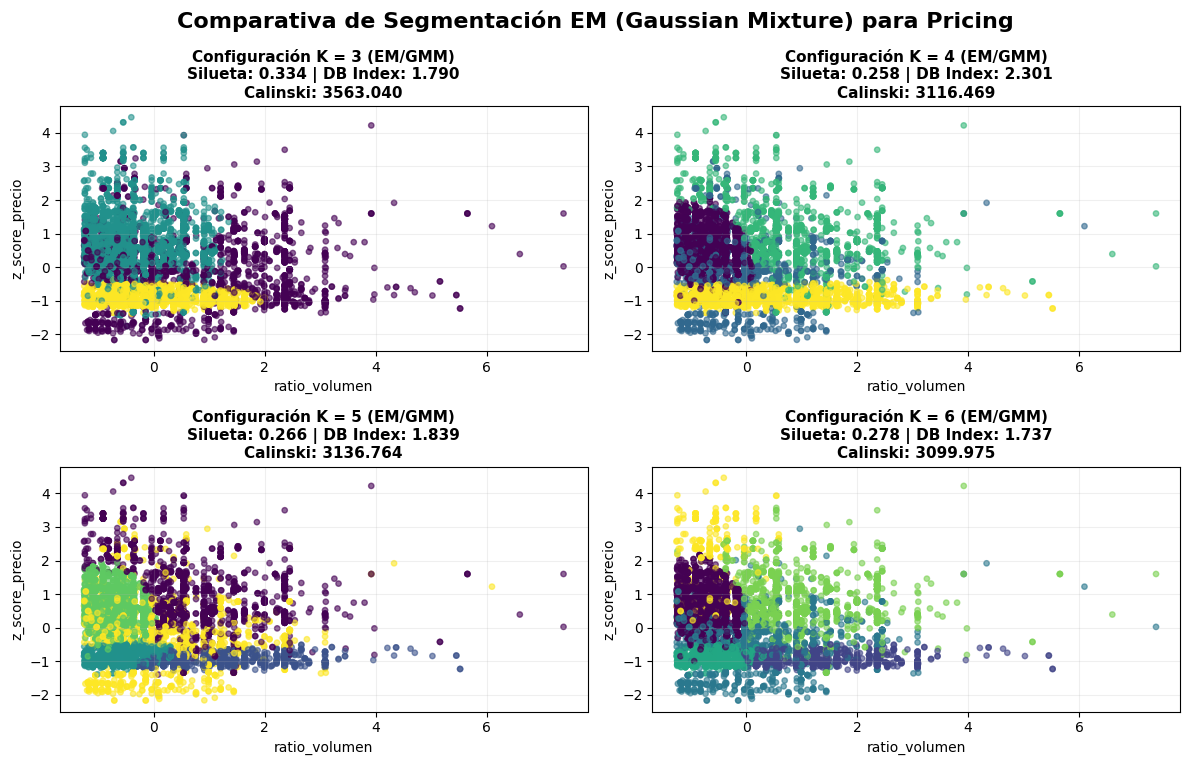

In [ ]:
train_gmm_portugal = transacciones_portugal[columnas_clustering_portugal].values
train_gmm_portugal = np.nan_to_num(train_gmm_portugal, nan = 0.0, posinf = 0.0, neginf = 0.0)

#Estandarización de los datos
scaler_gmm_portugal = StandardScaler()
train_gmm_portugal_estandarizada = scaler_gmm_portugal.fit_transform(train_gmm_portugal)

k_acotado_gmm_portugal = [3, 4, 5, 6]
fig, axes = plt.subplots(2, 2, figsize = (12, 8))
axes = axes.flatten()

#Variables para los ejes del gráfico
eje_x = "ratio_volumen"
eje_y = "z_score_precio"

idx_x = columnas_clustering_portugal.index(eje_x)
idx_y = columnas_clustering_portugal.index(eje_y)

for i, k in enumerate(k_acotado_gmm_portugal):
  gmm = GaussianMixture(n_components = k, n_init = 10, max_iter = 300, random_state = 42)
  labels_gmm = gmm.fit_predict(train_gmm_portugal_estandarizada)

  sil_gmm_portugal = silhouette_score(train_gmm_portugal_estandarizada, labels_gmm)
  db_gmm_portugal = davies_bouldin_score(train_gmm_portugal_estandarizada, labels_gmm)
  ch_gmm_portugal = calinski_harabasz_score(train_gmm_portugal_estandarizada, labels_gmm)

  axes[i].scatter(
        train_gmm_portugal_estandarizada[:, idx_x],
        train_gmm_portugal_estandarizada[:, idx_y],
        c = labels_gmm, cmap = "viridis", s = 15, alpha = 0.6
    )

  #Formato de títulos
  axes[i].set_title(
        f"Configuración K = {k} (EM/GMM)\n"
        f"Silueta: {sil_gmm_portugal:.3f} | DB Index: {db_gmm_portugal:.3f}\n"
        f"Calinski: {ch_gmm_portugal:.3f}", fontsize = 11, fontweight = "bold"
    )

  axes[i].set_xlabel(columnas_clustering_portugal[idx_x])
  axes[i].set_ylabel(columnas_clustering_portugal[idx_y])
  axes[i].grid(True, alpha = 0.2)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("Comparativa de Segmentación EM (Gaussian Mixture) para Pricing", fontsize = 16, fontweight = "bold")
plt.show()

El algoritmo Expectation-Maximization (EM) logra sus mejores métricas para k = 3 pero se puede observar que los grupos se solapan con principal. Lo mismo ocurre para mayores valores de k.

## V. MODELOS MACHINE LEARNING (ML)

In [22]:
# Importación de librerias generales para modelos ML
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from scipy.stats import randint as sp_randint
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

Luego de revisar y analiar los resultados obtenidos con cada algoritmo de clustering para cada dataset, se opta por usar k = 3 para el dataset de España y k = 4 para el de Portugal.

In [23]:
kmeans_optimo_españa = KMeans(n_clusters = 3, n_init = 10, init = "k-means++", random_state = 42)
kmeans_optimo_españa.fit(train_kmeans_españa_estandarizada)

predecir_cluster_españa = proyecto_españa_ingenieria[columnas_clustering_españa].values
predecir_cluster_españa = np.nan_to_num(predecir_cluster_españa, nan=0.0, posinf=0.0, neginf=0.0)

predecir_cluster_españa_estandarizada = scaler_kmeans_españa.transform(predecir_cluster_españa)
proyecto_españa_ingenieria["cluster"] = np.where(proyecto_españa_ingenieria["mayorista"] == 1, -1, kmeans_optimo_españa.predict(predecir_cluster_españa_estandarizada))

le_prod = LabelEncoder()
proyecto_españa_ingenieria["subfamilia_encoded"] = le_prod.fit_transform(proyecto_españa_ingenieria["Subfamilia"])

zona_freq = proyecto_españa_ingenieria["Región"].value_counts(normalize = True)
proyecto_españa_ingenieria["zona_encoded"] = proyecto_españa_ingenieria["Región"].map(zona_freq)

proyecto_españa.head()

,Cliente,Región,Mes,Año,Subfamilia,Familia,vta_tarifa,cantidad,Peso,vta_bruta,...,dsco_permanente_uni,dsco_temporal_uni,dsco_logistico_uni,dsco_pronto_pago_uni,vta_bruta_uni,vta_tarifa_uni,vta_facturada_uni,vta_facturada2_uni,vta_neta_uni,pais_id
20436,3003977,ES /13 Ciudad Real,1,2025,3.10.,3,8.0,20,320.0,8.0,...,-15.500000,0.000000,0.0,0.000000,25.0,25.0,9.500000,9.500000,9.500000,1
20437,3003977,ES /13 Ciudad Real,2,2025,3.10.,3,16.0,40,640.0,16.0,...,-15.500000,0.000000,0.0,0.000000,25.0,25.0,9.500000,9.500000,9.500000,1
20438,3005285,ES /33 Asturias,1,2025,3.10.,3,48.0,120,1920.0,48.0,...,-17.625000,-0.145833,0.0,-0.161458,25.0,25.0,7.229167,7.067708,7.067708,1
20439,3005285,ES /33 Asturias,2,2025,3.10.,3,24.0,60,960.0,24.0,...,-17.645833,0.000000,0.0,-0.145833,25.0,25.0,7.354167,7.208333,7.208333,1
20440,3005285,ES /33 Asturias,3,2025,3.10.,3,24.0,60,960.0,24.0,...,-17.500000,0.000000,0.0,-0.145833,25.0,25.0,7.500000,7.354167,7.354167,1


In [24]:
kmeans_optimo_portugal = KMeans(n_clusters = 4, n_init = 10, init = "k-means++", random_state = 42)
kmeans_optimo_portugal.fit(train_kmeans_portugal_estandarizada)

predecir_cluster_portugal = proyecto_portugal_ingenieria[columnas_clustering_portugal].values
predecir_cluster_portugal = np.nan_to_num(predecir_cluster_portugal, nan = 0.0, posinf = 0.0, neginf = 0.0)

predecir_cluster_portugal_estandarizada = scaler_kmeans_portugal.transform(predecir_cluster_portugal)
proyecto_portugal_ingenieria["cluster"] = np.where(proyecto_portugal_ingenieria["mayorista"] == 1, -1, kmeans_optimo_portugal.predict(predecir_cluster_portugal_estandarizada))

le_prod = LabelEncoder()
proyecto_portugal_ingenieria["subfamilia_encoded"] = le_prod.fit_transform(proyecto_portugal_ingenieria["Subfamilia"])

zona_freq = proyecto_portugal_ingenieria["Región"].value_counts(normalize = True)
proyecto_portugal_ingenieria["zona_encoded"] = proyecto_portugal_ingenieria["Región"].map(zona_freq)

proyecto_portugal.head()

,Cliente,Región,Mes,Año,Subfamilia,Familia,vta_tarifa,cantidad,Peso,vta_bruta,...,dsco_permanente_uni,dsco_temporal_uni,dsco_logistico_uni,dsco_pronto_pago_uni,vta_bruta_uni,vta_tarifa_uni,vta_facturada_uni,vta_facturada2_uni,vta_neta_uni,pais_id
20874,3095530,PT /074 Lisboa,1,2025,3.10.,3,16.0,40,640.0,11.2,...,0.0,-0.875000,0.0,0.0,17.500000,25.000000,16.625000,16.625000,16.625000,2
20875,3095530,PT /074 Lisboa,3,2025,3.10.,3,24.0,60,960.0,16.8,...,0.0,-0.875000,0.0,0.0,17.500000,25.000000,16.625000,16.625000,16.625000,2
21331,3095530,PT /074 Lisboa,1,2025,3.10.,3,5.0,10,170.0,2.6,...,0.0,-0.764706,0.0,0.0,15.294118,29.411765,14.529412,14.529412,14.529412,2
21332,3095530,PT /074 Lisboa,3,2025,3.10.,3,15.0,30,510.0,7.8,...,0.0,-0.764706,0.0,0.0,15.294118,29.411765,14.529412,14.529412,14.529412,2
21333,3095530,PT /074 Lisboa,6,2025,3.10.,3,15.6,30,510.0,7.8,...,0.0,0.000000,0.0,0.0,15.294118,30.588235,15.294118,15.294118,15.294118,2


### ML ESPAÑA

#### DECISION TREE

DECISION TREE BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_dt = {}
modelo_metricas_españa_dt = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    #Configuración del Árbol de Decisión
    dt_base_españa = DecisionTreeRegressor(
        random_state = 42
    )

    dt_base_españa.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_españa = dt_base_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_dt[cluster] = dt_base_españa

    #Guardamos las métricas
    modelo_metricas_españa_dt.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_dt)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", 'R2': "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Clúster 3: Datos insuficientes.
Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,789386.7951,888.4744,296.0900,0.0966
0,97016,820.1945,28.6390,17.8077,0.4404
1,199151,518.3485,22.7673,13.1861,0.2720
2,202845,656.2070,25.6165,14.1731,0.2544



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.29


DECISION TREE HIPERPARÁMETROS

In [ ]:
#Rangos hiperparámetros
param_dist_mayorista_españa = {
    "max_depth": [28, 30, 32],
    "min_samples_leaf": [35, 40, 45],
    "min_samples_split": [2, 3, 4],
    "max_features": [0.5, 0.6],
    "criterion": ["poisson", "squared_error"]
}

param_dist_minorista_españa = {
    "max_depth": [20, 25, 30],
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4],
    "max_features": [0.5, 0.6],
    "criterion": ["poisson", "squared_error"]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa = {}
modelo_metricas_españa = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria['cluster'] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    param_dist_actual_españa = param_dist_mayorista_españa if cluster == -1 else param_dist_minorista_españa
    dt_base_españa = DecisionTreeRegressor(random_state = 42)

    #Configuración del Árbol de Decisión
    dt_hiperparametro_españa = RandomizedSearchCV(
        estimator = dt_base_españa,
        param_distributions = param_dist_actual_españa,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1,
        random_state = 42
    )

    dt_hiperparametro_españa.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_españa = dt_hiperparametro_españa.best_params_

    param_grid_españa = {k: [v] for k, v in best_params_españa.items()}

    grid_search_españa = GridSearchCV(
        estimator = dt_base_españa,
        param_grid = param_grid_españa,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1
    )

    grid_search_españa.fit(x_train_cluster, y_train_cluster)
    dt_hiperparametro_final_españa = grid_search_españa.best_estimator_
    y_pred_cluster_españa = dt_hiperparametro_final_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa[cluster] = dt_hiperparametro_final_españa

    #Guardamos las métricas
    modelo_metricas_españa.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,619044.0203,786.7935,272.6177,0.2915
0,97016,611.8259,24.7351,16.7983,0.5826
1,199151,382.3414,19.5536,12.5663,0.4630
2,202845,485.5100,22.0343,13.7521,0.4484



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.15


In [ ]:
print(modelo_segun_cluster_españa[-1])
print(modelo_segun_cluster_españa[0])
print(modelo_segun_cluster_españa[1])
print(modelo_segun_cluster_españa[2])

DecisionTreeRegressor(max_depth=30, max_features=0.6, min_samples_leaf=35,
                      min_samples_split=4, random_state=42)
DecisionTreeRegressor(criterion='poisson', max_depth=20, max_features=0.6,
                      min_samples_leaf=3, random_state=42)
DecisionTreeRegressor(max_depth=20, max_features=0.6, min_samples_leaf=3,
                      random_state=42)
DecisionTreeRegressor(max_depth=20, max_features=0.6, min_samples_leaf=3,
                      random_state=42)


DECISION TREE ÓPTIMO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_dt = {}
modelo_metricas_españa_dt = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      max_profundidad = 25
      max_caracteristicas = 0.6
      min_hojas = 30
      min_separaciones = 10
      criterio = "poisson"
    else:
      max_profundidad = 12
      max_caracteristicas = 0.6
      min_hojas = 2
      min_separaciones = 5
      criterio = "poisson"

    #Configuración del Árbol de Decisión
    dt_optimo_españa = DecisionTreeRegressor(
        max_depth = max_profundidad,
        max_features = max_caracteristicas,
        min_samples_leaf = min_hojas,
        min_samples_split = min_separaciones,
        criterion = criterio,
        random_state = 42
    )

    dt_optimo_españa.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_españa = dt_optimo_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_dt[cluster] = dt_optimo_españa

    #Guardamos las métricas
    modelo_metricas_españa_dt.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_dt)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,615932.2900,784.8135,267.6773,0.2951
0,97016,534.5087,23.1194,17.0633,0.6353
1,199151,404.4200,20.1102,14.4206,0.4320
2,202845,483.6791,21.9927,15.3312,0.4505



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.17


Se ejecutan 3 variaciones distintas para Árbol de decisión, un modelo básico, un modelo optimizado con hiperparámetros y un último iterando con valores cercanos para ver si se encontraba un mejor resultados. Se obtuvieron resultados razonables para los clústeres minoristas.

#### RANDOM FOREST

RANDOM FOREST BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

# Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_rf = {}
modelo_metricas_españa_rf = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    #Configuración del Random Forest
    rf_base_españa = RandomForestRegressor(
        n_jobs = -1,
        random_state = 42
    )

    rf_base_españa.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_españa = rf_base_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_rf[cluster] = rf_base_españa

    #Guardamos las métricas
    modelo_metricas_españa_rf.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_rf)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,524890.8850,724.4935,238.8357,0.3993
0,97016,478.9492,21.8849,15.3265,0.6732
1,199151,282.6770,16.8130,11.2314,0.6030
2,202845,369.4682,19.2216,12.2381,0.5802



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.44


RANDOM FOREST HIPERPARÁMETROS

In [ ]:
#Rangos hiperparámetros
param_dist_mayorista_españa = {
    "n_estimators": [300, 350],
    "max_depth": [24, 26],
    "min_samples_leaf": [3, 5],
    "min_samples_split": [4, 6],
    "max_features": [0.4, 0.5],
    "criterion": ["poisson"]
}

param_dist_minorista_españa = {
    "n_estimators": [200, 250],
    "max_depth": [10, 13],
    "min_samples_leaf": [3, 5],
    "min_samples_split": [4, 6],
    "max_features": [0.5, 0.6],
    "criterion": ["poisson"]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa = {}
modelo_metricas_españa = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    param_dist_actual_españa = param_dist_mayorista_españa if cluster == -1 else param_dist_minorista_españa
    rf_base_españa = RandomForestRegressor(n_jobs = 1, random_state = 42)

    #Configuración del Random Forest
    rf_hiperparametro_españa = RandomizedSearchCV(
        estimator = rf_base_españa,
        param_distributions = param_dist_actual_españa,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = 1,
        random_state = 42
    )

    rf_hiperparametro_españa.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_españa = rf_hiperparametro_españa.best_params_

    param_grid_españa = {k: [v] for k, v in best_params_españa.items()}

    grid_search_españa = GridSearchCV(
        estimator = rf_base_españa,
        param_grid = param_grid_españa,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = 1
    )

    grid_search_españa.fit(x_train_cluster, y_train_cluster)
    rf_hiperparametro_final_españa = grid_search_españa.best_estimator_
    y_pred_cluster_españa = rf_hiperparametro_final_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa[cluster] = rf_hiperparametro_final_españa

    #Guardamos las métricas
    modelo_metricas_españa.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,526279.5820,725.4513,233.9566,0.3977
0,97016,467.4023,21.6195,16.1503,0.6811
1,199151,355.3261,18.8501,13.8462,0.5010
2,202845,431.2900,20.7675,14.7064,0.5100



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.17


In [ ]:
print(modelo_segun_cluster_españa[-1])
print(modelo_segun_cluster_españa[0])
print(modelo_segun_cluster_españa[1])
print(modelo_segun_cluster_españa[2])

RandomForestRegressor(criterion='poisson', max_depth=26, max_features=0.5,
                      min_samples_leaf=3, min_samples_split=4, n_estimators=350,
                      n_jobs=1, random_state=42)
RandomForestRegressor(criterion='poisson', max_depth=13, max_features=0.6,
                      min_samples_leaf=3, min_samples_split=4, n_estimators=200,
                      n_jobs=1, random_state=42)
RandomForestRegressor(criterion='poisson', max_depth=13, max_features=0.6,
                      min_samples_leaf=3, min_samples_split=4, n_estimators=250,
                      n_jobs=1, random_state=42)
RandomForestRegressor(criterion='poisson', max_depth=13, max_features=0.6,
                      min_samples_leaf=3, min_samples_split=4, n_estimators=250,
                      n_jobs=1, random_state=42)


RANDOM FOREST ÓPTIMO

In [25]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_rf = {}
modelo_metricas_españa_rf = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      n_estimadores = 600
      max_profundidad = 40
      max_caracteristicas = 0.4
      min_hojas = 1
      min_separaciones = 3
      criterio = "poisson"
    else:
      n_estimadores = 350
      max_profundidad = 28
      max_caracteristicas = 0.6
      min_hojas = 1
      min_separaciones = 3
      criterio = "poisson"

    #Configuración del Random Forest
    rf_optimo_españa = RandomForestRegressor(
        n_estimators = n_estimadores,
        max_depth = max_profundidad,
        max_features = max_caracteristicas,
        min_samples_leaf = min_hojas,
        min_samples_split = min_separaciones,
        criterion = criterio,
        n_jobs = -1,
        random_state = 42
    )

    rf_optimo_españa.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_españa = rf_optimo_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_rf[cluster] = rf_optimo_españa

    #Guardamos las métricas
    modelo_metricas_españa_rf.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_rf)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,526436.2427,725.5593,237.0287,0.3975
0,97016,465.3359,21.5716,15.2049,0.6825
1,199151,272.1686,16.4975,11.1003,0.6178
2,202845,358.6686,18.9385,12.1998,0.5925



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.15


AL igual que el algoritmo anterior, se ejecutaron 3 variantes para Random Forest obteniendo mejores metricas para todos los clústeres. Esto se debe principalmente a que Random Forest crea varios árboles independientes y luego promedia los resultados.

#### XGBOOST

XGBOOST BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_xgb = {}
modelo_metricas_españa_xgb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    #Configuración del XGBoost
    xgb_base_españa = XGBRegressor(
        n_jobs = -1,
        random_state = 42
    )

    xgb_base_españa.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_españa = xgb_base_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_xgb[cluster] = xgb_base_españa

    #Guardamos las métricas
    modelo_metricas_españa_xgb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_xgb)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,565779.9375,752.1834,258.2936,0.3525
0,97016,472.2348,21.7310,16.3465,0.6778
1,199151,329.0832,18.1407,13.2577,0.5378
2,202845,434.6335,20.8479,14.6255,0.5062



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.19


XGBOOST HIPERPARÁMETROS

In [ ]:
#Rango hiperparámetros
param_dist_mayorista_españa = {
    "n_estimators": [600, 650],
    "max_depth": [12, 14, 16],
    "learning_rate": [0.05, 0.1, 0.15],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8],
    "tree_method": ["hist"],
    "objective": ["count:poisson"]
}

param_dist_minorista_españa = {
    "n_estimators": [500, 550],
    "max_depth": [6, 8, 10],
    "learning_rate": [0.01, 0.04, 0.07],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8],
    "tree_method": ["hist"],
    "objective": ["count:poisson"]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = 'cantidad'

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa = {}
modelo_metricas_españa = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    param_dist_actual_españa = param_dist_mayorista_españa if cluster == -1 else param_dist_minorista_españa
    xgb_base_españa = XGBRegressor(n_jobs = 1, random_state = 42)

    #Configuración del XGBoost
    xgb_hiperparametro_españa = RandomizedSearchCV(
        estimator = xgb_base_españa,
        param_distributions = param_dist_actual_españa,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = 1,
        random_state = 42
    )

    xgb_hiperparametro_españa.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_españa = xgb_hiperparametro_españa.best_params_

    param_grid_españa = {k: [v] for k, v in best_params_españa.items()}

    grid_search_españa = GridSearchCV(
        estimator = xgb_base_españa,
        param_grid = param_grid_españa,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = 1
    )

    grid_search_españa.fit(x_train_cluster, y_train_cluster)
    xgb_hiperparametro_final_españa = grid_search_españa.best_estimator_
    y_pred_cluster_españa = xgb_hiperparametro_final_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa[cluster] = xgb_hiperparametro_final_españa

    #Guardamos las métricas
    modelo_metricas_españa.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,529541.5000,727.6960,218.5563,0.3940
0,97016,450.7024,21.2298,15.4759,0.6925
1,199151,276.6834,16.6338,11.7009,0.6114
2,202845,390.2866,19.7557,13.3183,0.5566



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 35.88


In [ ]:
print(modelo_segun_cluster_españa[-1])
print(modelo_segun_cluster_españa[0])
print(modelo_segun_cluster_españa[1])
print(modelo_segun_cluster_españa[2])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=12,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=650,
             n_jobs=1, num_parallel_tree=None, ...)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feat

XGBOOST ÓPTIMO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_xgb = {}
modelo_metricas_españa_xgb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      n_estimadores = 650
      max_profundidad = 12
      ratio_aprendizaje = 0.07
      sub_muestra = 0.9
      arbol_muestra = 0.5
      arbol_metodo = "hist"
      objetivo = "count:poisson"
    else:
      n_estimadores = 550
      max_profundidad = 10
      ratio_aprendizaje = 0.07
      sub_muestra = 0.9
      arbol_muestra = 0.7
      arbol_metodo = "hist"
      objetivo = "count:poisson"

    #Configuración del XGBoost
    xgb_optimo_españa = XGBRegressor(
        n_estimators = n_estimadores,
        max_depth = max_profundidad,
        learning_rate = ratio_aprendizaje,
        subsample = sub_muestra,
        objective = objetivo,
        colsample_bytree = arbol_muestra,
        tree_method = arbol_metodo,
        n_jobs = -1,
        random_state = 42
    )

    xgb_optimo_españa.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_españa = xgb_optimo_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_xgb[cluster] = xgb_optimo_españa

    #Guardamos las métricas
    modelo_metricas_españa_xgb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_xgb)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,542467.2500,736.5238,218.7416,0.3792
0,97016,450.7024,21.2298,15.4759,0.6925
1,199151,276.6834,16.6338,11.7009,0.6114
2,202845,391.4241,19.7844,13.3615,0.5553



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 35.87


Si bien con XGBoost se obtiene buenas métricas, estas son más bajas que Random Forest para todos los clústeres.

#### GRADIENT BOOSTING

GRADIENT BOOSTING BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_gb = {}
modelo_metricas_españa_gb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size=0.2, random_state=42
    )

    #Configuración del Gradient Boosting
    gb_base_españa = GradientBoostingRegressor(
        random_state = 42
    )

    gb_base_españa.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_españa = gb_base_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_gb[cluster] = gb_base_españa

    #Guardamos las métricas
    modelo_metricas_españa_gb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_gb)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,654740.2445,809.1602,304.0024,0.2507
0,97016,576.9337,24.0194,18.9552,0.6064
1,199151,488.0597,22.0921,17.0002,0.3146
2,202845,540.3389,23.2452,17.1444,0.3861



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 36.10


GRADIENT BOOSTING HIPERPARÁMETROS

In [ ]:
#Rango hiperparámetros
param_dist_mayorista_españa = {
    "n_estimators": [300, 350],
    "learning_rate": [0.05, 0.1],
    "max_depth": [10, 12],
    "subsample": [0.8],
    "min_samples_leaf": [5, 7],
    "loss": ["huber"],
    "max_features": [0.6]
}

param_dist_minorista_españa = {
    "n_estimators": [250, 300],
    "learning_rate": [0.05, 0.1],
    "max_depth": [5, 7],
    "subsample": [0.8],
    "min_samples_leaf": [1, 3],
    "loss": ["huber"],
    "max_features": [0.6]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_españa_gb = {}
modelo_metricas_españa_gb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_españa = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_españa) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_españa = proyecto_cluster_españa[x]
    y_cluster_españa = proyecto_cluster_españa[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_españa = train_test_split(
        x_cluster_españa, y_cluster_españa, test_size = 0.2, random_state = 42
    )

    param_dist_actual_españa = param_dist_mayorista_españa if cluster == -1 else param_dist_minorista_españa
    gb_base_españa = GradientBoostingRegressor(random_state = 42)

    #Configuración del Gradient Boosting
    gb_hiperparametro_españa = RandomizedSearchCV(
        estimator = gb_base_españa,
        param_distributions = param_dist_actual_españa,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = 1,
        random_state = 42
    )

    gb_hiperparametro_españa.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_españa = gb_hiperparametro_españa.best_params_

    param_grid_españa = {k: [v] for k, v in best_params_españa.items()}

    grid_search_españa = GridSearchCV(
        estimator = gb_base_españa,
        param_grid = param_grid_españa,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = 1
    )

    grid_search_españa.fit(x_train_cluster, y_train_cluster)
    gb_hiperparametro_final_españa = grid_search_españa.best_estimator_
    y_pred_cluster_españa = gb_hiperparametro_final_españa.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_españa, y_pred_cluster_españa)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_españa, y_pred_cluster_españa)
    r2 = r2_score(y_test_cluster_españa, y_pred_cluster_españa)

    #Guardamos el modelo
    modelo_segun_cluster_españa_gb[cluster] = gb_hiperparametro_final_españa

    #Guardamos las métricas
    modelo_metricas_españa_gb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_españa),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_españa = pd.DataFrame(modelo_metricas_españa_gb)

#Visualización de resultados
if not proyecto_cluster_metricas_españa.empty:
    proyecto_cluster_metricas_españa.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_españa.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_españa.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_españa.mean():.2f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 16 is smaller than n_iter=40. Running 16 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,542057.2889,736.2454,214.8874,0.3796
0,97016,458.1652,21.4048,15.5751,0.6874
1,199151,297.9148,17.2602,11.9269,0.5816
2,202845,390.9461,19.7724,13.5103,0.5558



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 34.85


In [ ]:
print(modelo_segun_cluster_españa_gb[-1])
print(modelo_segun_cluster_españa_gb[0])
print(modelo_segun_cluster_españa_gb[1])
print(modelo_segun_cluster_españa_gb[2])

GradientBoostingRegressor(learning_rate=0.05, loss='huber', max_depth=12,
                          max_features=0.6, min_samples_leaf=5,
                          n_estimators=350, random_state=42, subsample=0.8)
GradientBoostingRegressor(loss='huber', max_depth=7, max_features=0.6,
                          n_estimators=300, random_state=42, subsample=0.8)
GradientBoostingRegressor(loss='huber', max_depth=7, max_features=0.6,
                          min_samples_leaf=3, n_estimators=300, random_state=42,
                          subsample=0.8)
GradientBoostingRegressor(loss='huber', max_depth=7, max_features=0.6,
                          min_samples_leaf=3, n_estimators=300, random_state=42,
                          subsample=0.8)


GRADITN BOOSTING ÓPTIMO

In [42]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_gb = {}
modelo_metricas_gb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster = proyecto_españa_ingenieria[proyecto_españa_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster = proyecto_cluster[x]
    y_cluster = proyecto_cluster[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster = train_test_split(
        x_cluster, y_cluster, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      n_estimadores = 400
      max_profundidad = 15
      ratio_aprendizaje = 0.05
      sub_muestra = 0.8
      min_hojas = 5
      perdida = "huber"
      max_caracteristicas = 0.6
    else:
      n_estimadores = 350
      max_profundidad = 9
      ratio_aprendizaje = 0.05
      sub_muestra = 0.8
      min_hojas = 3
      perdida = "huber"
      max_caracteristicas = 0.6

    #Configuración del Gradient Boosting
    gb_optimo = GradientBoostingRegressor(
        n_estimators = n_estimadores,
        max_depth = max_profundidad,
        learning_rate = ratio_aprendizaje,
        subsample = sub_muestra,
        min_samples_leaf = min_hojas,
        loss = perdida,
        max_features = max_caracteristicas,
        random_state = 42
    )

    gb_optimo.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster = gb_optimo.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster, y_pred_cluster)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster, y_pred_cluster)
    r2 = r2_score(y_test_cluster, y_pred_cluster)

    #Guardamos el modelo
    modelo_segun_cluster_gb[cluster] = gb_optimo

    #Guardamos las métricas
    modelo_metricas_gb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas = pd.DataFrame(modelo_metricas_gb)

#Visualización de resultados
if not proyecto_cluster_metricas.empty:
    proyecto_cluster_metricas.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,90030,530984.0618,728.6865,214.8266,0.3923
0,97016,448.6909,21.1823,15.3478,0.6939
1,199151,281.2846,16.7715,11.4869,0.6050
2,202845,376.4883,19.4033,13.1426,0.5723



Validación rápida: Demanda REAL promedio en test: 36.22
Demanda PREDICHA promedio en test: 34.92


El modelo de Gradient Boosting se podría llegar a considerar también como modelo final para el dataset de España ya que presenta métricas muy similares a Random Forest, siendo este último levemente mejor.

### ML PORTUGAL

#### DECISION TREE

DECISION TREE BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_dt = {}
modelo_metricas_portugal_dt = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size=0.2, random_state=42
    )

    #Configuración del Árbol de Decisión
    dt_base_portugal = DecisionTreeRegressor(
        random_state = 42
    )

    dt_base_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = dt_base_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_dt[cluster] = dt_base_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_dt.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_dt)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,229874.8136,479.4526,184.9024,0.1136
0,1687,192.9874,13.8920,9.0966,0.0107
1,1687,499.9952,22.3606,15.1857,0.0317
2,1687,333.9334,18.2738,12.8033,0.0269
3,1687,662.7921,25.7447,16.9283,0.0391



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 71.71


DECISION TREE HIPERPARÁMETROS

In [ ]:
#Rangos hiperparámetros
param_dist_mayorista_portugal = {
    "max_depth": [28, 30, 32],
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4],
    "max_features": [0.4, 0.5],
    "criterion": ["poisson", "squared_error"]
}

param_dist_minorista_portugal = {
    "max_depth": [10, 12, 14],
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4],
    "max_features": [0.5, 0.6],
    "criterion": ["poisson", "squared_error"]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_dt = {}
modelo_metricas_portugal_dt = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    param_dist_actual_portugal = param_dist_mayorista_portugal if cluster == -1 else param_dist_minorista_portugal
    dt_base_portugal = DecisionTreeRegressor(random_state = 42)

    #Configuración del Árbol de Decisión
    dt_hiperparametro_portugal = RandomizedSearchCV(
        estimator = dt_base_portugal,
        param_distributions = param_dist_actual_portugal,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1,
        random_state = 42
    )

    dt_hiperparametro_portugal.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_portugal = dt_hiperparametro_portugal.best_params_

    param_grid_portugal = {k: [v] for k, v in best_params_portugal.items()}

    grid_search_portugal = GridSearchCV(
        estimator = dt_base_portugal,
        param_grid = param_grid_portugal,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1
    )

    grid_search_portugal.fit(x_train_cluster, y_train_cluster)
    dt_hiperparametro_final_portugal = grid_search_portugal.best_estimator_
    y_pred_cluster_portugal = dt_hiperparametro_final_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_dt[cluster] = dt_hiperparametro_final_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_dt.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_dt)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,220864.3275,469.9620,177.5911,0.1483
0,1687,154.4939,12.4296,9.1446,0.2080
1,1687,337.3186,18.3662,13.7598,0.3468
2,1687,246.0771,15.6868,11.8153,0.2829
3,1687,471.8025,21.7210,15.6050,0.3160



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 71.11


In [ ]:
print(modelo_segun_cluster_portugal_dt[-1])
print(modelo_segun_cluster_portugal_dt[0])
print(modelo_segun_cluster_portugal_dt[1])
print(modelo_segun_cluster_portugal_dt[2])
print(modelo_segun_cluster_portugal_dt[3])

DecisionTreeRegressor(criterion='poisson', max_depth=32, max_features=0.4,
                      min_samples_leaf=3, random_state=42)
DecisionTreeRegressor(max_depth=10, max_features=0.6, min_samples_leaf=2,
                      min_samples_split=3, random_state=42)
DecisionTreeRegressor(criterion='poisson', max_depth=10, max_features=0.6,
                      min_samples_split=4, random_state=42)
DecisionTreeRegressor(criterion='poisson', max_depth=10, max_features=0.5,
                      min_samples_leaf=2, min_samples_split=3, random_state=42)
DecisionTreeRegressor(max_depth=10, max_features=0.5, min_samples_split=3,
                      random_state=42)


DECISION TREE ÓPTIMO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_dt = {}
modelo_metricas_portugal_dt = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      max_profundidad = 32
      max_caracteristicas = 0.4
      min_hojas = 4
      min_separaciones = 3
      criterio = "poisson"
    else:
      max_profundidad = 11
      max_caracteristicas = 0.6
      min_hojas = 3
      min_separaciones = 3
      criterio = "poisson"

    #Configuración del Árbol de Decisión
    dt_optimo_portugal = DecisionTreeRegressor(
        max_depth = max_profundidad,
        max_features = max_caracteristicas,
        min_samples_leaf = min_hojas,
        min_samples_split = min_separaciones,
        criterion = criterio,
        random_state = 42
    )

    dt_optimo_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = dt_optimo_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_dt[cluster] = dt_optimo_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_dt.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_dt)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,215188.3361,463.8840,166.9127,0.1702
0,1687,134.7841,11.6097,8.5403,0.3091
1,1687,280.3621,16.7440,12.7107,0.4571
2,1687,246.4098,15.6974,11.5924,0.2820
3,1687,393.5871,19.8390,14.5044,0.4294



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 71.40


Siguiendo la misma metodología empleada anteriormente, se evaluan 3 variantes para cada modelo. En el caso de Árbol de Decisiín, se obtienen métricas bastantes bajas para las predicciones del clúster mayorista y algunos minoristas.

#### RANDOM FOREST

RADOM FOREST BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_rf = {}
modelo_metricas_portugal_rf = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size=0.2, random_state=42
    )

    #Configuración del Random Forest
    rf_base_portugal = RandomForestRegressor(
        n_jobs=-1,
        random_state=42
    )

    rf_base_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = rf_base_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_rf[cluster] = rf_base_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_rf.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_rf)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,192263.6948,438.4788,158.6980,0.2586
0,3568,107.3890,10.3629,7.8300,0.4495
1,1048,278.0125,16.6737,13.2715,0.4616
2,3377,191.0276,13.8213,10.7253,0.4433
3,1391,323.5077,17.9863,13.9770,0.5310



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 72.22


RANDOM FOREST HIPERPARÁMETROS

In [ ]:
#Rango hiperparámetros
param_dist_mayorista_portugal = {
    "n_estimators": [650, 700, 750],
    "max_depth": [28, 30, 32],
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4],
    "max_features": [0.4, 0.5],
    "criterion": ["poisson", "squared_error"]
}

param_dist_minorista_portugal = {
    "n_estimators": [600, 650, 700],
    "max_depth": [13, 15, 17],
    "min_samples_leaf": [1, 2, 3],
    "min_samples_split": [2, 3, 4],
    "max_features": [0.5, 0.6],
    "criterion": ["poisson", "squared_error"]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_rf = {}
modelo_metricas_portugal_rf = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    param_dist_actual_portugal = param_dist_mayorista_portugal if cluster == -1 else param_dist_minorista_portugal
    rf_base_portugal = RandomForestRegressor(n_jobs = -1, random_state = 42)

    #Configuración del Random Forest
    rf_hiperparametro_portugal = RandomizedSearchCV(
        estimator = rf_base_portugal,
        param_distributions = param_dist_actual_portugal,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1,
        random_state = 42
    )

    rf_hiperparametro_portugal.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_portugal = rf_hiperparametro_portugal.best_params_

    param_grid_portugal = {k: [v] for k, v in best_params_portugal.items()}

    grid_search_portugal = GridSearchCV(
        estimator = rf_base_portugal,
        param_grid = param_grid_portugal,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1
    )

    grid_search_portugal.fit(x_train_cluster, y_train_cluster)
    rf_hiperparametro_final_portugal = grid_search_portugal.best_estimator_
    y_pred_cluster_portugal = rf_hiperparametro_final_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_rf[cluster] = rf_hiperparametro_final_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_rf.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_rf)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,197758.5768,444.7005,158.3195,0.2374
0,3568,105.3601,10.2645,7.7854,0.4599
1,1048,273.7658,16.5459,13.2663,0.4698
2,3377,189.5136,13.7664,10.8143,0.4478
3,1391,318.6666,17.8512,14.0107,0.5380



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 72.18


In [ ]:
print(modelo_segun_cluster_portugal_rf[-1])
print(modelo_segun_cluster_portugal_rf[0])
print(modelo_segun_cluster_portugal_rf[1])
print(modelo_segun_cluster_portugal_rf[2])
print(modelo_segun_cluster_portugal_rf[3])

RandomForestRegressor(criterion='poisson', max_depth=30, max_features=0.5,
                      min_samples_leaf=2, min_samples_split=3, n_estimators=650,
                      n_jobs=-1, random_state=42)
RandomForestRegressor(criterion='poisson', max_depth=17, max_features=0.6,
                      n_estimators=700, n_jobs=-1, random_state=42)
RandomForestRegressor(max_depth=17, max_features=0.5, n_estimators=700,
                      n_jobs=-1, random_state=42)
RandomForestRegressor(criterion='poisson', max_depth=15, max_features=0.5,
                      n_estimators=650, n_jobs=-1, random_state=42)
RandomForestRegressor(criterion='poisson', max_depth=17, max_features=0.6,
                      n_estimators=700, n_jobs=-1, random_state=42)


RANDOM FOREST ÓPTIMO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_rf = {}
modelo_metricas_portugal_rf = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      n_estimadores = 750
      max_profundidad = 30
      max_caracteristicas = 0.4
      min_hojas = 1
      min_separaciones = 2
      criterio = "poisson"
    else:
      n_estimadores = 650
      max_profundidad = 15
      max_caracteristicas = 0.6
      min_hojas = 1
      min_separaciones = 2
      criterio = "poisson"

    #Configuración del Random Forest
    rf_optimo_portugal = RandomForestRegressor(
        n_estimators = n_estimadores,
        max_depth = max_profundidad,
        max_features = max_caracteristicas,
        min_samples_leaf = min_hojas,
        min_samples_split = min_separaciones,
        criterion = criterio,
        n_jobs = -1,
        random_state = 42
    )

    rf_optimo_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = rf_optimo_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_rf[cluster] = rf_optimo_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_rf.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_rf)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,190694.8416,436.6862,156.4671,0.2647
0,3568,105.6005,10.2762,7.8108,0.4587
1,1048,266.4359,16.3229,13.1741,0.4840
2,3377,187.4523,13.6913,10.7122,0.4538
3,1391,317.2649,17.8119,14.0998,0.5400



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 72.21


En comparación al modelo anterior, los resultados mejoran considerablemente y pasan a estar dentro de un rango aceptable. El clúster mayorista sigue siendo el más inestable dada su alta dispersión.

#### XGBOOST

XGBOOST BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_xgb = {}
modelo_metricas_portugal_xgb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size=0.2, random_state=42
    )

    #Configuración del XGBoost
    xgb_base_portugal = XGBRegressor(
        n_jobs = -1,
        random_state = 42
    )

    xgb_base_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = xgb_base_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_xgb[cluster] = xgb_base_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_xgb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_xgb)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,187772.3594,433.3271,161.2957,0.2759
0,3568,109.4072,10.4598,7.6440,0.4392
1,1048,334.6334,18.2930,14.0747,0.3520
2,3377,209.5168,14.4747,11.1150,0.3895
3,1391,357.1935,18.8996,14.2062,0.4821



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 71.39


XGBOOST HIPERPARÁMETROS

In [ ]:
#Rango hiperparámetros
param_dist_mayorista_portugal = {
    "n_estimators": [650, 700, 750],
    "max_depth": [28, 30, 32],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "objective": ["count:poisson", "reg:squarederror"]
}

param_dist_minorista_portugal = {
    "n_estimators": [600, 650, 700],
    "max_depth": [13, 15, 17],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "objective": ["count:poisson", "reg:squarederror"]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_xgb = {}
modelo_metricas_portugal_xgb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    param_dist_actual_portugal = param_dist_mayorista_portugal if cluster == -1 else param_dist_minorista_portugal
    xgb_base_portugal = XGBRegressor(n_jobs = -1, random_state = 42)

    #Configuración del XGBoost
    xgb_hiperparametro_portugal = RandomizedSearchCV(
        estimator = xgb_base_portugal,
        param_distributions = param_dist_actual_portugal,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1,
        random_state = 42
    )

    xgb_hiperparametro_portugal.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_portugal = xgb_hiperparametro_portugal.best_params_

    param_grid_portugal = {k: [v] for k, v in best_params_portugal.items()}

    grid_search_portugal = GridSearchCV(
        estimator = xgb_base_portugal,
        param_grid = param_grid_portugal,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1
    )

    grid_search_portugal.fit(x_train_cluster, y_train_cluster)
    xgb_hiperparametro_final_portugal = grid_search_portugal.best_estimator_
    y_pred_cluster_portugal = xgb_hiperparametro_final_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_xgb[cluster] = xgb_hiperparametro_final_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_xgb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_xgb)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,181454.8438,425.9752,149.5027,0.3003
0,3568,112.6358,10.6130,7.6903,0.4226
1,1048,297.8335,17.2579,13.4270,0.4232
2,3377,196.8054,14.0287,10.6240,0.4265
3,1391,334.5087,18.2896,13.1957,0.5150



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 69.71


In [ ]:
print(modelo_segun_cluster_portugal_xgb[-1])
print(modelo_segun_cluster_portugal_xgb[0])
print(modelo_segun_cluster_portugal_xgb[1])
print(modelo_segun_cluster_portugal_xgb[2])
print(modelo_segun_cluster_portugal_xgb[3])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=32,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=650,
             n_jobs=-1, num_parallel_tree=None, ...)
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, fe

XGBOOST ÓPTIMO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_xgb = {}
modelo_metricas_portugal_xgb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      n_estimadores = 650
      max_profundidad = 35
      ratio_aprendizaje = 0.1
      sub_muestra = 0.8
      objetivo = "count:poisson"
    else:
      n_estimadores = 700
      max_profundidad = 10
      ratio_aprendizaje = 0.015
      sub_muestra = 0.8
      objetivo = "count:poisson"

    #Configuración del XGBoost
    xgb_optimo_portugal = XGBRegressor(
        n_estimators = n_estimadores,
        max_depth = max_profundidad,
        learning_rate = ratio_aprendizaje,
        subsample = sub_muestra,
        objective = objetivo,
        n_jobs = -1,
        random_state = 42
    )

    xgb_optimo_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = xgb_optimo_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_xgb[cluster] = xgb_optimo_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_xgb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_xgb)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,180652.7344,425.0326,149.3454,0.3034
0,3568,108.3632,10.4098,7.5553,0.4445
1,1048,297.0197,17.2343,13.4217,0.4248
2,3377,185.6978,13.6271,10.5095,0.4589
3,1391,324.3864,18.0107,13.4534,0.5297



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 70.25


XGBoost logra mejores métricas para el clúster mayorista y algunos minoristas. Esto se debe a que va creando árboles secuencialmente y corrigiendo el error de los anteriores. Esto es muy útil cuando se trabaja con datasets pequeños.

#### GRADIENT BOOSTING

GRADIENT BOOSTING BÁSICO

In [ ]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_gb = {}
modelo_metricas_portugal_gb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size=0.2, random_state=42
    )

    #Configuración del Gradient Boosting
    gb_base_portugal = GradientBoostingRegressor(
        random_state = 42
    )

    gb_base_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = gb_base_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_gb[cluster] = gb_base_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_gb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_gb)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,196389.3960,443.1584,170.0272,0.2427
0,3568,128.7242,11.3457,9.0704,0.3401
1,1048,271.0555,16.4638,13.5951,0.4751
2,3377,215.8476,14.6918,11.8871,0.3710
3,1391,347.6143,18.6444,15.4262,0.4960



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 71.88


GRADIENT BOOSTING HIPERPARÁMETROS

In [ ]:
#Rango hiperparámetros
param_dist_mayorista_portugal = {
    "n_estimators": [600, 650, 700],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [28, 30, 32],
    "subsample": [0.7, 0.8, 0.9],
    "min_samples_leaf": [5, 7, 9],
    "loss": ["squared_error", "huber"],
    "max_features": ["sqrt", 0.5, 0.6]
}

param_dist_minorista_portugal = {
    "n_estimators": [550, 600, 650],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [12, 14, 16],
    "subsample": [0.7, 0.8, 0.9],
    "min_samples_leaf": [1, 3, 5],
    "loss": ["squared_error", "huber"],
    "max_features": ["sqrt", 0.5, 0.6]
}

#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_gb = {}
modelo_metricas_portugal_gb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    param_dist_actual_portugal = param_dist_mayorista_portugal if cluster == -1 else param_dist_minorista_portugal
    gb_base_portugal = GradientBoostingRegressor(random_state = 42)

    #Configuración del Gradient Boosting
    gb_hiperparametro_portugal = RandomizedSearchCV(
        estimator = gb_base_portugal,
        param_distributions = param_dist_actual_portugal,
        n_iter = 40,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1,
        random_state = 42
    )

    gb_hiperparametro_portugal.fit(x_train_cluster, y_train_cluster)

    #Tomamos el mejor resultado de RandomizedSearch y probamos variaciones mínimas
    best_params_portugal = gb_hiperparametro_portugal.best_params_

    param_grid_portugal = {k: [v] for k, v in best_params_portugal.items()}

    grid_search_portugal = GridSearchCV(
        estimator = gb_base_portugal,
        param_grid = param_grid_portugal,
        cv = 4,
        scoring = "neg_mean_absolute_error",
        n_jobs = -1
    )

    grid_search_portugal.fit(x_train_cluster, y_train_cluster)
    gb_hiperparametro_final_portugal = grid_search_portugal.best_estimator_
    y_pred_cluster_portugal = gb_hiperparametro_final_portugal.predict(x_test_cluster)

    #Calculamos las métricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_gb[cluster] = gb_hiperparametro_final_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_gb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_gb)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,205525.6051,453.3493,150.6386,0.2075
0,3568,103.5759,10.1772,7.4567,0.4690
1,1048,312.3950,17.6747,13.4808,0.3950
2,3377,193.7869,13.9207,10.5801,0.4353
3,1391,329.9158,18.1636,13.4830,0.5217



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 71.81


In [ ]:
print(modelo_segun_cluster_portugal_gb[-1])
print(modelo_segun_cluster_portugal_gb[0])
print(modelo_segun_cluster_portugal_gb[1])
print(modelo_segun_cluster_portugal_gb[2])
print(modelo_segun_cluster_portugal_gb[3])

GradientBoostingRegressor(learning_rate=0.01, loss='huber', max_depth=32,
                          max_features='sqrt', min_samples_leaf=7,
                          n_estimators=600, random_state=42, subsample=0.8)
GradientBoostingRegressor(learning_rate=0.01, loss='huber', max_depth=14,
                          max_features=0.5, min_samples_leaf=5,
                          n_estimators=600, random_state=42, subsample=0.9)
GradientBoostingRegressor(learning_rate=0.01, max_depth=16, max_features=0.6,
                          n_estimators=550, random_state=42, subsample=0.9)
GradientBoostingRegressor(learning_rate=0.01, loss='huber', max_depth=12,
                          max_features=0.5, n_estimators=650, random_state=42,
                          subsample=0.8)
GradientBoostingRegressor(learning_rate=0.01, loss='huber', max_depth=16,
                          max_features=0.5, n_estimators=550, random_state=42,
                          subsample=0.8)


GRADIENT BOOSTING ÓPTIMO

In [26]:
#Variables de entrenamiento
x = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]
y = "cantidad"

#Diccionarios para almacenar los modelos y sus métricas
modelo_segun_cluster_portugal_gb = {}
modelo_metricas_portugal_gb = []

#Bucle de entrenamiento y evaluación (-1 representa segmento mayorista)
for cluster in [-1, 0, 1, 2, 3]:
    #Filtrar el dataset para el clúster actual
    proyecto_cluster_portugal = proyecto_portugal_ingenieria[proyecto_portugal_ingenieria["cluster"] == cluster]

    if len(proyecto_cluster_portugal) < 10:
        print(f"Clúster {cluster}: Datos insuficientes.")
        continue

    x_cluster_portugal = proyecto_cluster_portugal[x]
    y_cluster_portugal = proyecto_cluster_portugal[y]

    #División 80/20 para entrenamiento y testeo
    x_train_cluster, x_test_cluster, y_train_cluster, y_test_cluster_portugal = train_test_split(
        x_cluster_portugal, y_cluster_portugal, test_size = 0.2, random_state = 42
    )

    if cluster == -1:
      n_estimadores = 650
      max_profundidad = 31
      ratio_aprendizaje = 0.1
      sub_muestra = 0.8
      min_hojas = 1
      perdida = "huber"
      max_caracteristicas = 0.4
    else:
      n_estimadores = 650
      max_profundidad = 8
      ratio_aprendizaje = 0.01
      sub_muestra = 0.8
      min_hojas = 1
      perdida = "huber"
      max_caracteristicas = 0.6

    #Configuración del Gradient Boosting
    gb_optimo_portugal = GradientBoostingRegressor(
        n_estimators = n_estimadores,
        max_depth = max_profundidad,
        learning_rate = ratio_aprendizaje,
        subsample = sub_muestra,
        min_samples_leaf = min_hojas,
        loss = perdida,
        max_features = max_caracteristicas,
        random_state = 42
    )

    gb_optimo_portugal.fit(x_train_cluster, y_train_cluster)
    y_pred_cluster_portugal = gb_optimo_portugal.predict(x_test_cluster)

    #Calculamos las étricas sobre valores REALES
    mse = mean_squared_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_cluster_portugal, y_pred_cluster_portugal)
    r2 = r2_score(y_test_cluster_portugal, y_pred_cluster_portugal)

    #Guardamos el modelo
    modelo_segun_cluster_portugal_gb[cluster] = gb_optimo_portugal

    #Guardamos las métricas
    modelo_metricas_portugal_gb.append({
        "Clúster": cluster,
        "Registros": len(proyecto_cluster_portugal),
        "MSE": mse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

proyecto_cluster_metricas_portugal = pd.DataFrame(modelo_metricas_portugal_gb)

#Visualización de resultados
if not proyecto_cluster_metricas_portugal.empty:
    proyecto_cluster_metricas_portugal.set_index("Clúster", inplace = True)
    print("Resumen de Desempeño (Métricas en Unidades Reales):")
    display(proyecto_cluster_metricas_portugal.style.format({
        "MSE": "{:.4f}", "RMSE": "{:.4f}", "MAE": "{:.4f}", "R2": "{:.4f}"
    }))

#Revisamos el sesgo en unidades reales
print(f"\nValidación rápida: Demanda REAL promedio en test: {y_test_cluster_portugal.mean():.2f}")
print(f"Demanda PREDICHA promedio en test: {y_pred_cluster_portugal.mean():.2f}")

Resumen de Desempeño (Métricas en Unidades Reales):


,Registros,MSE,RMSE,MAE,R2
Clúster,,,,,
-1,1687,179778.8956,424.0034,153.3315,0.3067
0,3568,103.0281,10.1503,7.5744,0.4719
1,1048,288.2325,16.9774,13.3143,0.4418
2,3377,183.6273,13.5509,10.5613,0.4649
3,1391,314.7861,17.7422,13.3023,0.5436



Validación rápida: Demanda REAL promedio en test: 71.47
Demanda PREDICHA promedio en test: 71.18


De todos los modelos analizados para el dataset de Portugal, Gradient Boosting fue el que mejores resultados obtuvo. En comparación con XGBoost, solo se tuvo peores resultados en un solo clúster, por ende se utilizará este modelo para el optmizador. Para el caso del dataset de España se utilizará Random Forest ya que fue el algoritmo más estable y con mejores métricas.

## VI. MODELO OPTIMIZACIÓN PRICING

In [27]:
modelos = [
    "vta_bruta_uni",
    "subfamilia_encoded",
    "zona_encoded",
    "mes_seno",
    "mes_coseno",
    "cluster",
    "cto_variable_uni",
    "z_score_precio",
    "markup",
    "agresividad_promo",
    "coeficiente_variacion_precio"
]

def optimizador_pricing_final():
    #Ingresamos valores para nuestras variables manualmente, es importante seguir el formato del dataset original
    sub_user = input("Subproducto (ej: 3.10.): ").strip()
    zona_user = input("Zona (ej: ES/30 o PT/10): ").strip()
    precio_user = float(input("Precio actual de referencia para el producto: "))
    mayorista_user = int(input("¿Mayorista? (Si: 1 / No: 0): "))
    mes_user = int(input("Mes (1-12): "))
    cap_user = float(input("Stock disponible: "))
    costo_user = float(input("Costo unitario: "))

    #Se busca el país ingresado y el modelo a utilizar
    #Random Forest para España y Gradient Boosting para Portugal
    zona_upper = zona_user.upper()
    pais = "ES" in zona_user.upper()

    if pais:
        datos_pais = proyecto_españa_ingenieria
        modelos_dict = modelo_segun_cluster_españa_rf
        algoritmo = "Random Forest (ES)"
    else:
        datos_pais = proyecto_portugal_ingenieria
        modelos_dict = modelo_segun_cluster_portugal_gb
        algoritmo = "Gradient Boosting (PT)"

    #Calculamos las estadísticas de referencia
    try:
        #Traducimos el nombre del producto al código que entiende el modelo
        sub_user_encoded = le_prod.transform([sub_user])[0]
        historico_producto = datos_pais[datos_pais["subfamilia_encoded"] == sub_user_encoded]

        if historico_producto.empty:
            return print(f"Error: El producto '{sub_user}' no tiene registros en el dataset.")

        id_zona = zona_user.split("/")[-1].strip()
        historico_zona = historico_producto[historico_producto["Región"].astype(str).str.contains(id_zona, na=False)]

        if historico_zona.empty:
            print(f"No se encontró la región '{id_zona}'. Usando nacional.")
            historico_ref = historico_producto
        else:
            historico_ref = historico_zona

        mean_precio_historico = historico_ref["vta_bruta_uni"].mean()
        std_precio_historico = historico_ref["vta_bruta_uni"].std()

        if std_precio_historico == 0 or np.isnan(std_precio_historico):
            std_precio_historico = 0.001 #Evitar división por cero

        # Obtenemos valores de referencia para variables que no cambian en la simulación
        ref = historico_producto.iloc[0]
        zona_encoded = ref["zona_encoded"]
        cv_precio = ref["coeficiente_variacion_precio"]

    except ValueError:
        return print(f"Error: El nombre '{sub_user}' no está en el diccionario del modelo.")
    except Exception as e:
        return print(f"Error inesperado al procesar datos: {e}")

    #Asignación de clúster
    if mayorista_user == 1:
        asignacion_cluster = -1
    else:
        asignacion_cluster = int(historico_producto['cluster'].mode()[0])

    modelo_final = modelos_dict.get(asignacion_cluster)
    if modelo_final is None:
        return print(f"Error: No hay modelo para el clúster {asignacion_cluster}.")

    #Simulación de precios
    if precio_user < costo_user:
      limite_inferior = precio_user * 0.95
      limite_superior = max(costo_user * 1.10, precio_user * 1.30)
    else:
      limite_inferior = precio_user * 0.85
      limite_superior = precio_user * 1.15


    precios_test = np.linspace(limite_inferior, limite_superior, 250)
    mes_s, mes_c = np.sin(2 * np.pi * mes_user / 12), np.cos(2 * np.pi * mes_user / 12)

    simulaciones = []
    for p in precios_test:
        dict_input = {
            "vta_bruta_uni": p,
            "subfamilia_encoded": sub_user_encoded,
            "zona_encoded": zona_encoded,
            "mes_seno": mes_s,
            "mes_coseno": mes_c,
            "cluster": asignacion_cluster,
            "cto_variable_uni": costo_user,
            "z_score_precio": (p - mean_precio_historico) / std_precio_historico,
            "markup": (p - costo_user) / costo_user if costo_user > 0 else 0,
            "agresividad_promo": 0,
            "coeficiente_variacion_precio": cv_precio
        }
        input_df = pd.DataFrame([dict_input]).loc[:, modelos]
        pred_demanda = modelo_final.predict(input_df)[0]
        demanda_f = int(np.round(min(max(0, pred_demanda), cap_user)))
        beneficio = (p - costo_user) * demanda_f
        beneficio_teorico = (p - costo_user) * max(0, pred_demanda)
        simulaciones.append({'precio': p, 'demanda': demanda_f, 'beneficio': beneficio})

        simulaciones.append({
            'precio': p,
            'demanda': demanda_f,
            'beneficio': beneficio,
            'beneficio_teorico': beneficio_teorico
        })

    datos_res = pd.DataFrame(simulaciones)
    optimo = datos_res.loc[datos_res['beneficio'].idxmax()]

    #Visualización de resultados
    print("\n" + "="*55)
    print(f"ANÁLISIS DE PRECIOS: {sub_user} en {id_zona}")
    print(f"Precio Actual Ref: {precio_user:.2f}€ | Media Zona: {mean_precio_historico:.2f}€ | Cluster: {asignacion_cluster}")
    print("-" * 55)
    print("ESCENARIO DE MÁXIMO BENEFICIO:")
    print(f"  > Precio Recomendado: {optimo['precio']:.2f}€")
    print(f"  > Demanda Estimada:   {optimo['demanda']:.1f} unidades")
    print(f"  > Beneficio Esperado: {optimo['beneficio']:.2f}€")
    print("="*55)

    return datos_res, optimo, historico_ref, precio_user, costo_user, cap_user, sub_user, modelo_final, datos_pais

# Ejecutar la función
resultados = optimizador_pricing_final()
if resultados:
    datos_res, optimo, hist_ref, p_user, c_user, cap, nombre_p, mod_f, dataset_completo = resultados

Subproducto (ej: 3.10.): 3.1.
Zona (ej: ES/30 o PT/10): ES /08  Barcelona
Precio actual de referencia para el producto: 2.9
¿Mayorista? (Si: 1 / No: 0): 0
Mes (1-12): 1
Stock disponible: 5000
Costo unitario: 1.68

ANÁLISIS DE PRECIOS: 3.1. en 08  Barcelona
Precio Actual Ref: 2.90€ | Media Zona: 5.71€ | Cluster: 1
-------------------------------------------------------
ESCENARIO DE MÁXIMO BENEFICIO:
  > Precio Recomendado: 3.33€
  > Demanda Estimada:   31.0 unidades
  > Beneficio Esperado: 51.30€


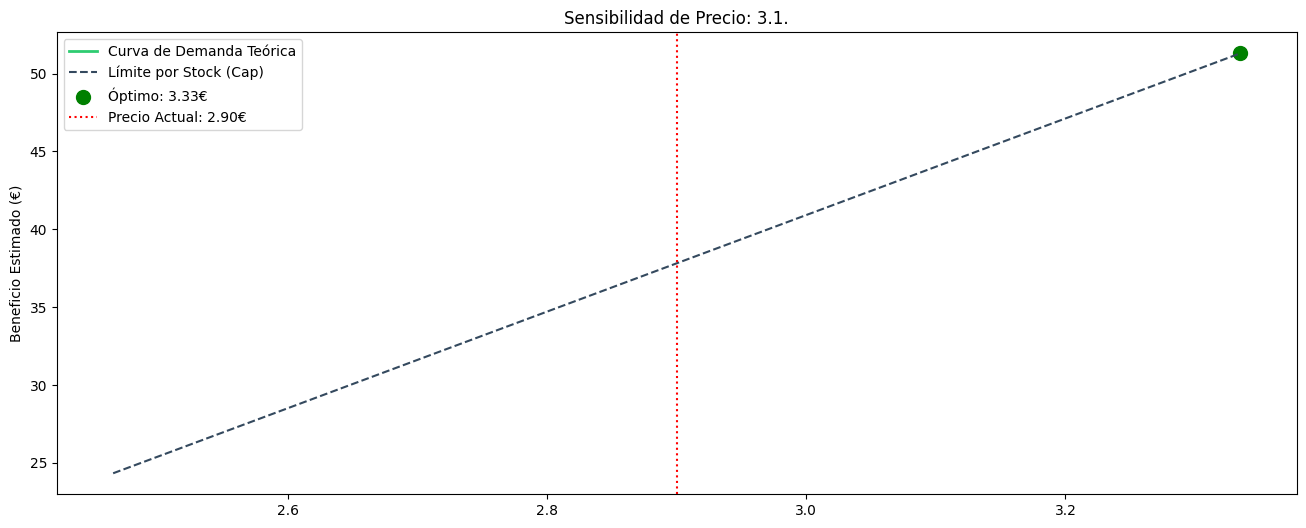

In [30]:
def graficar_analisis(datos_res, optimo, hist_ref, p_user, c_user, cap, nombre_p):
    fig, (ax1) = plt.subplots(1, figsize=(16, 6))

    #Gráfica beneficio
    ax1.plot(datos_res['precio'], datos_res['beneficio_teorico'], color='#2ecc71', label='Curva de Demanda Teórica', linewidth=2)
    ax1.plot(datos_res['precio'], datos_res['beneficio'], color='#34495e', linestyle='--', label='Límite por Stock (Cap)')

    ax1.scatter(optimo['precio'], optimo['beneficio'], color='green', s=100, label=f'Óptimo: {optimo["precio"]:.2f}€')
    ax1.axvline(p_user, color='red', linestyle=':', label=f'Precio Actual: {p_user:.2f}€')

    ax1.set_title(f"Sensibilidad de Precio: {nombre_p}")
    ax1.set_ylabel("Beneficio Estimado (€)")
    ax1.legend()

#Visualización gráfica
graficar_analisis(datos_res, optimo, hist_ref, p_user, c_user, cap, nombre_p)